# 5. Volatility Forecasting with GARCH and Variance Risk Premium

In this project we will get more into volatility and try to use statistical models like GARCH and HAR-RV to forecast realized volatility and then work with strategies and signals that come from the difference between market implied volatility and realized volatility.

- **Introduction to GARCH and implementation**
- **rolling forecasts using GARCH, GJR GARCH and EGARCH models**
- **Implamantation of HAR-RV**
- **Computation of Variance risk premium and interpretation**
- **using VRP as a trading signal for straddle strategies and volatility trading**

In Project 4, the central object was the option price: given an option chain, rates, forwards, maturities, and a pricing model, we solved for implied volatility and Greeks.
Here the direction becomes more trading-oriented: we ask whether the volatility implied by option prices is high or low relative to a model-based forecast of future realized variance, and then we translate that signal into simple straddle overlays.

if you haven't read the notebook 4 i highly recommend reading that first for understanding Implied volatility ([4. black-sholes, implied volatility, greeks and hedging])

[4. black-sholes, implied volatility, greeks and hedging]: https://ramtin-asadi.github.io/Quantitative-Finance-Lab/04_BSM_IV_greeks_hedging.html

### imports and plotting style

In [1]:
import warnings
import math
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from cycler import cycler
from scipy.optimize import minimize
from scipy.stats import norm
import statsmodels.api as sm
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from IPython.display import display
from arch import arch_model

from quantfinlab.options.diagnostics import build_atm_iv_panel_from_option_quotes

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")

palette = ["#069AF3","#FE420F", "#00008B", "#008080" , "#CC79A7",
          "#9614fa", "#DC143C", "#7BC8F6", "#0072B2","#04D8B2", "#800080", "#FF8072"]
plt.rcParams["axes.prop_cycle"] = cycler(color=palette)
plt.rcParams.update({
    "figure.figsize": (7, 3.2),
    "figure.dpi": 160,
    "savefig.dpi": 250,
    "axes.grid": True,
    "grid.alpha": 0.22,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 8})

seed = 7
np.random.seed(seed)

cwd = Path.cwd().resolve()
project_root = cwd if (cwd / "data").exists() else cwd.parent
data_dir = project_root / "data"

option_path = data_dir / "spx_options_chain_202201_202312.parquet"
rate_path = data_dir / "par-yield-curve-rates-1990-2026.csv"
spx_path = data_dir / "spx_daily_yfinance.csv"

horizons = (1, 5, 10, 21, 42, 63)
annualization = 252
calender_days = 365.25
eps = 1e-12


#### Variance or volatility

An important detail throughout the notebook is the difference between a **variance forecast** and a **volatility quote**. Variance is additive over time:

$$
\operatorname{Var}_{t}(r_{t+1}+\cdots+r_{t+h})
\approx
\sum_{j=1}^{h}\operatorname{Var}_{t}(r_{t+j}),
$$

while volatility is the square root of variance:

$$
\sigma=\sqrt{\sigma^2}.
$$

This is why the models are evaluated mainly in variance space. It is also why the VRP is defined as an implied-variance spread rather than only as a volatility spread. Volatility is easier to visualize, but variance is the natural object for multi-period forecasting and option-risk-premium logic.

#### physical measure

There is also a separation between the **physical measure** and the **option-implied measure**. GARCH and HAR-RV are estimated from realized return histories, so their forecasts are physical forecasts under the historical data process. Implied volatility comes from market prices and includes risk premia, supply-demand pressure, jump fear, margin effects, and hedging flows. Therefore, IV can be high or low relative to a disciplined physical forecast, and this comes from the difference between theory and what the volatility can be in a stationary world and what it is in real world markets.


## 1) Data

We use the same option chain, treasury risk free rate and historical prices of SPX in this project so we can have access to implied volatility solved in project 4. 
We don't need SPY because we are not going to deal with greeks and hedging with an underlying in this notebook. 
you can donload the options chain from here: [SPX EOD option chains from 2022 and 2023] and risk free rate from here: [treasury par yields] and SPX historical data is from yfinance API

[SPX EOD option chains from 2022 and 2023]: https://www.optionsdx.com/product/spx-option-chain/
[treasury par yields]: https://home.treasury.gov/resource-center/data-chart-center/interest-rates/daily-treasury-rate-archives


### 1.1 building future realized volatility

for evaluating the forecasts in the next sections, we have to construct the targets and the real volatility of each time. since we want to have forecasts for different horizons, we have to find the realized volatility of all the horizons for each date in our 2 year window.

The key transformation is from price levels to log returns:
 
$$
r_t=\log S_t-\log S_{t-1}.
$$

For each horizon $h\in\{1,5,10,21,42,63\}$, the code builds the future realized variance target 

$$
RV_{t,h}^{\text{sum}}=\sum_{j=1}^{h}r_{t+j}^{2}.
$$

Later, we clarify why we use squared returns as the estimator of future variance.

This is a **forward** target, not a realized volatility estimate. That means date $t$ receives the realized variance that will be observed over the next $h$ trading days. this is the value that the forecasting model is trying to predict.

The annualized versions are then

$$
RV_{t,h}^{\text{ann}}=\frac{252}{h}RV_{t,h}^{\text{sum}},
\qquad
\sigma_{t,h}^{\text{ann}}=\sqrt{RV_{t,h}^{\text{ann}}}.
$$



In [2]:
required_files = [option_path, rate_path, spx_path]
missing = [str(p) for p in required_files if not p.exists()]
if missing:
    raise FileNotFoundError("Missing required Project 5 data files: " + ", ".join(missing))

chain_cols = [
    "quote_date", "quote_readtime", "expire_date", "underlying_last",
    "strike", "c_bid", "c_ask", "p_bid", "p_ask", "c_volume", "p_volume"]
df_chain = pd.read_parquet(option_path, columns=chain_cols)
df_rates = pd.read_csv(rate_path)
df_spx_raw = pd.read_csv(spx_path)

for col in ["quote_date", "quote_readtime", "expire_date"]:
    df_chain[col] = pd.to_datetime(df_chain[col], errors="coerce")
df_chain["trade_date"] = df_chain["quote_date"].dt.normalize()
df_chain["expiry_datetime"] = df_chain["expire_date"].dt.normalize()
df_chain["quote_datetime"] = pd.to_datetime(df_chain["quote_readtime"], errors="coerce")
df_chain["dte_calendar"] = (df_chain["expiry_datetime"] - df_chain["trade_date"]).dt.total_seconds() / 86400.0
for col in ["underlying_last", "strike", "c_bid", "c_ask", "p_bid", "p_ask", "c_volume", "p_volume"]:
    df_chain[col] = pd.to_numeric(df_chain[col], errors="coerce")

def clean_yfinance_price_frame(raw, price_name, include_dividend=False):
    data = raw.copy()
    data.columns = [str(c).strip().lower().replace(" ", "_") for c in data.columns]
    if "date" not in data.columns:
        raise ValueError(f"{price_name} file must contain a date column")
    data["trade_date"] = pd.to_datetime(data["date"], errors="coerce").dt.normalize()
    price_col = "adj_close" if "adj_close" in data.columns else "close"
    data[price_col] = pd.to_numeric(data[price_col], errors="coerce")
    out = data[["trade_date", price_col]].rename(columns={price_col: price_name})
    if include_dividend:
        div_col = "dividends" if "dividends" in data.columns else None
        out["dividend"] = pd.to_numeric(data[div_col], errors="coerce").fillna(0.0) if div_col else 0.0
    return out.dropna(subset=["trade_date", price_name]).sort_values("trade_date").drop_duplicates("trade_date", keep="last")

df_spx = clean_yfinance_price_frame(df_spx_raw, "spx_close")
df_spx["spx_ret"] = np.log(df_spx["spx_close"] / df_spx["spx_close"].shift(1))
df_market = df_spx.sort_values("trade_date").reset_index(drop=True)

ret = df_market["spx_ret"].to_numpy(dtype=float)
for h in horizons:
    rv_sum = np.full(len(df_market), np.nan, dtype=float)
    for i in range(len(df_market) - h):
        window = ret[i + 1 : i + 1 + h]
        if np.isfinite(window).all():
            rv_sum[i] = float(np.sum(window * window))
    df_market[f"realized_var_sum_fwd_{h}"] = rv_sum
    df_market[f"realized_var_ann_fwd_{h}"] = annualization / h * rv_sum
    df_market[f"realized_vol_ann_fwd_{h}"] = np.sqrt(np.clip(df_market[f"realized_var_ann_fwd_{h}"], 0, None))

display(pd.DataFrame({
    "metric": ["raw_option_rows", "option_dates", "option_expiries", "market_dates", "return_start", "return_end"],
    "value": [
        int(len(df_chain)),
        int(df_chain["trade_date"].nunique()),
        int(df_chain["expiry_datetime"].nunique()),
        int(len(df_market)),
        str(df_market["trade_date"].min().date()),
        str(df_market["trade_date"].max().date())]}))
display(df_market.head())


,metric,value
0,raw_option_rows,4100693
1,option_dates,505
2,option_expiries,524
3,market_dates,24653
4,return_start,1927-12-30
5,return_end,2026-02-24


,trade_date,spx_close,spx_ret,realized_var_sum_fwd_1,realized_var_ann_fwd_1,realized_vol_ann_fwd_1,realized_var_sum_fwd_5,realized_var_ann_fwd_5,realized_vol_ann_fwd_5,realized_var_sum_fwd_10,...,realized_vol_ann_fwd_10,realized_var_sum_fwd_21,realized_var_ann_fwd_21,realized_vol_ann_fwd_21,realized_var_sum_fwd_42,realized_var_ann_fwd_42,realized_vol_ann_fwd_42,realized_var_sum_fwd_63,realized_var_ann_fwd_63,realized_vol_ann_fwd_63
0,1927-12-30,17.660000,NaN,0.000032,0.008035,0.089636,0.000252,0.012689,0.112647,0.000672,...,0.130159,0.001175,0.014097,0.118731,0.001975,0.011852,0.108867,0.003948,0.015793,0.125670
1,1928-01-03,17.760000,0.005647,0.000005,0.001281,0.035795,0.000275,0.013884,0.117832,0.000641,...,0.127068,0.001148,0.013777,0.117375,0.002183,0.013100,0.114454,0.003950,0.015800,0.125698
2,1928-01-04,17.719999,-0.002255,0.000093,0.023418,0.153030,0.000272,0.013695,0.117026,0.000641,...,0.127095,0.001175,0.014104,0.118761,0.002210,0.013262,0.115163,0.003947,0.015790,0.125657
3,1928-01-05,17.549999,-0.009640,0.000039,0.009838,0.099188,0.000226,0.011406,0.106798,0.000596,...,0.122560,0.001255,0.015058,0.122712,0.002144,0.012861,0.113408,0.004012,0.016049,0.126684
4,1928-01-06,17.660000,0.006248,0.000083,0.020874,0.144479,0.000227,0.011424,0.106882,0.000590,...,0.121929,0.001224,0.014689,0.121197,0.002116,0.012697,0.112680,0.003977,0.015910,0.126134


The trailing realized volatility is computed as a rolling standard deviation of daily log returns:

$$
\widehat{\sigma}^{\text{trail}}_{t,w}=
\sqrt{252}\;
\operatorname{Std}\left(r_{t-w+1},\ldots,r_t\right).
$$

This is different from the forward realized volatility constructed in the previous cell:

$$
\sigma_{t,h}^{\text{fwd}}=
\sqrt{\frac{252}{h}\sum_{j=1}^{h}r_{t+j}^{2}}.
$$

The trailing measure is observable at date $t$ and can be used as a feature. The forward measure is not observable at date $t$ and is only used for validation. Plotting them together gives a visual sense of how hard the forecasting problem is: trailing volatility reacts to information already seen, while forward volatility can jump if the next month contains a shock.


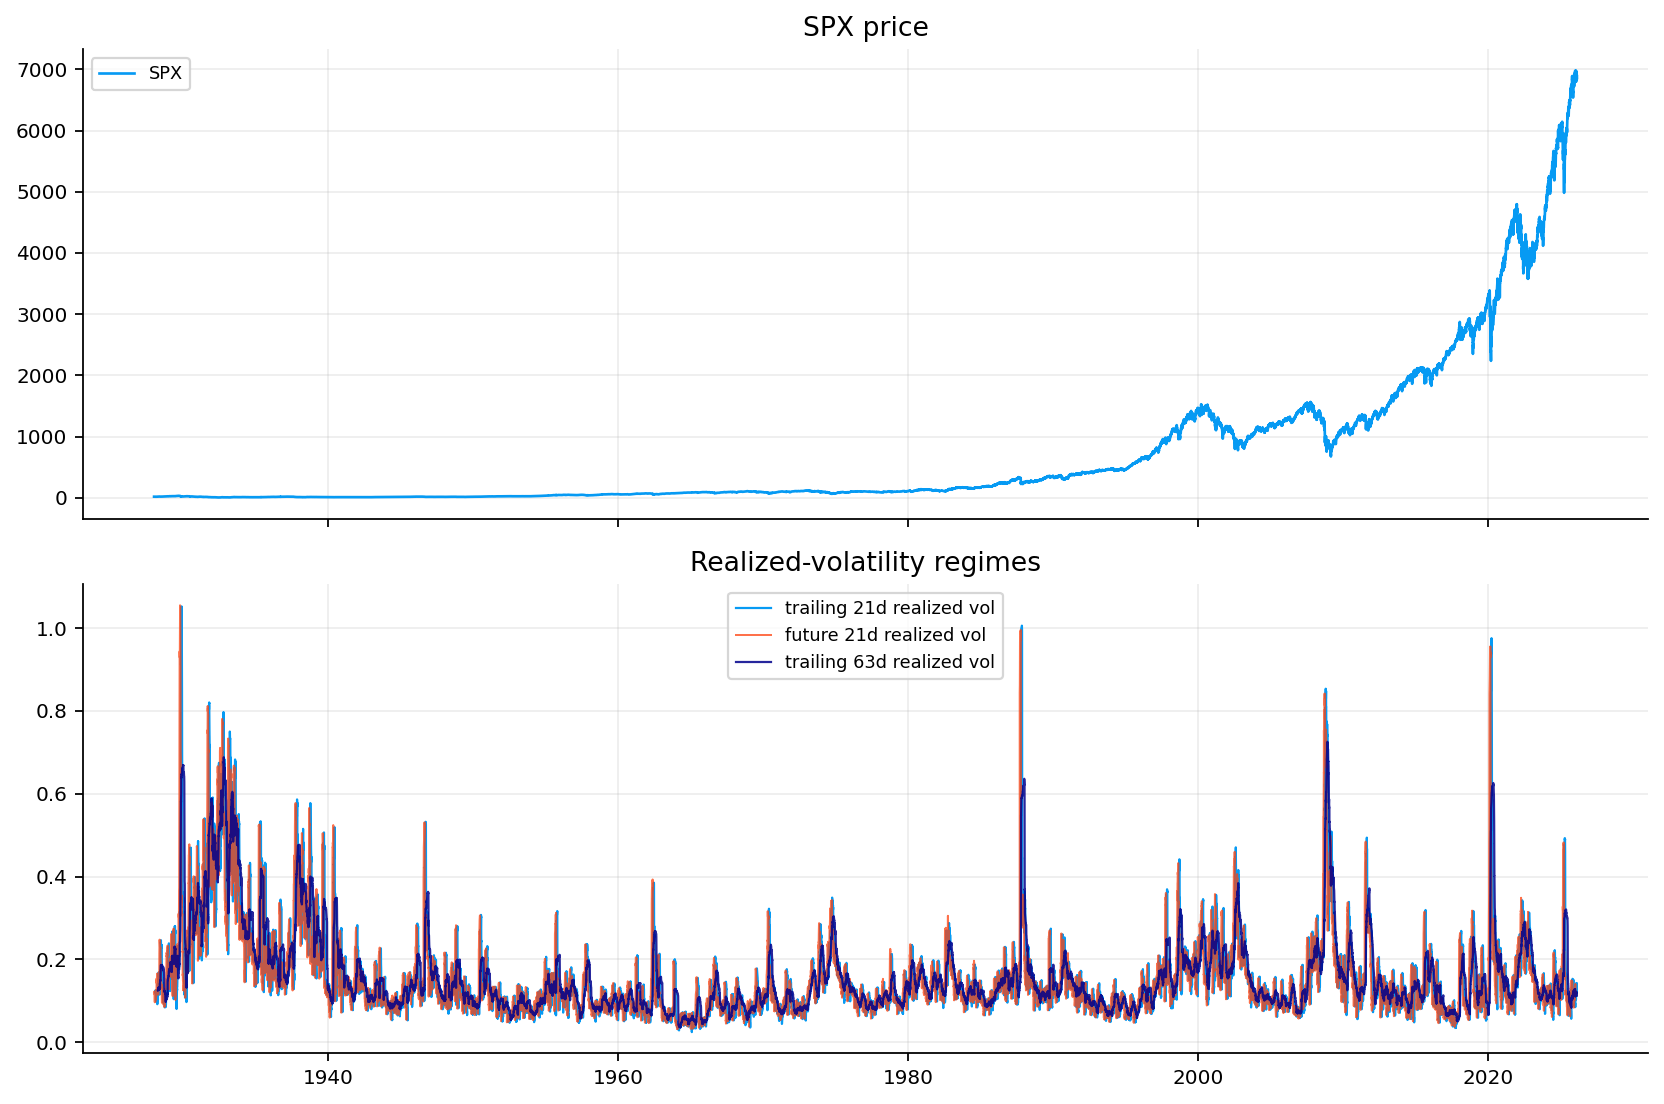

In [3]:
rv_windows = [10, 21, 42, 63, 84, 126]
for w in rv_windows:
    df_market[f"rv_trailing_{w}"] = df_market["spx_ret"].rolling(w).std() * np.sqrt(annualization)

fig, axes = plt.subplots(2, 1, figsize=(10.5, 7.0), sharex=True)
axes[0].plot(df_market["trade_date"], df_market["spx_close"], lw=1.2, label="SPX")
axes[0].set_title("SPX price")
axes[0].legend(loc="best")

axes[1].plot(df_market["trade_date"], df_market["rv_trailing_21"], lw=1.0, label="trailing 21d realized vol")
axes[1].plot(df_market["trade_date"], df_market["realized_vol_ann_fwd_21"], lw=0.9, alpha=0.75, label="future 21d realized vol")
axes[1].plot(df_market["trade_date"], df_market["rv_trailing_63"], lw=1.0, alpha=0.85, label="trailing 63d realized vol")
axes[1].set_title("Realized-volatility regimes")
axes[1].legend(loc="best")
plt.tight_layout()
plt.show()


## 2) building Implied Volatility 

Now we repeat the process of solving the implied volatility from Black Scholes formula and we use our library `quantfinlab` and use the Let's Be Rational inspired solver that we built in notebook 4. 

$$
C_{\text{model}}(\sigma) = C_{\text{mkt}}
$$

In the quotes cleaning process, We focus on near-ATM IV because we want a clean volatility comparison, not a full smile model. Deep OTM options include strong jump risk and crash insurance premia. Deep ITM options often have worse liquidity and wider microstructure noise. Near-ATM options are usually the most direct way to extract the market's central volatility expectation.

A volatility forecast can be very sophisticated, but if the implied-volatility input is noisy, stale, or taken from illiquid options, the signals made from it become unreliable.

In [4]:
t0 = time.time()
iv_panel_all = build_atm_iv_panel_from_option_quotes(
    df_chain, rates=df_rates, min_dte=7, max_dte=120,
    moneyness_range=(0.85, 1.15), max_relative_spread=0.20,
    closest_atm_pairs=25, min_pairs_per_expiry=10,
    solver="lbr_lite", engine="auto", underlying_default="SPX")

print(f"ATM IV panel build time: {time.time() - t0:,.1f}s")
print("IV solver engine:", iv_panel_all.attrs.get("iv_engine", "unknown"))

iv_panel_all["date"] = pd.to_datetime(iv_panel_all["date"], errors="coerce").dt.normalize()
iv_panel_all["expiry"] = pd.to_datetime(iv_panel_all["expiry"], errors="coerce").dt.normalize()
iv_panel_all["dte_calendar"] = pd.to_numeric(iv_panel_all["dte_calendar"], errors="coerce")
iv_panel_all["dte_trading"] = pd.to_numeric(iv_panel_all["dte_trading"], errors="coerce")
iv_panel_all["atm_iv_mid"] = pd.to_numeric(iv_panel_all["atm_iv_mid"], errors="coerce")
if iv_panel_all["atm_iv_mid"].dropna().median() > 2.0:
    for col in ["atm_iv_bid", "atm_iv_mid", "atm_iv_ask"]:
        if col in iv_panel_all:
            iv_panel_all[col] = iv_panel_all[col] / 100.0

iv_30d_daily = (
    iv_panel_all[(iv_panel_all["dte_calendar"] >= 21) & (iv_panel_all["dte_calendar"] <= 45)]
    .assign(dte_score=lambda x: (x["dte_calendar"] - 30.0).abs())
    .sort_values(["date", "dte_score", "quote_quality_score"])
    .groupby("date", as_index=False)
    .head(1)
    .drop(columns=["dte_score"], errors="ignore")
    .reset_index(drop=True))

display(pd.DataFrame({
    "metric": ["all_atm_rows", "daily_30d_rows", "first_date", "last_date", "median_atm_iv", "median_dte_calendar"],
    "value": [int(len(iv_panel_all)), int(len(iv_30d_daily)),
              str(iv_30d_daily["date"].min().date()),
              str(iv_30d_daily["date"].max().date()),
              float(iv_30d_daily["atm_iv_mid"].median()),
              float(iv_30d_daily["dte_calendar"].median())]}))


ATM IV panel build time: 78.0s
IV solver engine: numba


,metric,value
0,all_atm_rows,12426
1,daily_30d_rows,505
2,first_date,2022-01-03
3,last_date,2023-12-29
4,median_atm_iv,0.181915
5,median_dte_calendar,30.000000


## 3) GARCH(1,1) volatility forecasting (Generalized Autoregressive Conditional Heteroscedasticity)

We now construct and fit a GARCH model manually before using the `arch` package. This is not because the manual implementation is faster or more complete. It is because showing a transparent and clear implementation of model instead of just using a black box function from this package. After this we use arch package for all the other models and forecasts.

Daily asset returns exhibit:

- **Zero autocorrelation** in levels (weak efficiency, today's return is not correlated to tommorow or yesterday).
- **Volatility clustering**: large (small) returns tend to be followed by large (small) returns of either sign.
- **Heavy tails distribution** (excess kurtosis).
- **Slow decay of autocorrelation of squared returns** (long memory in volatility).

### 3.1 Conditional variance

If $\{r_t\}_{t \in \mathbb{Z}}$ is a return process adapted to the filtration $\mathcal{F}_{t-1}$ (all information up to time $t-1$).  

For a random variable $r_t$ and information set $\mathcal{F}_{t-1}$:

$$
\operatorname{Var}(r_t \mid \mathcal{F}_{t-1}) 
= \mathbb{E}\Bigl[\bigl(r_t - \mathbb{E}[r_t \mid \mathcal{F}_{t-1}]\bigr)^2 \;\Big|\; \mathcal{F}_{t-1}\Bigr]
$$

In GARCH models for daily asset returns, we assume zero mean. If $\mathbb{E}[r_t \mid \mathcal{F}_{t-1}] = 0$, then:

$$
r_t - \mathbb{E}[r_t \mid \mathcal{F}_{t-1}] = r_t - 0 = r_t
$$

So then we have:

$$
\operatorname{Var}(r_t \mid \mathcal{F}_{t-1}) 
= \mathbb{E}\bigl[ r_t^2 \mid \mathcal{F}_{t-1} \bigr]
$$

This is why we used squared returns as the estimator for future realized volatility and as the target of GARCH models. Under the assumption that return has mean of 0 and is unpredictable.

Then we can get to The **unconditional variance**: $\operatorname{Var}(r_t) = \mathbb{E}[r_t^2]$.  

And then We can define the **conditional variance** as:

$$
\sigma_t^2 = \operatorname{Var}(r_t \mid \mathcal{F}_{t-1}) = \mathbb{E}[r_t^2 \mid \mathcal{F}_{t-1}]
$$

By the law of total variance:

$$
\operatorname{Var}(r_t) = \mathbb{E}[\sigma_t^2] + \operatorname{Var}(\mathbb{E}[r_t \mid \mathcal{F}_{t-1}]) = \mathbb{E}[\sigma_t^2]
$$

because the conditional mean is zero, So the average conditional variance equals the unconditional variance.

---

### 3.2 From ARCH to GARCH

The ARCH($q$) model (Engle, 1982) specifies:

$$
\sigma_t^2 = \omega + \alpha_1 r_{t-1}^2 + \dots + \alpha_q r_{t-q}^2
$$

with $\omega>0$, $\alpha_i \ge 0$. This captures volatility clustering but often requires many lags $q$ to mimic the observed persistence.

Bollerslev (1986) generalised to **GARCH($p,q$)** by adding past conditional variances:

$$
\sigma_t^2 = \omega + \sum_{i=1}^q \alpha_i r_{t-i}^2 + \sum_{j=1}^p \beta_j \sigma_{t-j}^2
$$

The simplest and most widely used version is **GARCH(1,1)**:

$$
\boxed{\sigma_t^2 = \omega + \alpha \, r_{t-1}^2 + \beta \, \sigma_{t-1}^2}
$$

If we assume the return process is:

$$
r_t = \sigma_t \, z_t, \qquad z_t \stackrel{\text{i.i.d.}}{\sim} (0,1)
$$

where $\{z_t\}$ is an i.i.d. sequence with zero mean and unit variance (often taken as standard normal or Student‑$t$).  It is a random shock added to volatility that we suppose will construct the unpredictable return. 

$\sigma_t$ is $\mathcal{F}_{t-1}$-measurable (predictable). Then:

- $\mathbb{E}[r_t \mid \mathcal{F}_{t-1}] = \sigma_t \mathbb{E}[z_t] = 0$.
- $\mathbb{E}[r_t^2 \mid \mathcal{F}_{t-1}] = \sigma_t^2 \mathbb{E}[z_t^2] = \sigma_t^2$.

The GARCH(1,1) recursion can be written as:

$$
\sigma_t^2 = \omega + \alpha \sigma_{t-1}^2 z_{t-1}^2 + \beta \sigma_{t-1}^2
$$

The three parameters have these interpretations:

- $\omega$ is the long-run variance intercept
- $\alpha$ controls the immediate reaction to yesterday's squared shock
- $\beta$ controls volatility persistence through yesterday's conditional variance. 

---

### 3.3 Parameter constraints and stationarity

To ensure $\sigma_t^2 > 0$ we have to have:

$$
\omega > 0, \quad \alpha \ge 0, \quad \beta \ge 0
$$

For **weak stationarity** (constant unconditional variance), we require $\alpha + \beta < 1$.  

Take unconditional expectation of both sides:

$$
\mathbb{E}[\sigma_t^2] = \omega + \alpha \mathbb{E}[r_{t-1}^2] + \beta \mathbb{E}[\sigma_{t-1}^2]
$$

But $\mathbb{E}[r_{t-1}^2] = \mathbb{E}[\sigma_{t-1}^2]$ (since $z_{t-1}$ has unit variance and is independent). Let $\bar{\sigma}^2 = \mathbb{E}[\sigma_t^2]$ (constant under stationarity). Then:

$$
\bar{\sigma}^2 = \omega + (\alpha + \beta) \bar{\sigma}^2 
$$

$$
\bar{\sigma}^2 (1 - \alpha - \beta) = \omega
$$

$$
\boxed{\bar{\sigma}^2 = \frac{\omega}{1 - \alpha - \beta}}
$$

which is positive only if $1 - \alpha - \beta > 0$ or the rearranged constraint $\alpha + \beta < 1$.

---

### 3.4 The ARMA representation for squared returns

If $\nu_t = r_t^2 - \sigma_t^2$. Then $\nu_t$ is a zero‑mean white noise (though not i.i.d. – it has heteroskedasticity). Substituting $\sigma_t^2 = r_t^2 - \nu_t$ into the GARCH(1,1) equation:

$$
r_t^2 - \nu_t = \omega + \alpha r_{t-1}^2 + \beta (r_{t-1}^2 - \nu_{t-1})
$$

$$
r_t^2 = \omega + (\alpha + \beta) r_{t-1}^2 + \nu_t - \beta \nu_{t-1}
$$

This is an **ARMA(1,1) model for $r_t^2$** with AR (Autoregressive) coefficient $\phi = \alpha+\beta$ and MA (Moving average) coefficient $\theta = -\beta$.  

The persistence of squared returns is governed by $\alpha+\beta$. if it is close to 1, shocks to $r_t^2$ decay very slowly, matching the stylised fact of long memory in volatility.

### 3.5 Maximum likelihood estimation (Gaussian)

Given observed returns $r_1, \dots, r_T$, we estimate the parameters set $\theta = (\omega, \alpha, \beta)$ by maximising the log‑likelihood.  

For $z_t \stackrel{\text{i.i.d.}}{\sim} \mathcal{N}(0,1)$:

$$
r_t \mid \mathcal{F}_{t-1} \sim \mathcal{N}(0, \sigma_t^2)
$$

The conditional density is:

$$
f(r_t \mid \mathcal{F}_{t-1}; \theta) = \frac{1}{\sqrt{2\pi \sigma_t^2}} \exp\left(-\frac{r_t^2}{2\sigma_t^2}\right)
$$

The log‑likelihood (ignoring the constant term $-\frac{T}{2}\log(2\pi)$) is:

$$
\boxed{\ell(\theta) = -\frac{1}{2} \sum_{t=1}^{T} \left[ \log(\sigma_t^2) + \frac{r_t^2}{\sigma_t^2} \right]}
$$

We minimise the **negative log‑likelihood**:

$$
\hat{\theta} = \arg\min_{\theta} \left[ -\ell(\theta) \right]
$$

### 3.6 Initialisation of the variance recursion

To compute $\sigma_t^2$ for $t=1$, we need $\sigma_0^2$ (and $r_0^2$, but that can be set to its sample mean).  
A common method is **backcasting**: We can choose $\sigma_0^2$ as the exponentially weighted moving average of early squared returns:

$$
\sigma_0^2 = \sum_{i=1}^{m} w_i r_i^2, \quad w_i = \frac{\lambda^{i-1}}{\sum_{j=1}^{m} \lambda^{j-1}}
$$

where $\lambda$ is a decay factor (usually 0.94 for daily data) and $m$ is a moderate number (like 100). This gives more weight to recent observations before the sample start.

### 3.7 Multi‑step variance forecasting

We need forecasts of cumulative variance over horizons $h = 1,5,10,21,42,63$ days.  
The **one step ahead** forecast is directly computed from:

$$
\hat{\sigma}_{t+1|t}^2 = \omega + \alpha r_t^2 + \beta \sigma_t^2
$$

For $h \ge 2$, we can iterate the conditional expectation:

$$
\begin{aligned}
\hat{\sigma}_{t+2|t}^2 &= \mathbb{E}[\sigma_{t+2}^2 \mid \mathcal{F}_t] \\
&= \mathbb{E}[\omega + \alpha r_{t+1}^2 + \beta \sigma_{t+1}^2 \mid \mathcal{F}_t] \\
&= \omega + \alpha \,\mathbb{E}[r_{t+1}^2 \mid \mathcal{F}_t] + \beta \,\mathbb{E}[\sigma_{t+1}^2 \mid \mathcal{F}_t] \\
&= \omega + \alpha \,\hat{\sigma}_{t+1|t}^2 + \beta \,\hat{\sigma}_{t+1|t}^2 \\
&= \omega + (\alpha+\beta) \,\hat{\sigma}_{t+1|t}^2
\end{aligned}
$$

since $\mathbb{E}[r_{t+1}^2 \mid \mathcal{F}_t] = \sigma_{t+1}^2$, for $j \ge 2$:

$$
\boxed{\hat{\sigma}_{t+j|t}^2 = \omega + (\alpha+\beta) \,\hat{\sigma}_{t+j-1|t}^2}
$$

The **cumulative $h$-day variance forecast** is:

$$
\widehat{RV}_{t,h} = \sum_{j=1}^{h} \hat{\sigma}_{t+j|t}^2
$$

Annualized volatility would be $\sqrt{252 \cdot \widehat{RV}_{t,1}}$ for one day ahead, but for multi‑day horizons we use the sum directly. 



In [5]:
returns_series = df_market.loc[df_market["spx_ret"].notna(), ["trade_date", "spx_ret"]].copy().reset_index(drop=True)
ret_pct = 100.0 * returns_series["spx_ret"].to_numpy(dtype=float)

def garch_backcast(resids, decay=0.94, horizon=75):
    x = np.asarray(resids, dtype=float) ** 2
    n = min(len(x), horizon)
    if n == 0:
        return 1.0
    w = decay ** np.arange(n)
    w = w / w.sum()
    return float(np.sum(w * x[:n][::-1]))

def garch11_filter_backcast(returns_pct, omega, alpha, beta, backcast=None):
    eps = np.asarray(returns_pct, dtype=float)
    n = len(eps)
    sigma2 = np.empty(n, dtype=float)
    if backcast is None:
        backcast = garch_backcast(eps)
    sigma2[0] = max(float(backcast), 1e-8)
    for t in range(1, n):
        sigma2[t] = omega + alpha * eps[t - 1] ** 2 + beta * sigma2[t - 1]
        sigma2[t] = max(sigma2[t], 1e-10)
    return sigma2

def garch11_negloglik_normal(params, returns_pct, backcast=None):
    omega, alpha, beta = [float(x) for x in params]
    if omega <= 0.0 or alpha < 0.0 or beta < 0.0 or alpha + beta >= 0.999:
        return 1e16
    sigma2 = garch11_filter_backcast(returns_pct, omega, alpha, beta, backcast=backcast)
    ll = -0.5 * (np.log(2.0 * np.pi) + np.log(sigma2) + (returns_pct ** 2) / sigma2)
    value = -float(np.sum(ll))
    return value if np.isfinite(value) else 1e16

def garch11_multi_horizon_variance(last_sigma2, last_eps, omega, alpha, beta, horizons):
    horizons = sorted(set(int(h) for h in horizons))
    out = {}
    h1 = omega + alpha * float(last_eps) ** 2 + beta * float(last_sigma2)
    out[1] = h1
    prev = h1
    for h in range(2, max(horizons) + 1):
        prev = omega + (alpha + beta) * prev
        out[h] = prev
    return {h: out[h] for h in horizons}

def fit_manual_garch11_normal(returns_pct):
    y = np.asarray(returns_pct, dtype=float)
    y = y[np.isfinite(y)]
    backcast = garch_backcast(y)
    var0 = max(float(np.var(y, ddof=1)), 1e-6)
    starts = []
    for alpha0, beta0 in [(0.05, 0.90), (0.08, 0.90), (0.10, 0.85), (0.03, 0.95), (0.12, 0.80)]:
        if alpha0 + beta0 < 0.999:
            starts.append(np.array([max((1.0 - alpha0 - beta0) * var0, 1e-8), alpha0, beta0], dtype=float))
    bounds = [(1e-12, 100.0 * var0), (1e-8, 0.999), (1e-8, 0.999)]
    cons = [{"type": "ineq", "fun": lambda x: 0.999 - x[1] - x[2]}]
    best = None
    for x0 in starts:
        try:
            res = minimize(
                garch11_negloglik_normal,
                x0=x0,
                args=(y, backcast),
                method="SLSQP",
                bounds=bounds,
                constraints=cons,
                options={"maxiter": 2000, "ftol": 1e-12})
            if best is None or res.fun < best.fun:
                best = res
        except Exception:
            pass
    if best is None:
        raise RuntimeError("manual GARCH fit failed")
    omega, alpha, beta = [float(v) for v in best.x]
    sigma2 = garch11_filter_backcast(y, omega, alpha, beta, backcast=backcast)
    std_resid = y / np.sqrt(np.clip(sigma2, 1e-12, None))
    ll = -garch11_negloglik_normal([omega, alpha, beta], y, backcast)
    n = len(y)
    k = 3
    return {
        "success": bool(best.success), "message": str(best.message),
        "omega": omega, "alpha": alpha, "beta": beta,
        "persistence": alpha + beta, "backcast": backcast,
        "sigma2": sigma2, "std_resid": std_resid, "loglik": ll,
        "aic": 2.0 * k - 2.0 * ll, "bic": math.log(n) * k - 2.0 * ll,
        "unc_var": omega / max(1.0 - alpha - beta, 1e-8)}

manual_fit = fit_manual_garch11_normal(ret_pct)
am_manual_check = arch_model(ret_pct, mean="Zero", vol="GARCH", p=1, q=1, dist="normal", rescale=False)
res_manual_check = am_manual_check.fit(disp="off", show_warning=False)

display(pd.DataFrame([
    {"model": "manual_garch11_normal",
    "success": manual_fit["success"],
    "omega": manual_fit["omega"],
    "alpha": manual_fit["alpha"],
    "beta": manual_fit["beta"],
    "persistence": manual_fit["persistence"],
    "unc_var_pct2": manual_fit["unc_var"],
    "aic": manual_fit["aic"],
    "bic": manual_fit["bic"]},
    
    {"model": "arch_garch11_normal",
    "success": True,
    "omega": float(res_manual_check.params.get("omega", np.nan)),
    "alpha": float(res_manual_check.params.get("alpha[1]", np.nan)),
    "beta": float(res_manual_check.params.get("beta[1]", np.nan)),
    "persistence": float(res_manual_check.params.get("alpha[1]", np.nan) + res_manual_check.params.get("beta[1]", np.nan)),
    "unc_var_pct2": float(res_manual_check.params.get("omega", np.nan) / max(1.0 - res_manual_check.params.get("alpha[1]", np.nan) - res_manual_check.params.get("beta[1]", np.nan), 1e-8)),
    "aic": float(res_manual_check.aic),
    "bic": float(res_manual_check.bic)}]))


,model,success,omega,alpha,beta,persistence,unc_var_pct2,aic,bic
0,manual_garch11_normal,True,0.010925,0.095796,0.899325,0.995121,2.239160,"65,498.576815","65,522.914655"
1,arch_garch11_normal,True,0.010923,0.095777,0.899349,0.995127,2.241470,"65,498.126263","65,522.464103"


We tried to minimize the negative log likelihood using a numerical optimizer (L‑BFGS‑B with bounds $[\epsilon, 1-\epsilon]$ for $\alpha,\beta$). As we can see our fitted model is pretty close to the implementation of arch package and got near exact results.

The fitted parameters are:

| Parameter | Manual | arch       |
|-----------|--------|------------|
| $\omega$  | 0.010925 | 0.010923 |
| $\alpha$  | 0.095796 | 0.095777 |
| $\beta$   | 0.899325 | 0.899349 |


- $\alpha$ is small (≈0.096): A large shock today increases tomorrow’s variance by $\alpha$ times the squared shock.  
- $\beta$ is large (≈0.899): Most of tomorrow’s variance is inherited from today’s variance (volatility is persistent).  
- The sum $\alpha+\beta \approx 0.995$ which is less than 1 and implies that shocks take a long time to decay.

We can interpret it like this: A large negative or positive return creates a jump in $r_t^2$, which enters through $\alpha r_t^2$, and then the shock decays through the $\beta$ channel over many days.

Unconditional variance $\bar{\sigma}^2 = 0.010925 / (1-0.995121) = 2.240$ 

annualized volatility $\sqrt{252 \times 2.240} \approx 23.7\%$

AIC and BIC values are nearly identical, confirming that our manual likelihood computation matches the arch package implementation.

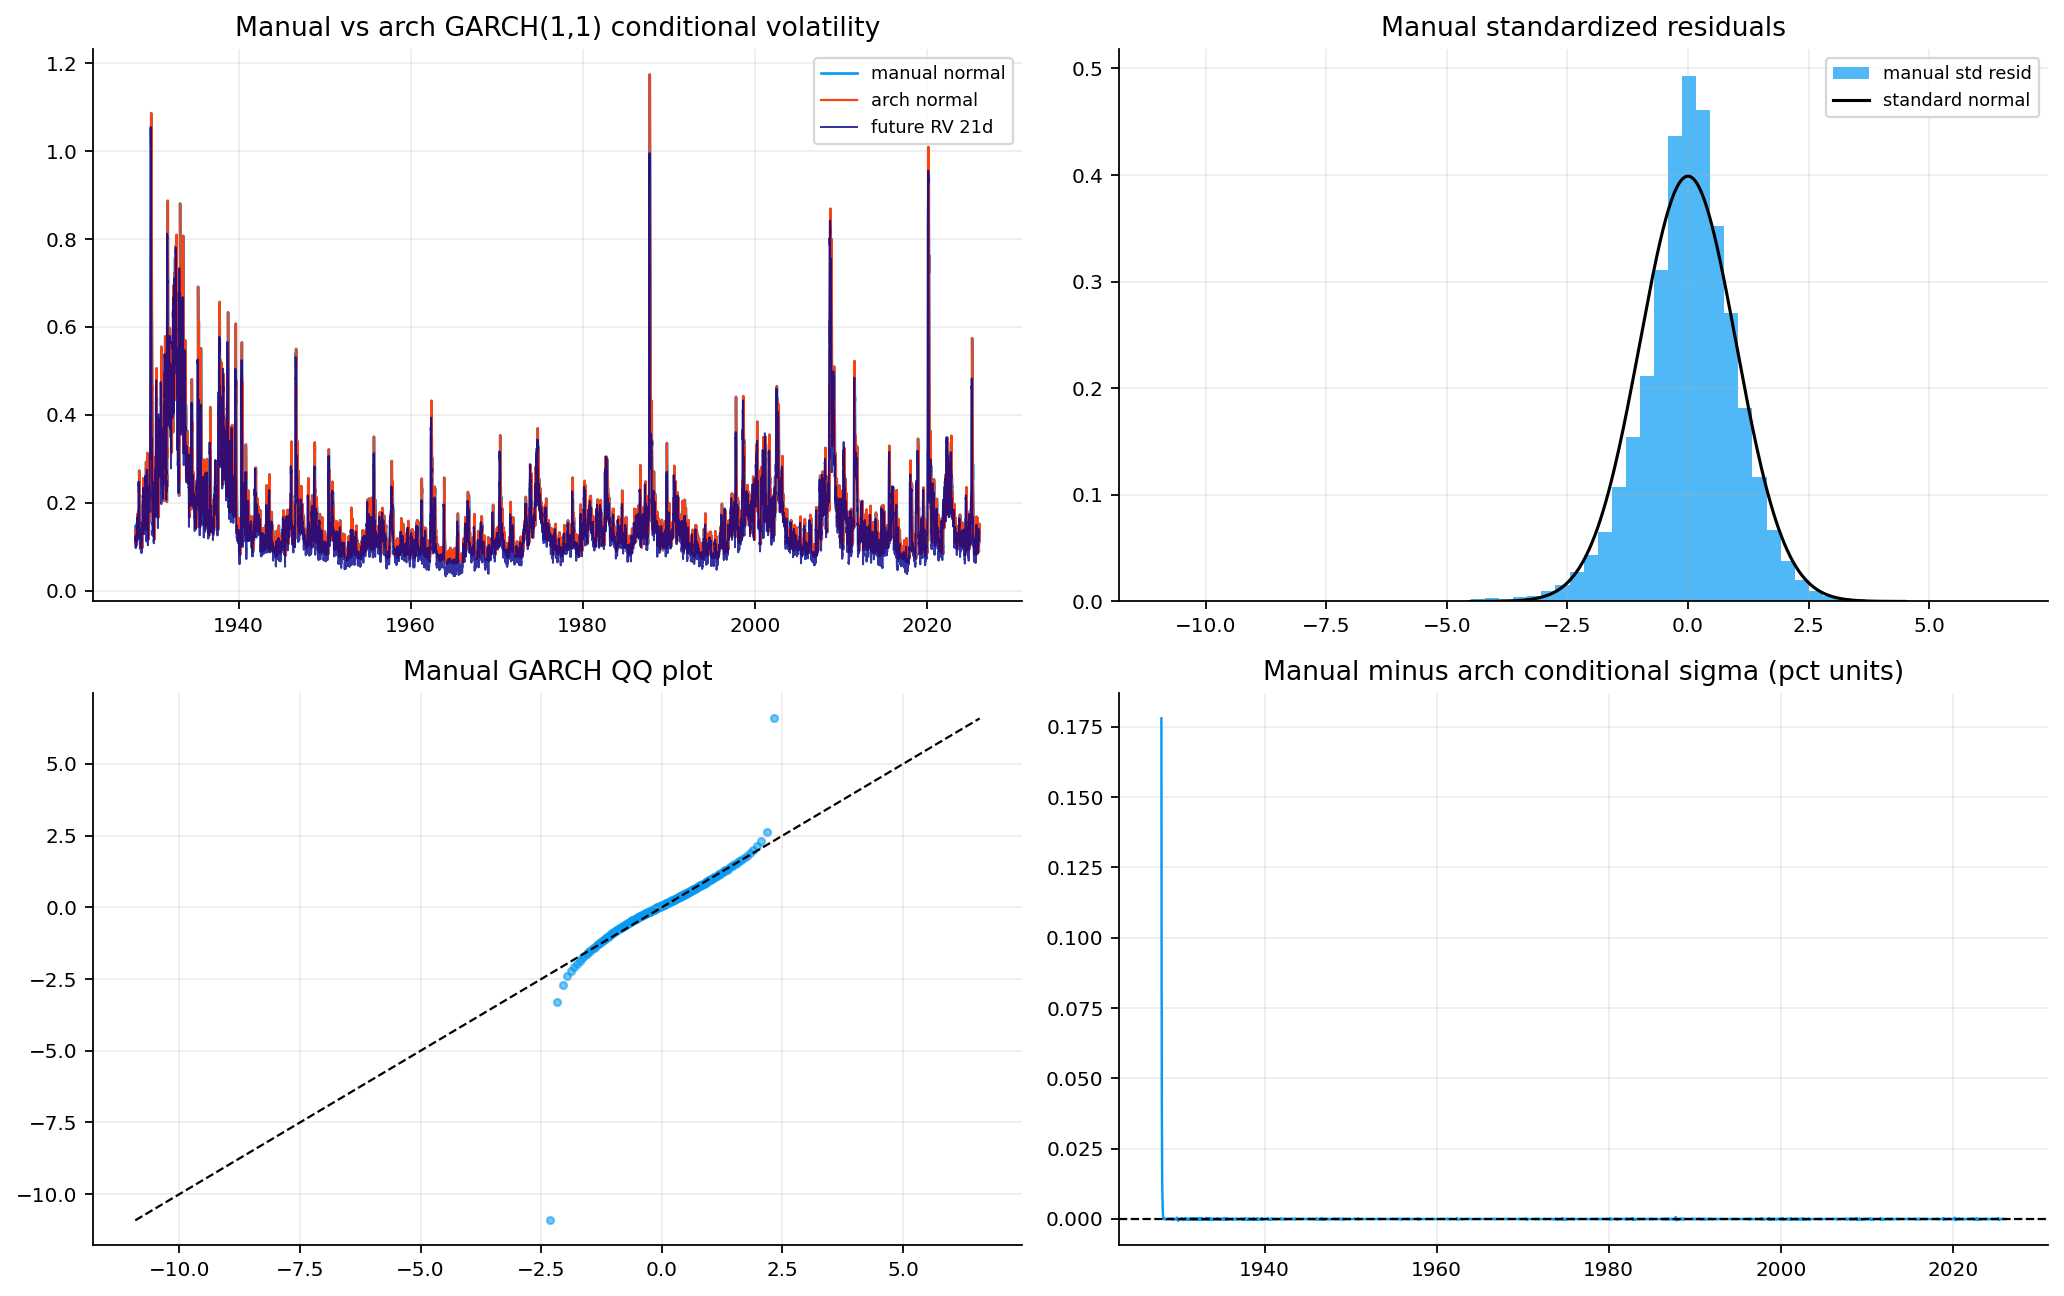

,metric,value
0,manual_arch_param_abs_diff_omega,0.000001
1,manual_arch_param_abs_diff_alpha,0.000019
2,manual_arch_param_abs_diff_beta,0.000024
3,manual_arch_sigma_corr,0.999991


In [6]:
manual_dates = returns_series["trade_date"].reset_index(drop=True)
arch_cond_vol = np.asarray(res_manual_check.conditional_volatility, dtype=float)

fig, axes = plt.subplots(2, 2, figsize=(13.0, 8.2))
axes[0, 0].plot(manual_dates, np.sqrt(annualization) * np.sqrt(manual_fit["sigma2"]) / 100.0, lw=1.2, label="manual normal")
axes[0, 0].plot(manual_dates, np.sqrt(annualization) * arch_cond_vol / 100.0, lw=1.0, label="arch normal")
axes[0, 0].plot(df_market["trade_date"], df_market["realized_vol_ann_fwd_21"], lw=0.9, alpha=0.8, label="future RV 21d")
axes[0, 0].set_title("Manual vs arch GARCH(1,1) conditional volatility")
axes[0, 0].legend(loc="best")

axes[0, 1].hist(manual_fit["std_resid"], bins=60, alpha=0.70, density=True, label="manual std resid")
x = np.linspace(-4.5, 4.5, 300)
axes[0, 1].plot(x, norm.pdf(x), lw=1.4, c="black", label="standard normal")
axes[0, 1].set_title("Manual standardized residuals")
axes[0, 1].legend(loc="best")

q_grid = np.linspace(0.01, 0.99, 200)
norm_q = norm.ppf(q_grid)
std_resid_manual = np.sort(pd.Series(manual_fit["std_resid"]).replace([np.inf, -np.inf], np.nan).dropna().to_numpy(dtype=float))
idx = np.linspace(0, len(std_resid_manual) - 1, len(norm_q)).astype(int)
axes[1, 0].scatter(norm_q, std_resid_manual[idx], s=10, alpha=0.55)
lo = min(norm_q.min(), std_resid_manual[idx].min())
hi = max(norm_q.max(), std_resid_manual[idx].max())
axes[1, 0].plot([lo, hi], [lo, hi], ls="--", lw=1.0, c="black")
axes[1, 0].set_title("Manual GARCH QQ plot")

sigma_diff = np.sqrt(manual_fit["sigma2"]) - arch_cond_vol
axes[1, 1].plot(manual_dates, sigma_diff, lw=1.1)
axes[1, 1].axhline(0.0, lw=1.0, ls="--", c="black")
axes[1, 1].set_title("Manual minus arch conditional sigma (pct units)")
plt.tight_layout()
plt.show()

display(pd.DataFrame([
    {"metric": "manual_arch_param_abs_diff_omega", "value": abs(manual_fit["omega"] - float(res_manual_check.params.get("omega", np.nan)))},
    {"metric": "manual_arch_param_abs_diff_alpha", "value": abs(manual_fit["alpha"] - float(res_manual_check.params.get("alpha[1]", np.nan)))},
    {"metric": "manual_arch_param_abs_diff_beta", "value": abs(manual_fit["beta"] - float(res_manual_check.params.get("beta[1]", np.nan)))},
    {"metric": "manual_arch_sigma_corr", "value": float(np.corrcoef(np.sqrt(manual_fit["sigma2"]), arch_cond_vol)[0, 1])},
]))


The absolute parameter differences are extremely small, and the correlation between our and arch implementation is **0.999991**. The only visible difference is an initialization effect. After that, the two implementations are practically the same.

The residual histogram being close to normal in the center is expected, but the QQ plot reveals that the model might perform close with normality but it misses the tails. This is a common trap. A model can look visually good for most of the observations and still be dangerous for option trading if it doesn't represent extreme moves as good. Options are nonlinear instruments, so tail errors matter more than they would in a simple linear regression.

The standardized residuals:

$$
z_t=\frac{r_t}{\widehat{\sigma}_t}
$$

We compare empirical residual quantiles with normal quantiles
$$
Q_{\widehat{z}}(p)
\quad \text{versus} \quad
\Phi^{-1}(p).
$$

If the residuals were exactly standard normal, the points would lie on the line completely. The deviation in the tails means the standardized shocks still have excess kurtosis and asymmetry.This result can be a sign that we can use different distrinutions that can represent tails better than normal distribution. One of the main ones used for tail tracking is Student-t distribution

### 3.8 Beyond normality

A Student-$t$ distribution with degrees of freedom $\nu$ has heavier tails than the normal distribution. When $\nu$ is finite and not very large, the model assigns more probability to large standardized shocks:

$$
P(|Z_t|>x)
\text{ is larger under Student-}t
\text{ than under } \mathcal{N}(0,1).
$$

This is one of the directions for equity-index return modeling that can perform better at tails than normal GARCH.

GARCH can explain volatility clustering, but it does not automatically explain tail shape. A return can be standardized by a strong volatility filter and still have extreme residual in the tails. That is the reason we can use Student-$t$ here:

$$
z_t \sim t_{\nu},
$$

where lower $\nu$ means heavier tails. For an equity index's returns, we except much heavier tailed behavior than normal, but not so extreme that the variance becomes undefined.

The log‑likelihood then becomes:

$$
\ell_t = \log\Gamma\left(\frac{\nu+1}{2}\right) - \log\Gamma\left(\frac{\nu}{2}\right) - \frac{1}{2}\log(\pi(\nu-2)) - \frac{1}{2}\log(\sigma_t^2) - \frac{\nu+1}{2}\log\left(1 + \frac{r_t^2}{\sigma_t^2(\nu-2)}\right)
$$


## 4 Other types of GARCH model

The standard GARCH $(p,q)$ structure was

$$
\sigma_t^2=\omega+\sum_{i=1}^{p}\alpha_i r_{t-i}^{2}+\sum_{j=1}^{q}\beta_j\sigma_{t-j}^{2}.
$$

### 4.1 GARCH($2,2$)

While GARCH(1,1) captures most financial volatility dynamics, a GARCH(2,2) allows for two lags of both squared returns and past variances, might be better fitting assets with more complex memory structures:

$$
\sigma_t^2 = \omega + \alpha_1 r_{t-1}^2 + \alpha_2 r_{t-2}^2 + \beta_1 \sigma_{t-1}^2 + \beta_2 \sigma_{t-2}^2
$$

with parameter constraints:

$$
\omega > 0,\quad \alpha_1,\alpha_2,\beta_1,\beta_2 \ge 0,\quad \alpha_1+\alpha_2+\beta_1+\beta_2 < 1
$$

### 4.2 GJR-GARCH

One of the stronger choices can be the GJR-GARCH model that adds an asymmetric term:

$$
\sigma_t^2=\omega+\alpha r_{t-1}^{2}+\gamma r_{t-1}^{2}\mathbf{1}_{\{r_{t-1}<0\}}+\beta\sigma_{t-1}^{2}.
$$

Here $\gamma>0$ means negative returns increase future variance more than positive returns of the same magnitude. This means the negative shocks that make the price of an asset fall have higher effect on variance than positive shocks that make the price rise. This is the standard leverage effect pattern in equity indices.

### 4.3 E-GARCH

EGARCH works in log variance:

$$
\log\sigma_t^2=\omega+\beta\log\sigma_{t-1}^2+\alpha\left(|z_{t-1}|-\mathbb{E}|z_{t-1}|\right)+\gamma z_{t-1}.
$$

Because the model is written in $\log\sigma_t^2$, we ensure the variance is automatically positive without requiring the same parameter restrictions as standard GARCH.

We also compare normal and Student-$t$ distributions for all three of these models:

- GARCH(1,1) Normal
- GARCH(1,1) t
- GARCH(2,2) Normal
- GARCH(2,2) t
- GJR-GARCH(1,1,1) Normal
- GJR-GARCH(1,1,1) t
- EGARCH(1,1) Normal
- EGARCH(1,1) t

There are so many more GARCH variants that can be even more powerful and perform better in modeling, like Mixture GARCH models, multivariate, Markov-switching, CC_GARCH, DCC-GARCH etc, which have their own features and abilities. for this project we will focus on the main classic ones. We also just implemented GARCH(1,1) manualy for clarity of model and for the rest of the models, we use `arch` package.

,model,loglik,aic,bic,omega,alpha1,alpha2,gamma1,beta1,beta2,nu
0,gjr11_student,"-31,693.245793","63,396.491587","63,437.054653",0.011826,0.028557,NaN,0.113452,0.908128,NaN,6.174988
1,egarch11_student,"-31,877.150130","63,762.300259","63,794.750713",0.007495,0.171965,NaN,NaN,0.990556,NaN,5.756719
2,garch11_student,"-31,890.220232","63,788.440463","63,820.890917",0.008563,0.083748,NaN,NaN,0.912156,NaN,5.833311
3,garch22_student,"-31,888.894940","63,789.789881","63,838.465560",0.009412,0.093659,0.000000,NaN,0.761765,0.140058,5.851436
4,gjr11_normal,"-32,521.033233","65,050.066466","65,082.516919",0.012845,0.037511,NaN,0.098231,0.905648,NaN,NaN
5,garch22_normal,"-32,734.029997","65,478.059994","65,518.623061",0.012867,0.117864,0.000000,NaN,0.586279,0.290243,NaN
6,garch11_normal,"-32,746.063132","65,498.126263","65,522.464103",0.010923,0.095777,NaN,NaN,0.899349,NaN,NaN
7,egarch11_normal,"-32,775.229984","65,556.459968","65,580.797808",0.009028,0.200920,NaN,NaN,0.987354,NaN,NaN


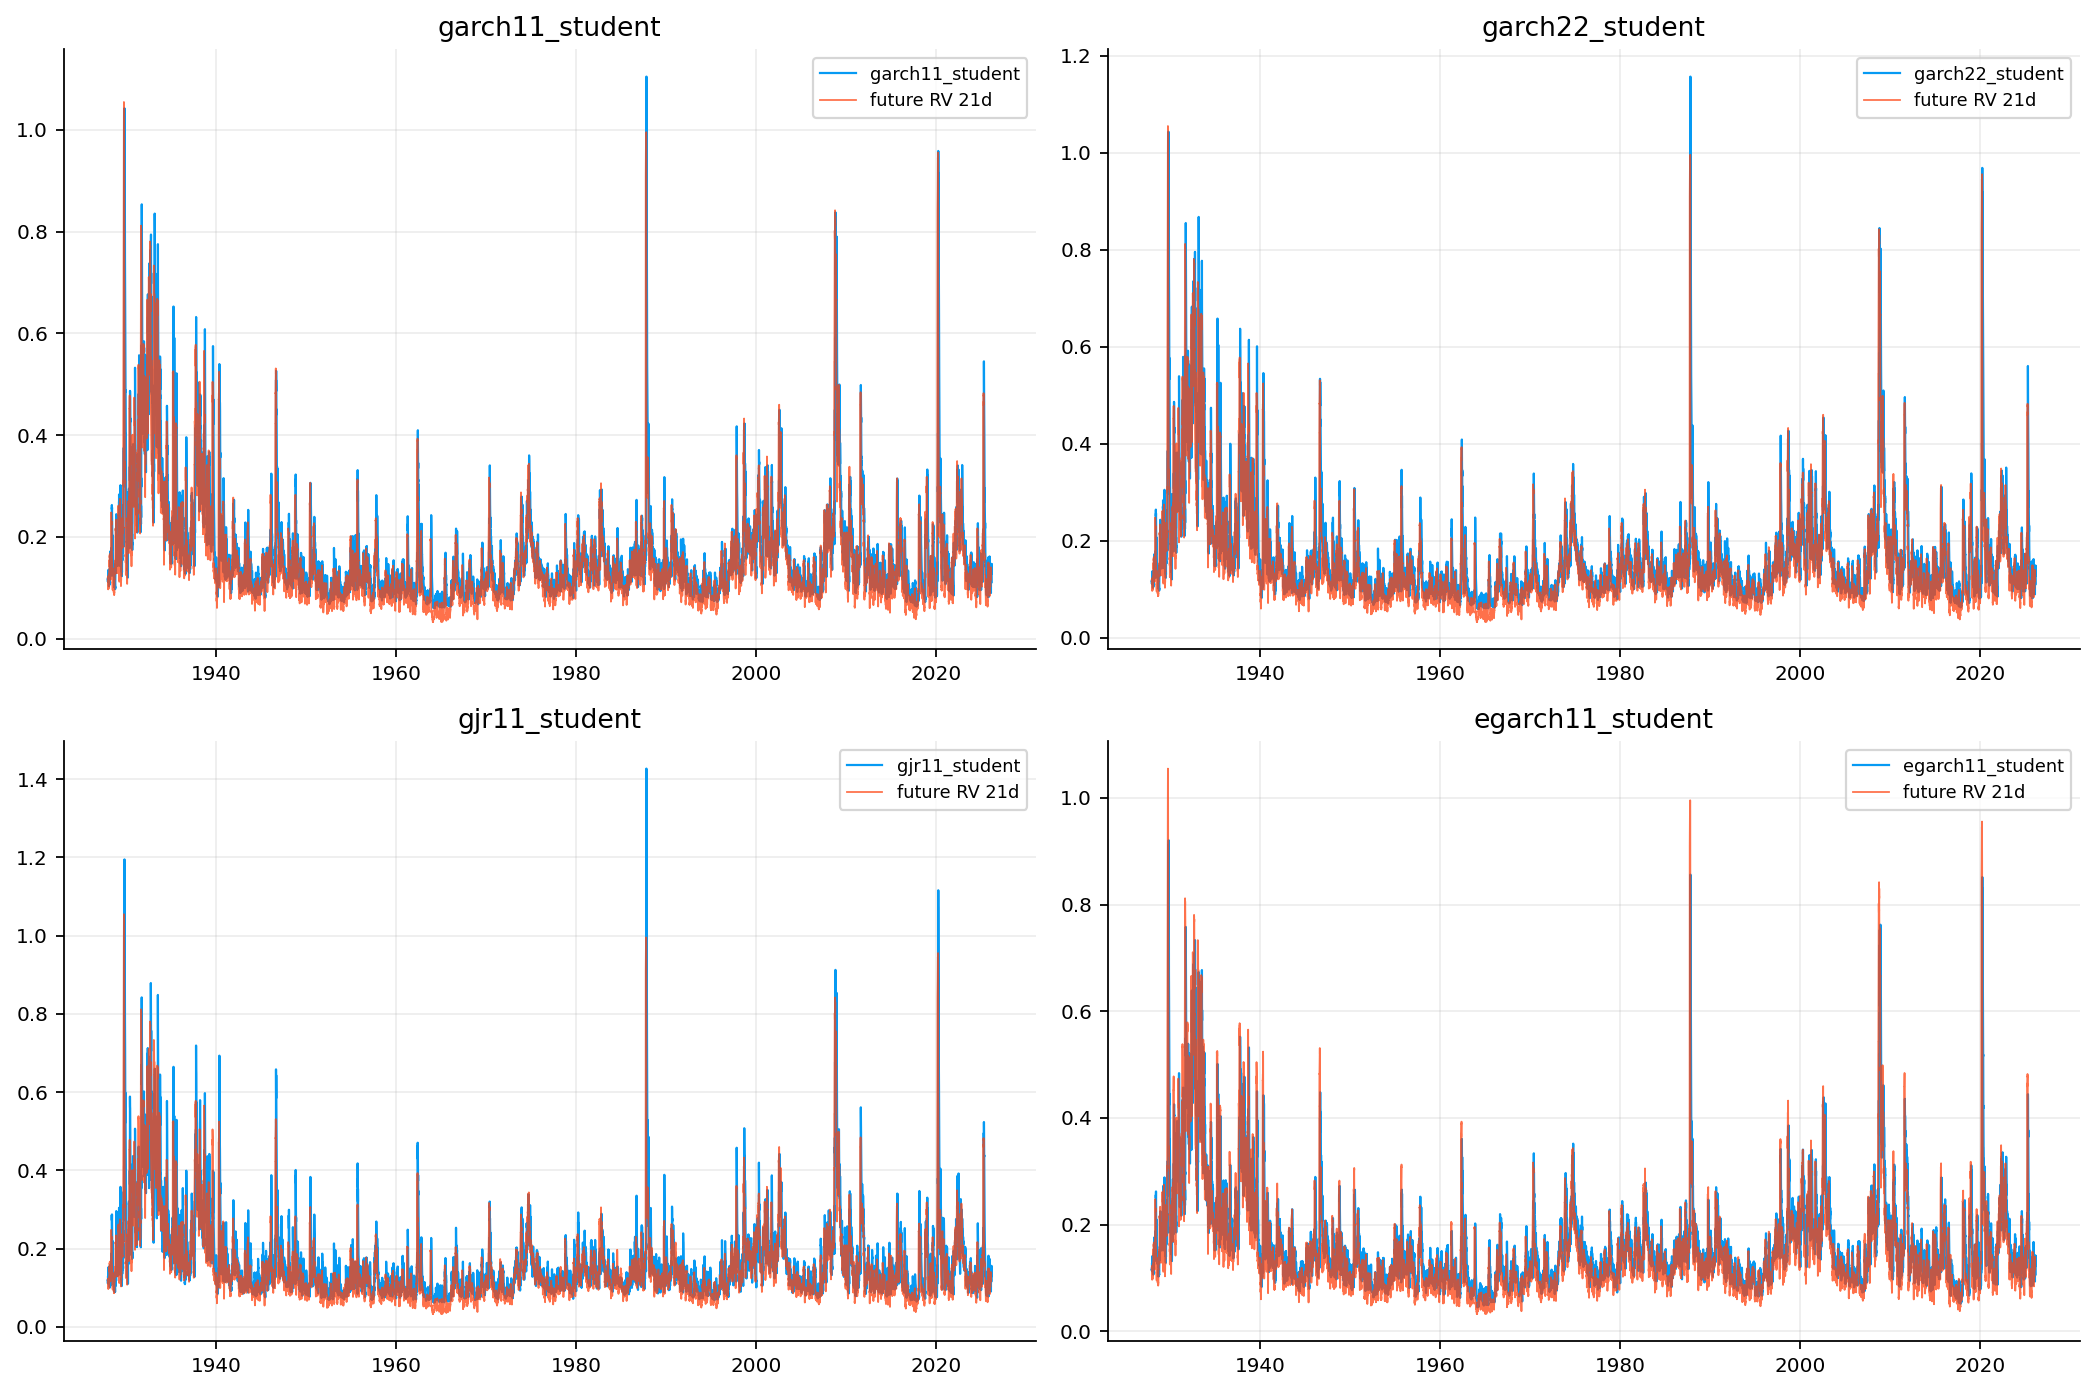

,model,lb_resid_p_10,lb_resid_p_20,lb_sq_p_10,lb_sq_p_20,arch_lm_stat_10,arch_lm_p_10,persistence_like_sum,half_life_days_garch11_style
0,garch22_normal,0.000000,0.000000,0.016558,0.017778,21.475984,0.018008,0.994386,1.976055
1,gjr11_student,0.000000,0.000000,0.006687,0.015659,24.185792,0.007122,1.050137,10.597207
2,gjr11_normal,0.000000,0.000000,0.007758,0.015556,23.691409,0.008463,1.041390,11.844375
3,garch11_normal,0.000000,0.000000,0.000225,0.000338,32.890961,0.000284,0.995127,141.886151
4,garch22_student,0.000000,0.000000,0.000069,0.000167,35.765975,0.000092,0.995482,4.438745
5,garch11_student,0.000000,0.000000,0.000002,0.000006,44.483407,0.000003,0.995904,168.891522
6,egarch11_normal,0.000000,0.000000,0.000000,0.000000,71.828295,0.000000,1.188274,NaN
7,egarch11_student,0.000000,0.000000,0.000000,0.000000,113.512408,0.000000,1.162521,NaN


In [ ]:
def fit_arch_model_visible(returns_pct, vol, p, q, dist, o=0, maxiter=600):
    model = arch_model( returns_pct, mean="Zero", 
                       vol=vol, p=p, o=o, q=q, dist=dist, rescale=False)
    
    res = model.fit(disp="off", show_warning=False, options={"maxiter": int(maxiter)})
    return model, res

model_specs = [
    {"name": "garch11_normal", "vol": "GARCH", "p": 1, "o": 0, "q": 1, "dist": "normal"},
    {"name": "garch11_student", "vol": "GARCH", "p": 1, "o": 0, "q": 1, "dist": "t"},
    {"name": "garch22_normal", "vol": "GARCH", "p": 2, "o": 0, "q": 2, "dist": "normal"},
    {"name": "garch22_student", "vol": "GARCH", "p": 2, "o": 0, "q": 2, "dist": "t"},
    {"name": "gjr11_normal", "vol": "GARCH", "p": 1, "o": 1, "q": 1, "dist": "normal"},
    {"name": "gjr11_student", "vol": "GARCH", "p": 1, "o": 1, "q": 1, "dist": "t"},
    {"name": "egarch11_normal", "vol": "EGARCH", "p": 1, "o": 0, "q": 1, "dist": "normal"},
    {"name": "egarch11_student", "vol": "EGARCH", "p": 1, "o": 0, "q": 1, "dist": "t"}]

full_sample_fits = {}
fit_rows = []
for spec in model_specs:
    model, res = fit_arch_model_visible(returns_pct=ret_pct,
                                        vol=spec["vol"], p=spec["p"],
                                        o=spec["o"], q=spec["q"],
                                        dist=spec["dist"])
        
    full_sample_fits[spec["name"]] = {"model": model, "res": res, "spec": spec}
    params = res.params.to_dict()
    fit_rows.append({
        "model": spec["name"],
        "loglik": float(res.loglikelihood),
        "aic": float(res.aic),
        "bic": float(res.bic),
        "omega": float(params.get("omega", np.nan)),
        "alpha1": float(params.get("alpha[1]", np.nan)),
        "alpha2": float(params.get("alpha[2]", np.nan)),
        "gamma1": float(params.get("gamma[1]", np.nan)),
        "beta1": float(params.get("beta[1]", np.nan)),
        "beta2": float(params.get("beta[2]", np.nan)),
        "nu": float(params.get("nu", np.nan))})


df_full_sample_fit = pd.DataFrame(fit_rows).sort_values(["aic", "bic"]).reset_index(drop=True)
display(df_full_sample_fit)

selected_models_for_plot = [m for m in ["garch11_student", "garch22_student", "gjr11_student", "egarch11_student"] if m in full_sample_fits]
fig, axes = plt.subplots(2, 2, figsize=(13.2, 8.8), sharex=False)
axes = axes.ravel()
for ax, name in zip(axes, selected_models_for_plot):
    res = full_sample_fits[name]["res"]
    cond_vol = np.asarray(res.conditional_volatility, dtype=float) / 100.0 * np.sqrt(annualization)
    ax.plot(returns_series["trade_date"], cond_vol, lw=1.0, label=name)
    ax.plot(df_market["trade_date"], df_market["realized_vol_ann_fwd_21"], lw=0.8, alpha=0.75, label="future RV 21d")
    ax.set_title(name)
    ax.legend(loc="best")
for ax in axes[len(selected_models_for_plot):]:
    ax.axis("off")
plt.tight_layout()
plt.show()

selected_models_for_plot2 = [m for m in ["garch11_normal", "garch22_normal", "gjr11_normal", "egarch11_normal"] if m in full_sample_fits]
fig, axes = plt.subplots(2, 2, figsize=(13.2, 8.8), sharex=False)
axes = axes.ravel()
for ax, name in zip(axes, selected_models_for_plot2):
    res = full_sample_fits[name]["res"]
    cond_vol = np.asarray(res.conditional_volatility, dtype=float) / 100.0 * np.sqrt(annualization)
    ax.plot(returns_series["trade_date"], cond_vol, lw=1.0, label=name)
    ax.plot(df_market["trade_date"], df_market["realized_vol_ann_fwd_21"], lw=0.8, alpha=0.75, label="future RV 21d")
    ax.set_title(name)
    ax.legend(loc="best")
for ax in axes[len(selected_models_for_plot):]:
    ax.axis("off")
plt.tight_layout()
plt.show()

diag_rows = []
for name, entry in full_sample_fits.items():
    res = entry["res"]
    std_resid = pd.Series(res.std_resid).replace([np.inf, -np.inf], np.nan).dropna()
    if len(std_resid) < 40:
        continue
    lb_r = acorr_ljungbox(std_resid, lags=[10, 20], return_df=True)
    lb_s = acorr_ljungbox(std_resid ** 2, lags=[10, 20], return_df=True)
    arch_lm = het_arch(std_resid, nlags=10)
    params = res.params
    persistence = float(np.nansum([params.get(k, np.nan) for k in params.index if (k.startswith("alpha[") or k.startswith("beta[") or k.startswith("gamma["))]))
    alpha1 = float(params.get("alpha[1]", np.nan))
    beta1 = float(params.get("beta[1]", np.nan))
    half_life = math.log(0.5) / math.log(alpha1 + beta1) if np.isfinite(alpha1 + beta1) and 0 < alpha1 + beta1 < 1 else np.nan
    diag_rows.append({
        "model": name,
        "lb_resid_p_10": float(lb_r["lb_pvalue"].iloc[0]),
        "lb_resid_p_20": float(lb_r["lb_pvalue"].iloc[-1]),
        "lb_sq_p_10": float(lb_s["lb_pvalue"].iloc[0]),
        "lb_sq_p_20": float(lb_s["lb_pvalue"].iloc[-1]),
        "arch_lm_stat_10": float(arch_lm[0]),
        "arch_lm_p_10": float(arch_lm[1]),
        "persistence_like_sum": persistence,
        "half_life_days_garch11_style": half_life})
df_ts_diagnostics = pd.DataFrame(diag_rows).sort_values("lb_sq_p_20", ascending=False).reset_index(drop=True)
display(df_ts_diagnostics)


- **GJR-GARCH(1,1) with Student-$t$** has the best AIC and BIC.
- The Student-$t$ models strongly improve likelihood relative to the normal models.
- The estimated GJR asymmetry, with $\gamma_1\approx0.113$ in the best model.
- The plain normal GARCH(1,1) is useful as a baseline, but it is not the best full-sample description.
- The Student-$t$ models estimate degree of freedom $\nu$ around 5.8–6.2, which is strong evidence that the return distribution is much heavier tailed than Gaussian (normal).

AIC and BIC are defined as

$$
AIC = 2k-2\ell,
\qquad
BIC = k\log(T)-2\ell,
$$

where $k$ is the number of estimated parameters and $\ell$ is the maximized log-likelihood. Lower values are better.

We also use the Ljung–Box statistic tests autocorrelation:

$$
Q(m)=T(T+2)\sum_{k=1}^{m}\frac{\widehat{\rho}_k^2}{T-k},
$$

and the ARCH-LM test checks whether squared residuals still forecast themselves. The p-values are mostly very small, especially for raw standardized residual autocorrelation. This is not surprising in a very long sample. With more than 20,000 daily observations, even small misspecifications become statistically significant.

- the GJR Student-$t$ model is the best full-sample likelihood model
- asymmetry and fat tails matter
- no single parametric volatility model removes all dependence completely
- full sample fit is not the same as out of sample forecast quality. because of this, we will get to rolling forecasts in the next sections to be able to compare models in real condition.

Persistent is different for each model type and have to be interpreted different.
The stronger interpretation is that asymmetric and fat-tailed models describe the data better than the plain normal GARCH baseline.

As we can see from the plots, different models often agree on the dates of volatility spikes but differ in the height and decay of those spikes. For ana pplication like option trading, this matters because a small difference in annualized volatility becomes a larger difference in variance:

$$
\sigma_1^2-\sigma_2^2=
(\sigma_1-\sigma_2)(\sigma_1+\sigma_2).
$$

The best full sample model is GJR-GARCH with Student-$t$ distribution. That means two empirical features matter at the daily SPX level:

> asymmetric response to negative shocks + fat-tailed standardized shocks


---

## 5) HAR-RV model

We now add a non-GARCH model. HAR-RV is the heterogeneous autoregressive model of realized volatility. GARCH models conditional variance as a long run mean reverting process driven by shocks. HAR-RV models realized variance directly using multiple realized volatility horizons.

The whole HAR idea is that volatility has heterogeneous memory. Short horizon traders react to daily volatility, medium horizon participants react to weekly volatility, and slower allocators react to monthly volatility. A simple HAR-RV regression uses

$$
RV_t^{(d)}=r_t^2,
$$

$$
RV_t^{(w)}=\frac{1}{5}\sum_{i=0}^{4}r_{t-i}^{2},
$$

$$
RV_t^{(m)}=\frac{1}{22}\sum_{i=0}^{21}r_{t-i}^{2}.
$$

An the regression can be written as

$$
RV_{t,t+h}^{\text{sum}}=\beta_0+\beta_d RV_t^{(d)}+\beta_w RV_t^{(w)}+\beta_m RV_t^{(m)}+\varepsilon_{t+h}.
$$

We use a log version of it to stabilize the scale and keep predictions positive:

$$
\log RV_{t,t+h}^{\text{sum}}=\beta_0+\beta_d \log RV_t^{(d)}+\beta_w \log RV_t^{(w)}+\beta_m \log RV_t^{(m)}+\varepsilon_{t+h}.
$$

And then, the prediction is transformed back by exponentiation:

$$
\widehat{RV}_{t,t+h}^{\text{sum}}=\exp\left(\widehat{\beta}_0+\widehat{\beta}_d \log RV_t^{(d)}+\widehat{\beta}_w \log RV_t^{(w)}+\widehat{\beta}_m \log RV_t^{(m)}\right).
$$

There is also an important detail for preventing leaking future data to model. For a horizon-$h$ forecast made at date $t$, the target $RV_{s,s+h}^{\text{sum}}$ for a training date $s$ is only known after $s+h$. Therefore, when forecasting at $t$, the training target cannot include dates whose realized window contains the unknown future, so the regression only trains on targets that would already have been fully realized. That detail is easy and obvious, but it is essential. Without it, the HAR model would accidentally use future realized variance information and would look better than it should in a real time trading setting.

We use HAR-RV along GARCH models because it's intentionally simple. It doesn't estimate a nonlinear variance recursion and it doesn't require a distributional assumption for returns. It says that future realized variance can be forecast from realized variance measured at different past horizons.

HAR-RV is also naturally connected to market behavior. Daily volatility may capture very recent shocks. Weekly volatility may capture short risk management cycles. Monthly volatility may capture slower repricing and institutional allocation changes. The model is linear, but its features encode a multi scale view of volatility.

HAR-type models are popular in realized-volatility forecasting because they are simple, interpretable, and often surprisingly competitive.


In [8]:
def make_har_features_visible(rv_daily, weekly_window=5, monthly_window=22, use_log=True, eps=eps):
    rv = pd.Series(rv_daily).copy()
    rv.index = pd.to_datetime(rv.index, errors="coerce")
    rv = pd.to_numeric(rv, errors="coerce").replace([np.inf, -np.inf], np.nan).sort_index()
    features = pd.DataFrame(index=rv.index)
    features["rv_daily"] = rv
    features["rv_weekly"] = rv.rolling(weekly_window, min_periods=weekly_window).mean()
    features["rv_monthly"] = rv.rolling(monthly_window, min_periods=monthly_window).mean()
    if use_log:
        features = np.log(features.clip(lower=eps))
        features = features.rename(columns=lambda c: "log_" + c)
    return features

def forward_realized_var_sum(returns, horizon):
    r = pd.Series(returns).copy()
    vals = pd.to_numeric(r, errors="coerce").to_numpy(dtype=float)
    out = np.full(len(vals), np.nan, dtype=float)
    h = int(horizon)
    for i in range(len(vals) - h):
        window = vals[i + 1 : i + 1 + h]
        if np.isfinite(window).all():
            out[i] = float(np.sum(window * window))
    return pd.Series(out, index=r.index, name=f"realized_var_sum_{h}")

def fit_har_ols_visible(features, target_sum, use_log=True, eps=eps):
    data = features.join(target_sum.rename("target"), how="inner").replace([np.inf, -np.inf], np.nan).dropna()
    if len(data) < features.shape[1] + 20:
        raise ValueError("not enough HAR-RV observations")
    y = pd.to_numeric(data["target"], errors="coerce")
    if use_log:
        y = np.log(y.clip(lower=eps))
    X = np.column_stack([np.ones(len(data)), data[features.columns].to_numpy(dtype=float)])
    beta, *_ = np.linalg.lstsq(X, np.asarray(y, dtype=float), rcond=None)
    return pd.Series(beta, index=["const", *features.columns])

def predict_har_sum_visible(params, feature_row, use_log=True, eps=eps):
    x = np.r_[1.0, feature_row.to_numpy(dtype=float)]
    pred = float(np.dot(params.to_numpy(dtype=float), x))
    if use_log:
        pred = float(np.exp(pred))
    return max(pred, eps)

def rolling_har_forecasts_visible(returns_df, signal_dates, horizons=horizons, train_window=756, annualization=annualization, use_log=True, eps=eps):
    ser = returns_df.set_index("trade_date")["spx_ret"].dropna().sort_index()
    rv_daily = ser * ser
    features = make_har_features_visible(rv_daily, use_log=use_log, eps=eps)
    targets = {int(h): forward_realized_var_sum(ser, int(h)) for h in horizons}
    dates = pd.DatetimeIndex(ser.index)
    date_to_pos = {pd.Timestamp(d).normalize(): i for i, d in enumerate(dates)}
    records = []
    for signal_date in pd.DatetimeIndex(pd.to_datetime(signal_dates)).normalize().unique().sort_values():
        pos = date_to_pos.get(pd.Timestamp(signal_date).normalize())
        if pos is None or pos < train_window or pos + max(horizons) >= len(ser):
            continue
        if signal_date not in features.index or features.loc[[signal_date]].isna().any(axis=None):
            continue
        for h in horizons:
            h = int(h)
            known_end_pos = pos - h
            if known_end_pos <= 0:
                continue
            train_start = max(0, known_end_pos - int(train_window) + 1)
            train_dates = dates[train_start : known_end_pos + 1]
            try:
                params = fit_har_ols_visible(features.loc[train_dates], targets[h].loc[train_dates], use_log=use_log, eps=eps)
                forecast_sum = predict_har_sum_visible(params, features.loc[signal_date], use_log=use_log, eps=eps)
            except Exception:
                continue
            realized_sum = float(targets[h].loc[signal_date])
            forecast_ann = annualization / h * forecast_sum
            realized_ann = annualization / h * realized_sum if np.isfinite(realized_sum) else np.nan
            records.append({
                "date": signal_date,
                "model": "har_rv",
                "horizon": h,
                "forecast_var_sum": forecast_sum,
                "forecast_var_ann": forecast_ann,
                "forecast_vol_ann": float(np.sqrt(max(forecast_ann, 0.0))),
                "realized_var_sum": realized_sum,
                "realized_var_ann": realized_ann,
                "realized_vol_ann": float(np.sqrt(max(realized_ann, 0.0))) if np.isfinite(realized_ann) else np.nan,
                "n_train": int(len(train_dates))})
    return pd.DataFrame(records).sort_values(["date", "horizon"]).reset_index(drop=True)

har_feature_preview = make_har_features_visible(df_market.set_index("trade_date")["spx_ret"].dropna() ** 2).dropna().head()


## 6) rolling forecasts

For every signal date and every forecast horizon, we refit models using a rolling training window of 756 trading days, approximately three years:

$$
\mathcal{T}_t \{t-755,\ldots,t\}.
$$

The GARCH models produce a path of one step ahead conditional variances:

$$
\widehat{\sigma}_{t+1|t}^{2},\widehat{\sigma}_{t+2|t}^{2},\ldots,\widehat{\sigma}_{t+h|t}^{2}.
$$

The horizon-$h$ forecast is the sum of those daily conditional variances:

$$
\widehat{RV}_{t,h}^{\text{sum}}=\sum_{j=1}^{h}\widehat{\sigma}_{t+j|t}^{2}.
$$

Then we convert it to annualized variance and volatility:

$$
\widehat{RV}_{t,h}^{\text{ann}}=\frac{252}{h}\widehat{RV}_{t,h}^{\text{sum}},
\qquad\widehat{\sigma}_{t,h}^{\text{ann}}=\sqrt{\widehat{RV}_{t,h}^{\text{ann}}}.
$$

The realized comparison target is built from the actual future returns:

$$
RV_{t,h}^{\text{sum}}=\sum_{j=1}^{h}r_{t+j}^{2}.
$$


Rolling refits are expensive but necessary. thousands of GARCH and HAR-RV estimations are computationally heavy because we refit many models many times. A full-sample fit would be faster, but it would not represent the information set of a trader on each option date.

The structure is:

>date t --> fit on past 756 returns --> forecast horizons --> store realized target for later evaluation


This gives a realistic forecast panel but introduces two practical complications.

A full-sample model can be useful for education, but it is not a trading test. In a trading test, the model parameters used on date $t$ must be estimated using only information available before date $t$. The rolling window creates exactly that discipline:

$$
\{\text{returns up to }t\}
\longrightarrow
\widehat{\theta}_t
\longrightarrow
\widehat{RV}_{t,t+h}.
$$

The 756-day training window is roughly three trading years. That is long enough to estimate GARCH-family parameters with some stability, but short enough to adapt when volatility regimes change.


In [ ]:
train_window = 756
signal_dates_all = pd.DatetimeIndex(iv_30d_daily["date"].dropna().unique()).sort_values()

signal_dates = signal_dates_all
signal_dates = signal_dates[(signal_dates >= returns_series["trade_date"].min()) & (signal_dates <= returns_series["trade_date"].max())]
display(pd.DataFrame({"metric": ["signal_dates", "first_signal", "last_signal"], "value": [len(signal_dates), signal_dates.min(), signal_dates.max()]}))

def arch_forecast_variance_vector(res, max_horizon, simulations=500, seed=7):
    try:
        fc = res.forecast(horizon=int(max_horizon), reindex=False, method="analytic")
    except Exception:
        np.random.seed(seed)
        fc = res.forecast(horizon=int(max_horizon), reindex=False, method="simulation", simulations=int(simulations))
    return np.asarray(fc.variance.values[-1], dtype=float).reshape(-1)

def rolling_arch_forecasts_daily_refit(returns_df, signal_dates, specs, horizons=horizons, train_window=756, annualization=annualization, maxiter=500):
    data = returns_df.dropna(subset=["trade_date", "spx_ret"]).copy()
    data["trade_date"] = pd.to_datetime(data["trade_date"], errors="coerce").dt.normalize()
    data = data.sort_values("trade_date").reset_index(drop=True)
    dates = pd.DatetimeIndex(data["trade_date"])
    returns = data["spx_ret"].to_numpy(dtype=float)
    ret_pct_all = 100.0 * returns
    date_to_pos = {pd.Timestamp(d).normalize(): i for i, d in enumerate(dates)}
    max_h = int(max(horizons))
    records = []
    error_rows = []
    for signal_idx, signal_date in enumerate(pd.DatetimeIndex(signal_dates).normalize().unique().sort_values()):
        pos = date_to_pos.get(pd.Timestamp(signal_date).normalize())
        if pos is None or pos < train_window or pos + max_h >= len(data):
            continue
        train = ret_pct_all[pos - train_window + 1 : pos + 1]
        if not np.isfinite(train).all():
            train = train[np.isfinite(train)]
        if len(train) < train_window:
            continue
        for spec_idx, spec in enumerate(specs):
            name = spec["name"]
            try:
                _, res = fit_arch_model_visible(
                    train, vol=spec["vol"], p=spec["p"],
                    o=spec.get("o", 0), q=spec["q"], dist=spec["dist"], maxiter=maxiter)
                
                fc_pct2 = arch_forecast_variance_vector(res, max_h, seed=seed + 1009 * spec_idx + signal_idx)
            except Exception as exc:
                error_rows.append({"date": signal_date, "model": name, "error": str(exc)})
                continue
            for h in horizons:
                h = int(h)
                forecast_sum = float(np.sum(fc_pct2[:h]) / (100.0 ** 2))
                realized_window = returns[pos + 1 : pos + 1 + h]
                realized_sum = float(np.sum(realized_window * realized_window)) if len(realized_window) == h else np.nan
                forecast_ann = annualization / h * forecast_sum
                realized_ann = annualization / h * realized_sum
                records.append({
                    "date": signal_date,
                    "model": name, "horizon": h,
                    "forecast_var_sum": forecast_sum,
                    "forecast_var_ann": forecast_ann,
                    "forecast_vol_ann": float(np.sqrt(max(forecast_ann, 0.0))),
                    "realized_var_sum": realized_sum,
                    "realized_var_ann": realized_ann,
                    "realized_vol_ann": float(np.sqrt(max(realized_ann, 0.0))),
                    "n_train": int(len(train))})
                
    out = pd.DataFrame(records).sort_values(["date", "model", "horizon"]).reset_index(drop=True)
    errors = pd.DataFrame(error_rows)
    return out, errors

t0 = time.time()
df_garch_fc, df_arch_errors = rolling_arch_forecasts_daily_refit(
    returns_series, signal_dates, model_specs,
    horizons=horizons, train_window=train_window, maxiter=500)

df_har_fc = rolling_har_forecasts_visible(
    returns_series,
    signal_dates,
    horizons=horizons,
    train_window=train_window)

df_fc_signal = pd.concat([df_garch_fc, df_har_fc], ignore_index=True).sort_values(["date", "model", "horizon"]).reset_index(drop=True)
print(f"Forecast generation time: {time.time() - t0:,.1f}s")
print("Forecast rows:", len(df_fc_signal), "models:", sorted(df_fc_signal["model"].dropna().unique()))
if not df_arch_errors.empty:
    display(df_arch_errors.groupby("model").size().rename("fit_errors").reset_index())
display(df_fc_signal.head())


,metric,value
0,signal_dates,505
1,first_signal,2022-01-03 00:00:00
2,last_signal,2023-12-29 00:00:00


Forecast generation time: 116.8s
Forecast panel rows: 26784 models: ['egarch11_normal', 'egarch11_student', 'garch11_normal', 'garch11_student', 'garch22_normal', 'garch22_student', 'gjr11_normal', 'gjr11_student', 'har_rv']


,date,model,horizon,forecast_var_sum,forecast_var_ann,forecast_vol_ann,realized_var_sum,realized_var_ann,realized_vol_ann,n_train
0,2022-01-03,egarch11_normal,1,0.000066,0.016597,0.128828,0.000000,0.000100,0.009998,756
1,2022-01-03,egarch11_normal,5,0.000373,0.018823,0.137197,0.000403,0.020330,0.142585,756
2,2022-01-03,egarch11_normal,10,0.000875,0.022060,0.148528,0.001045,0.026343,0.162306,756
3,2022-01-03,egarch11_normal,21,0.002330,0.027954,0.167195,0.002881,0.034566,0.185920,756
4,2022-01-03,egarch11_normal,42,0.005626,0.033756,0.183729,0.007120,0.042720,0.206689,756


The signal dates are the dates for which the notebook has a clean near-30-day ATM IV observation. In this sample, there are **505 signal dates** from 2022-01-03 to 2023-12-29, which is the wondow that we have option chain data for.

On 2022-01-03, very short realized variance over the next day is tiny, but longer-horizon realized volatility is meaningfully higher. This shows why single horizon forecast can be misleading. A model may look wrong at $h=1$ because the next day is quiet, while still being directionally reasonable over a month.

We have forecasted volatility using 9 models. Eight GARCH models and one HAR-RV. We can see a number of **26,784 forecast rows**. This is slightly less than $505\times9\times6 = 27,270$ because the end of the sample cannot support all forward realized windows up to 63 days. those final dates would not have a complete future target.

---

## 7) Forecast evaluation: QLIKE, Mincer–Zarnowitz calibration, and Diebold–Mariano

Now we want to evaluate the models under each horizon and find the best model for each one. 

### 7.1 QLIKE

The most important loss function here is QLIKE:

$$
L_{\text{QLIKE}}(RV_t,\widehat{RV}_t)=\log(\widehat{RV}_t)+\frac{RV_t}{\widehat{RV}_t}.
$$

where $\widehat{RV}_t$ is the forecasted variance and $RV_t$ is the target realized volatility.

Lower QLIKE is better. QLIKE is very useful for variance forecasts because it penalizes under forecasting large realized variance very strongly while remaining appropriate when realized variance is a noisy representive of variance. We compute QLIKE on summed variance over the horizon, not directly on annualized volatility.

forecast errors:

$$
RMSE_{\text{var}}=\sqrt{\frac{1}{T}\sum_{t=1}^{T}\left(\widehat{RV}_t-RV_t\right)^2},
$$

$$
MAE_{\text{var}}=\frac{1}{T}\sum_{t=1}^{T}\left|\widehat{RV}_t-RV_t\right|,
$$

and the same style of metrics on annualized volatility.

### 7.2 Mincer–Zarnowitz

The Mincer–Zarnowitz calibration regression is

$$RV_t^{\text{ann}}=\alpha+\beta\widehat{RV}_t^{\text{ann}}+u_t.
$$

A perfectly calibrated unbiased forecast would have

$$
\alpha=0,\qquad \beta=1.
$$

Which means forecast and realized variance are exactly the same. In practice, $\beta<1$ often means the forecast is too variable or too aggressive, while $\beta>1$ often means the forecast underreacts to changes in realized variance.

### 7.3 Diebold–Mariano

We use this method directly for comparing models together. The Diebold–Mariano comparison is based on a loss differential:

$$
d_t=L_{t}^{(a)}-L_{t}^{(b)}.
$$

If the mean of $d_t$ is significantly different from zero, the two forecasts have statistically different predictive loss. We use a long-run variance estimate because multi horizon forecast losses are serially dependent.

,model,rank_mean
0,egarch11_normal,1.900000
1,har_rv,3.400000
2,egarch11_student,4.333333
3,garch11_normal,4.500000
4,garch22_normal,4.700000
5,gjr11_normal,4.866667
6,garch11_student,6.633333
7,garch22_student,7.266667
8,gjr11_student,7.400000


,model,horizon,qlike_var,rmse_var,mae_var,rmse_vol,mae_vol,corr_var,corr_vol,mz_alpha,mz_beta,mz_r2,mz_beta_p,n_obs
0,gjr11_normal,21,-4.932524,0.002474,0.001430,0.054454,0.038578,0.628361,0.745058,0.015491,0.473870,0.394838,0.000000,496
1,gjr11_student,21,-4.920153,0.003027,0.001703,0.061875,0.043752,0.633865,0.745988,0.017447,0.393508,0.401785,0.000000,496
2,egarch11_normal,21,-4.916473,0.001764,0.001288,0.048834,0.038952,0.665891,0.739856,0.002938,0.816962,0.443411,0.000000,496
3,egarch11_student,21,-4.913294,0.001889,0.001351,0.050900,0.040135,0.657776,0.734011,0.006419,0.706165,0.432669,0.000000,496
4,garch11_normal,21,-4.910721,0.002100,0.001382,0.052841,0.040067,0.597082,0.695835,0.012888,0.579291,0.356507,0.000000,496
5,garch11_student,21,-4.907991,0.002312,0.001482,0.056094,0.041847,0.602120,0.701183,0.014182,0.513262,0.362549,0.000000,496
6,garch22_normal,21,-4.907898,0.002064,0.001380,0.052565,0.040271,0.581245,0.682570,0.012891,0.596595,0.337846,0.000000,496
7,garch22_student,21,-4.904146,0.002333,0.001507,0.056656,0.042634,0.588334,0.690086,0.014523,0.506146,0.346136,0.000000,496
8,har_rv,21,-4.880936,0.001882,0.001286,0.051154,0.038934,0.610135,0.679743,-0.000131,1.209987,0.372264,0.000000,496


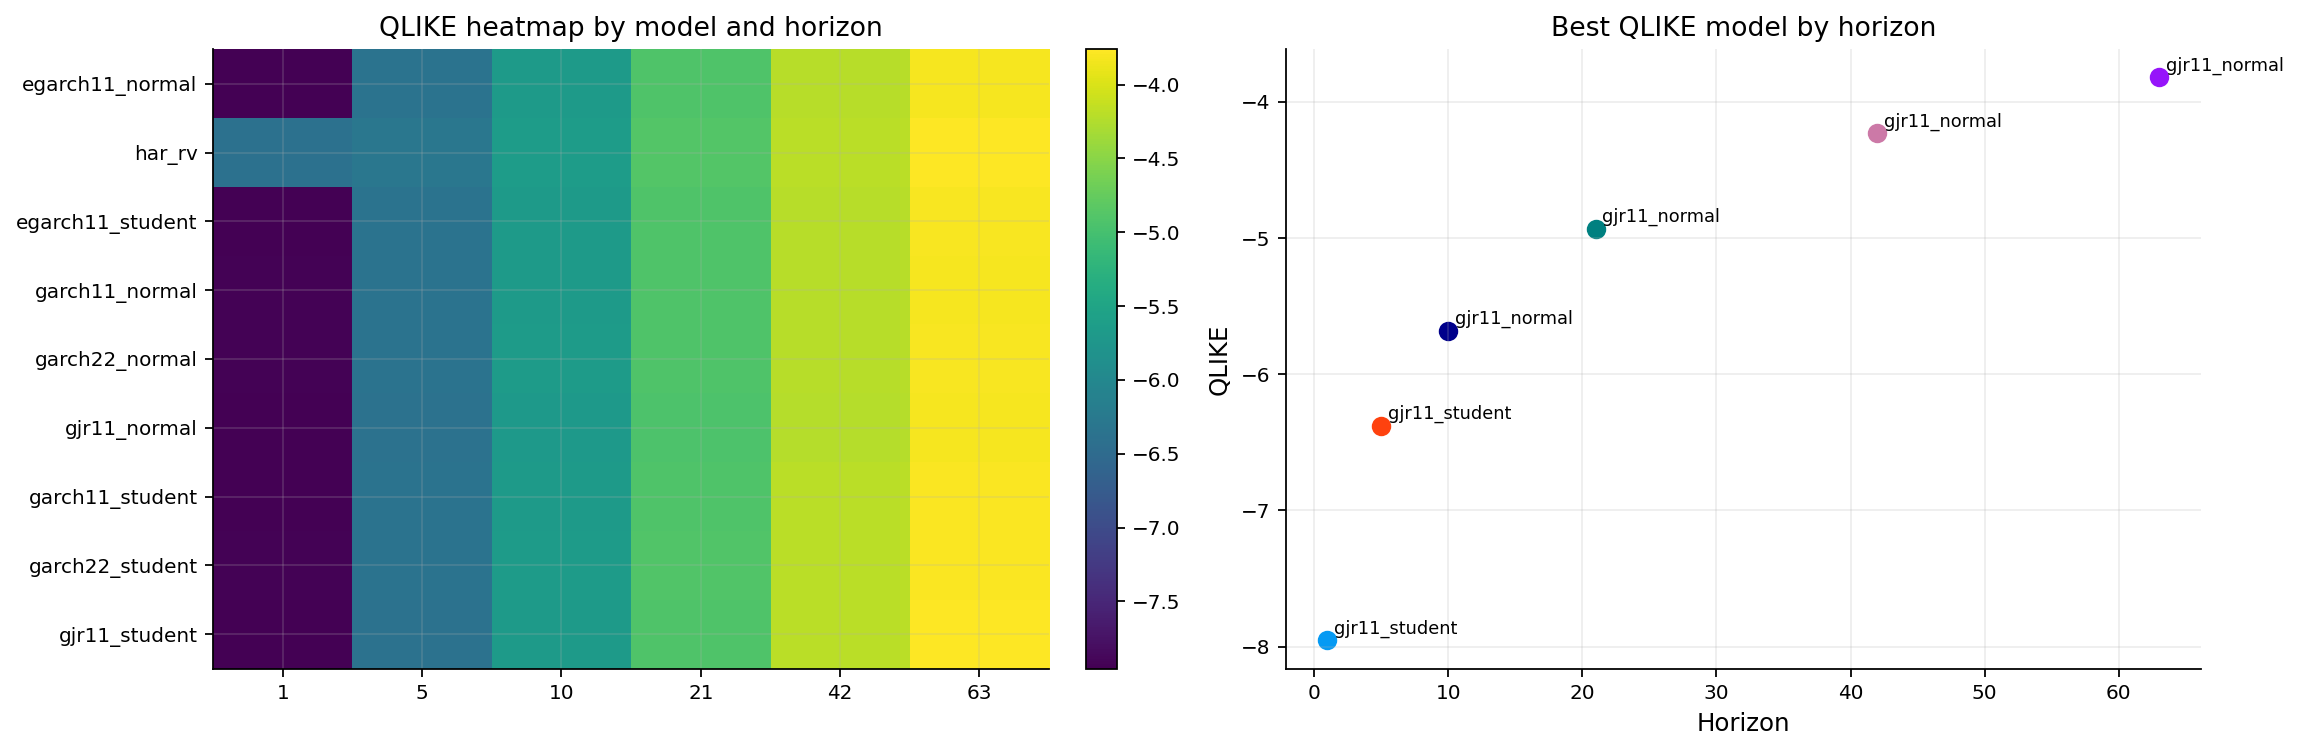

In [10]:
def qlike_loss(realized_var, forecast_var, eps=eps):
    realized_var = np.asarray(realized_var, dtype=float)
    forecast_var = np.asarray(forecast_var, dtype=float)
    mask = np.isfinite(realized_var) & np.isfinite(forecast_var) & (realized_var > 0) & (forecast_var > 0)
    if mask.sum() == 0:
        return np.nan
    rv = np.clip(realized_var[mask], eps, None)
    fv = np.clip(forecast_var[mask], eps, None)
    return float(np.mean(np.log(fv) + rv / fv))

def qlike_array(realized_var, forecast_var, eps=eps):
    rv = np.asarray(realized_var, dtype=float)
    fv = np.asarray(forecast_var, dtype=float)
    out = np.full(len(rv), np.nan, dtype=float)
    mask = np.isfinite(rv) & np.isfinite(fv) & (rv > 0) & (fv > 0)
    out[mask] = np.log(np.clip(fv[mask], eps, None)) + np.clip(rv[mask], eps, None) / np.clip(fv[mask], eps, None)
    return out

def mz_regression(y, x, maxlags=5):
    z = pd.DataFrame({"y": y, "x": x}).replace([np.inf, -np.inf], np.nan).dropna()
    if len(z) < 25:
        return {"alpha": np.nan, "beta": np.nan, "r2": np.nan, "alpha_p": np.nan, "beta_p": np.nan, "n_obs": int(len(z))}
    X = sm.add_constant(z["x"])
    res = sm.OLS(z["y"], X).fit(cov_type="HAC", cov_kwds={"maxlags": maxlags})
    return {
        "alpha": float(res.params.get("const", np.nan)),
        "beta": float(res.params.get("x", np.nan)),
        "r2": float(res.rsquared),
        "alpha_p": float(res.pvalues.get("const", np.nan)),
        "beta_p": float(res.pvalues.get("x", np.nan)),
        "n_obs": int(len(z))}

def dm_test(loss_a, loss_b, h=1):
    d = pd.Series(np.asarray(loss_a, dtype=float) - np.asarray(loss_b, dtype=float)).replace([np.inf, -np.inf], np.nan).dropna().to_numpy()
    n = len(d)
    if n < max(20, int(h) + 5):
        return {"dm_stat": np.nan, "dm_pvalue": np.nan, "n": n}
    mean_d = float(np.mean(d))
    long_run = float(np.var(d, ddof=1))
    max_lag = int(max(1, h - 1))
    for lag in range(1, max_lag + 1):
        cov = np.cov(d[lag:], d[:-lag], ddof=1)[0, 1]
        long_run += 2.0 * (1.0 - lag / (max_lag + 1.0)) * cov
    if long_run <= 0 or not np.isfinite(long_run):
        return {"dm_stat": np.nan, "dm_pvalue": np.nan, "n": n}
    stat = mean_d / math.sqrt(long_run / n)
    pval = 2.0 * (1.0 - norm.cdf(abs(stat)))
    return {"dm_stat": float(stat), "dm_pvalue": float(pval), "n": int(n)}

score_rows = []
for (model, h), g in df_fc_signal.dropna(subset=["realized_var_sum", "forecast_var_sum"]).groupby(["model", "horizon"]):
    err_var = g["forecast_var_sum"] - g["realized_var_sum"]
    err_vol = g["forecast_vol_ann"] - g["realized_vol_ann"]
    corr_var = g[["forecast_var_ann", "realized_var_ann"]].corr().iloc[0, 1] if len(g) >= 3 else np.nan
    corr_vol = g[["forecast_vol_ann", "realized_vol_ann"]].corr().iloc[0, 1] if len(g) >= 3 else np.nan
    mz = mz_regression(g["realized_var_ann"], g["forecast_var_ann"], maxlags=int(h))
    score_rows.append({
        "model": model,
        "horizon": int(h),
        "qlike_var": qlike_loss(g["realized_var_sum"], g["forecast_var_sum"]),
        "rmse_var": float(np.sqrt(np.nanmean(err_var * err_var))),
        "mae_var": float(np.nanmean(np.abs(err_var))),
        "rmse_vol": float(np.sqrt(np.nanmean(err_vol * err_vol))),
        "mae_vol": float(np.nanmean(np.abs(err_vol))),
        "corr_var": float(corr_var) if np.isfinite(corr_var) else np.nan,
        "corr_vol": float(corr_vol) if np.isfinite(corr_vol) else np.nan,
        "mz_alpha": mz["alpha"],
        "mz_beta": mz["beta"],
        "mz_r2": mz["r2"],
        "mz_beta_p": mz["beta_p"],
        "n_obs": int(len(g))})

df_scores = pd.DataFrame(score_rows).sort_values(["horizon", "qlike_var", "rmse_vol"]).reset_index(drop=True)
ranked = df_scores.copy()
for metric in ["qlike_var", "rmse_var", "mae_var", "rmse_vol", "mae_vol"]:
    ranked[f"rank_{metric}"] = ranked.groupby("horizon")[metric].rank(method="average", ascending=True)
ranked["rank_mean"] = ranked[[c for c in ranked.columns if c.startswith("rank_")]].mean(axis=1)
df_model_ranks = ranked.groupby("model", as_index=False)["rank_mean"].mean().sort_values("rank_mean").reset_index(drop=True)

display(df_model_ranks)
display(df_scores[df_scores["horizon"] == 21].sort_values(["qlike_var", "rmse_vol"]).reset_index(drop=True))

dm_rows = []
for h in horizons:
    h_scores = df_scores[df_scores["horizon"] == h].sort_values("qlike_var")
    if h_scores.empty:
        continue
    benchmark = str(h_scores.iloc[0]["model"])
    g = df_fc_signal[df_fc_signal["horizon"] == h].dropna(subset=["realized_var_sum", "forecast_var_sum"]).copy()
    base = g[g["model"] == benchmark].sort_values("date")
    for competitor in sorted(set(g["model"]) - {benchmark}):
        other = g[g["model"] == competitor].sort_values("date")
        joined = base[["date", "forecast_var_sum", "realized_var_sum"]].merge(
            other[["date", "forecast_var_sum"]],
            on="date",
            how="inner",
            suffixes=("_benchmark", "_other"),
        )
        if joined.empty:
            continue
        loss_b = qlike_array(joined["realized_var_sum"], joined["forecast_var_sum_benchmark"])
        loss_o = qlike_array(joined["realized_var_sum"], joined["forecast_var_sum_other"])
        dm_rows.append({"horizon": int(h), "benchmark_model": benchmark, "competitor": competitor, **dm_test(loss_b, loss_o, h=int(h))})
df_dm = pd.DataFrame(dm_rows).sort_values(["horizon", "dm_pvalue"]).reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(14.5, 4.8))
rank_pivot = df_scores.pivot(index="model", columns="horizon", values="qlike_var").loc[df_model_ranks["model"]]
im = axes[0].imshow(rank_pivot.to_numpy(dtype=float), aspect="auto")
axes[0].set_xticks(range(len(rank_pivot.columns)), rank_pivot.columns)
axes[0].set_yticks(range(len(rank_pivot.index)), rank_pivot.index)
axes[0].set_title("QLIKE heatmap by model and horizon")
plt.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)
for h in horizons:
    tmp = df_scores[df_scores["horizon"] == h].sort_values("qlike_var").head(1)
    if not tmp.empty:
        axes[1].scatter([h], [tmp.iloc[0]["qlike_var"]], s=60)
        axes[1].annotate(tmp.iloc[0]["model"], (h, tmp.iloc[0]["qlike_var"]), fontsize=8, xytext=(3, 3), textcoords="offset points")
axes[1].set_title("Best QLIKE model by horizon")
axes[1].set_xlabel("Horizon")
axes[1].set_ylabel("QLIKE")
plt.tight_layout()
plt.show()


First, by average rank across the displayed metrics and horizons, **EGARCH normal** has the best overall rank, followed by **HAR-RV**. This does not mean EGARCH normal wins every horizon. It means it is best overall if we combine all the scores.

Second, at the 21-day horizon, **GJR normal** has the best QLIKE, with QLIKE about -4.933, while EGARCH normal has the lowest RMSE variance error among the top group. We can also see meaningful calibration differences from 21-day table. For example, EGARCH normal has a Mincer–Zarnowitz slope around 0.819, while HAR-RV has a slope above 1.20. This suggests that HAR-RV is less aggressive in some regimes and needs a larger slope to explain realized variance.

We can see the same story from heatmap. Shorter horizons are dominated by asymmetric GARCH-style models, while longer horizons become more mixed and HAR-RV becomes competitive. GARCH reacts quickly to return shocks, while HAR-RV often performs well at medium horizons because it combines daily, weekly, and monthly memory.

The QLIKE values in the tables are negative, which may look odd if you expect a loss to be positive. There is no problem here. QLIKE contains $\log(\widehat{RV})$, and realized variances are often much smaller than 1 when returns are in decimal units. Therefore $\log(\widehat{RV})$ can be strongly negative. What matters is not the absolute sign of QLIKE, but the ordering. lower is better.

We can see that the best model is not universal. Short horizons may prefer models that react quickly to shocks, while longer horizons may prefer smoother or asymmetric specifications. This is the reason that we shouldn't pick one universal best model and use it for all the dates and we should use the best model based on recent performance for each horizon. 

---

## 8) Rolling model selection

The selected forecast at date $t$ is based only on forecast losses whose realized windows were already complete before date $t$. We build a rolling model selector. This selector is a walk forward model selection rule.

For a forecast made on date $s$ with horizon $h$, the realized target is only available on

$$
s+h.
$$

So we first attach a realized availability date:

$$
a(s,h)=s+h.
$$

At current signal date $t$, the selector is only allowed to use historical losses satisfying

$$
a(s,h)<t.
$$

For each horizon, each model has an average recent QLIKE over a rolling lookback window:

$$
\overline{L}_{m,t,h} = \frac{1}{N_{m,t,h}}\sum_{s\in\mathcal{W}_{t,h}}L_{\text{QLIKE}}\left(RV_{s,h},\widehat{RV}_{m,s,h}\right),
$$

where $\mathcal{W}_{t,h}$ contains only past forecasts whose realized outcomes and accuracy are known. The selected model is

$$
m_{t,h}^{*}=\arg\min_m \overline{L}_{m,t,h}.
$$

If there are not enough past observations for a reliable choice, we switch to a fallback median ensemble:

$$
\widehat{RV}_{t,h}^{\text{ens}}=\operatorname{median}_m\left(\widehat{RV}_{m,t,h}\right).
$$


horizon,1,5,10,21,42,63
selected_model,,,,,,
egarch11_normal,76.000000,150.000000,171.000000,194.000000,203.000000,169.000000
egarch11_student,110.000000,41.000000,28.000000,1.000000,0.000000,0.000000
garch11_student,16.000000,2.000000,0.000000,0.000000,0.000000,21.000000
garch22_student,35.000000,0.000000,0.000000,0.000000,0.000000,0.000000
gjr11_normal,6.000000,77.000000,54.000000,62.000000,43.000000,110.000000
gjr11_student,212.000000,181.000000,54.000000,5.000000,0.000000,0.000000
har_rv,0.000000,0.000000,139.000000,173.000000,168.000000,94.000000
median_ensemble,41.000000,45.000000,50.000000,61.000000,82.000000,102.000000


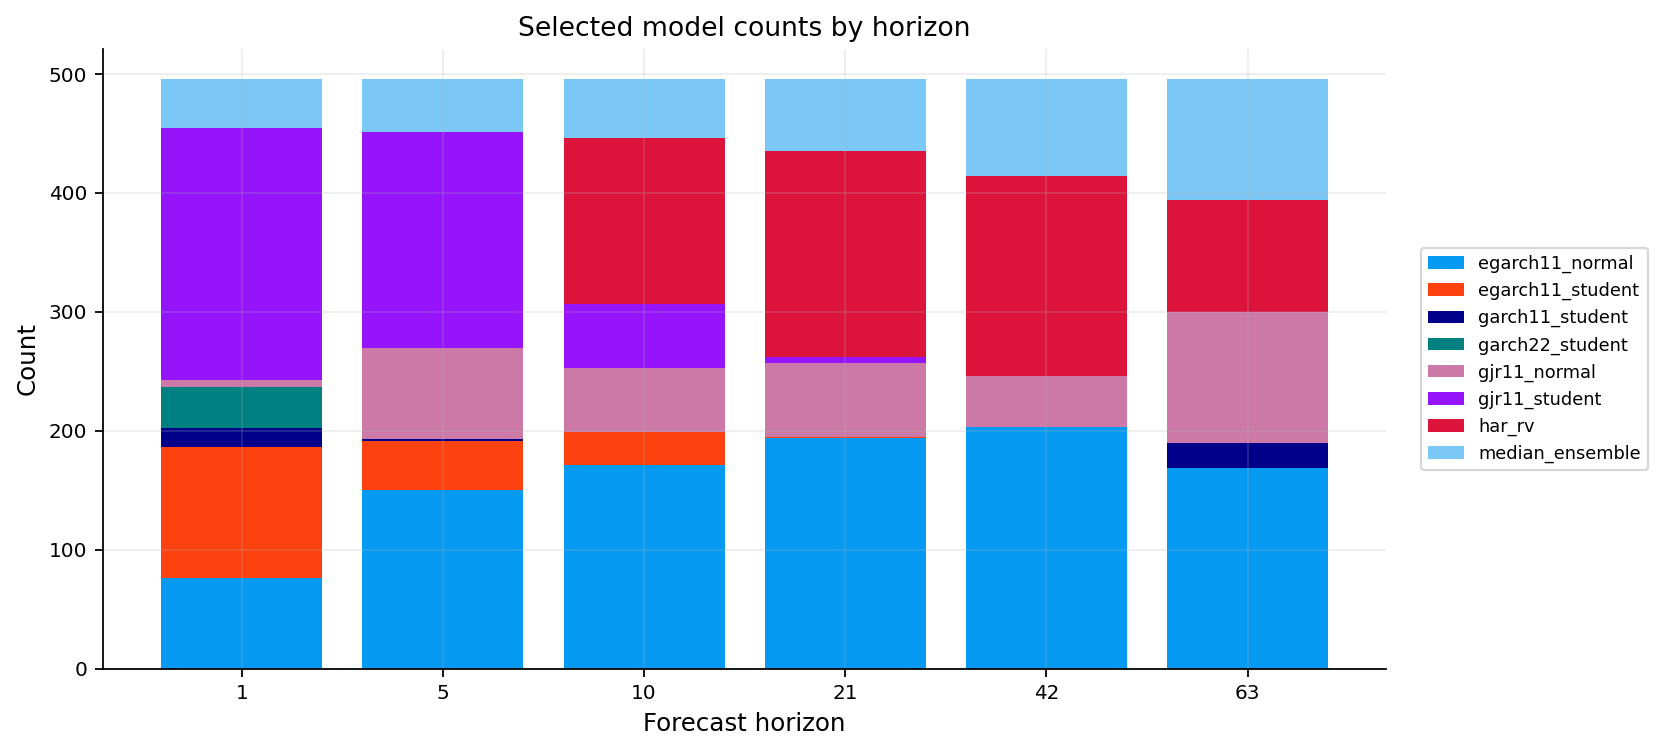

In [11]:
def add_realized_availability_dates(forecast_panel, market_dates):
    dates = pd.DatetimeIndex(pd.to_datetime(market_dates)).normalize()
    date_to_pos = {pd.Timestamp(d): i for i, d in enumerate(dates)}
    out = forecast_panel.copy()
    available = []
    for _, row in out.iterrows():
        d = pd.Timestamp(row["date"]).normalize()
        h = int(row["horizon"])
        pos = date_to_pos.get(d)
        if pos is None or pos + h >= len(dates):
            available.append(pd.NaT)
        else:
            available.append(pd.Timestamp(dates[pos + h]).normalize())
    out["realized_available_date"] = available
    return out

def select_model_by_rolling_past_loss(df_fc_signal, horizons=horizons,
                                      lookback=126, min_obs=40,
                                      fallback="median_ensemble", eps=eps):

    data = df_fc_signal.copy()
    data["date"] = pd.to_datetime(data["date"], errors="coerce").dt.normalize()
    data["horizon"] = data["horizon"].astype(int)
    data = add_realized_availability_dates(data, df_market["trade_date"])
    data["loss_value"] = qlike_array(data["realized_var_sum"], data["forecast_var_sum"], eps=eps)
    rows = []
    for (date, horizon), current in data.groupby(["date", "horizon"], sort=True):
        if int(horizon) not in horizons:
            continue
        current = current.dropna(subset=["forecast_var_sum"]).copy()
        if current.empty:
            continue
        past = data[
            (data["horizon"] == int(horizon))
            & (data["realized_available_date"].notna())
            & (data["realized_available_date"] < pd.Timestamp(date))
            & (data["loss_value"].notna())].copy()
        if lookback and lookback > 0:
            keep_dates = pd.Index(sorted(past["date"].unique()))[-int(lookback):]
            past = past[past["date"].isin(keep_dates)]
        recent = (
            past.groupby("model")
            .agg(recent_loss=("loss_value", "mean"), n_loss=("loss_value", "count"))
            .query("n_loss >= @min_obs")
            .sort_values(["recent_loss", "n_loss"], ascending=[True, False]))
        current_by_model = current.set_index("model", drop=False)
        selected_model = None
        selection_reason = "rolling_past_qlike"
        recent_loss = np.nan
        n_loss = 0
        if not recent.empty:
            valid_ranked = [m for m in recent.index if m in current_by_model.index]
            if valid_ranked:
                selected_model = str(valid_ranked[0])
                selected = current_by_model.loc[selected_model]
                if isinstance(selected, pd.DataFrame):
                    selected = selected.iloc[0]
                recent_loss = float(recent.loc[selected_model, "recent_loss"])
                n_loss = int(recent.loc[selected_model, "n_loss"])
        if selected_model is None:
            selected_model = fallback
            selection_reason = "fallback_median_ensemble"
            selected = current.iloc[0].copy()
            selected["forecast_var_sum"] = float(current["forecast_var_sum"].median())
            selected["forecast_var_ann"] = annualization / int(horizon) * float(selected["forecast_var_sum"])
            selected["forecast_vol_ann"] = float(np.sqrt(max(selected["forecast_var_ann"], 0.0)))
        rows.append({
            "date": pd.Timestamp(date),
            "horizon": int(horizon),
            "selected_model": selected_model,
            "selection_reason": selection_reason,
            "forecast_var_sum": float(selected["forecast_var_sum"]),
            "forecast_var_ann": float(selected["forecast_var_ann"]),
            "forecast_vol_ann": float(selected["forecast_vol_ann"]),
            "realized_var_sum": float(selected["realized_var_sum"]) if pd.notna(selected["realized_var_sum"]) else np.nan,
            "realized_var_ann": float(selected["realized_var_ann"]) if pd.notna(selected["realized_var_ann"]) else np.nan,
            "realized_vol_ann": float(selected["realized_vol_ann"]) if pd.notna(selected["realized_vol_ann"]) else np.nan,
            "recent_loss": recent_loss,
            "n_loss": n_loss,
        })
    return pd.DataFrame(rows).sort_values(["date", "horizon"]).reset_index(drop=True)

selected_fc = select_model_by_rolling_past_loss(df_fc_signal,
    horizons=horizons, lookback=126, min_obs=40,
    fallback="median_ensemble")

selected_model_counts = selected_fc.groupby(["horizon", "selected_model"]).size().rename("n").reset_index()
display(selected_model_counts.pivot_table(index="selected_model", columns="horizon", values="n", fill_value=0))

fig, ax = plt.subplots(figsize=(10.5, 4.8))
plot_counts = selected_model_counts.pivot(index="selected_model", columns="horizon", values="n").fillna(0)
bottom = np.zeros(len(plot_counts.columns))
for model, row in plot_counts.iterrows():
    vals = row.to_numpy(dtype=float)
    ax.bar([str(h) for h in plot_counts.columns], vals, bottom=bottom, label=model)
    bottom += vals
ax.set_title("Selected model counts by horizon")
ax.set_xlabel("Forecast horizon")
ax.set_ylabel("Count")
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5))
plt.tight_layout()
plt.show()


We can see how model preference changes by horizon. EGARCH normal dominates many of the 10, 21, and 42 day selections, HAR-RV becomes important at medium and longer horizons, and the median ensemble appears frequently in periods where the rolling loss history is not yet deep enough. The one day horizon is more unstable and uses a wider mixture of models, especially GJR Student and EGARCH Student.

---

## 9) Term structure of selected forecasts and Implied volatility

Now we have two term structures that we built for SPX in 2022-2023:

1. the **option market term structure** which is computed from solving option prices for volatility for each maturity of that date
2. the **model forecast term structure** which is computed from selected realized variance forecasts across horizons for each date.

The option side is observed at maturity $\tau$ or DTE. The model side is produced at discrete trading day horizons $h\in\{1,5,10,21,42,63\}$. Therefore we don't have a perfect one to one comparison, but it is still informative because both curves are annualized volatilities. If:

$$
\sigma_{\text{IV}}(\tau)>\widehat{\sigma}_{\text{forecast}}(h),
$$

then options are pricing more volatility than the model expects. If:

$$
\sigma_{\text{IV}}(\tau)<\widehat{\sigma}_{\text{forecasts}}(h),
$$

then implied volatility is cheap relative to the model forecast.

We show this relation in four sample dates that are kind of in different volatility states

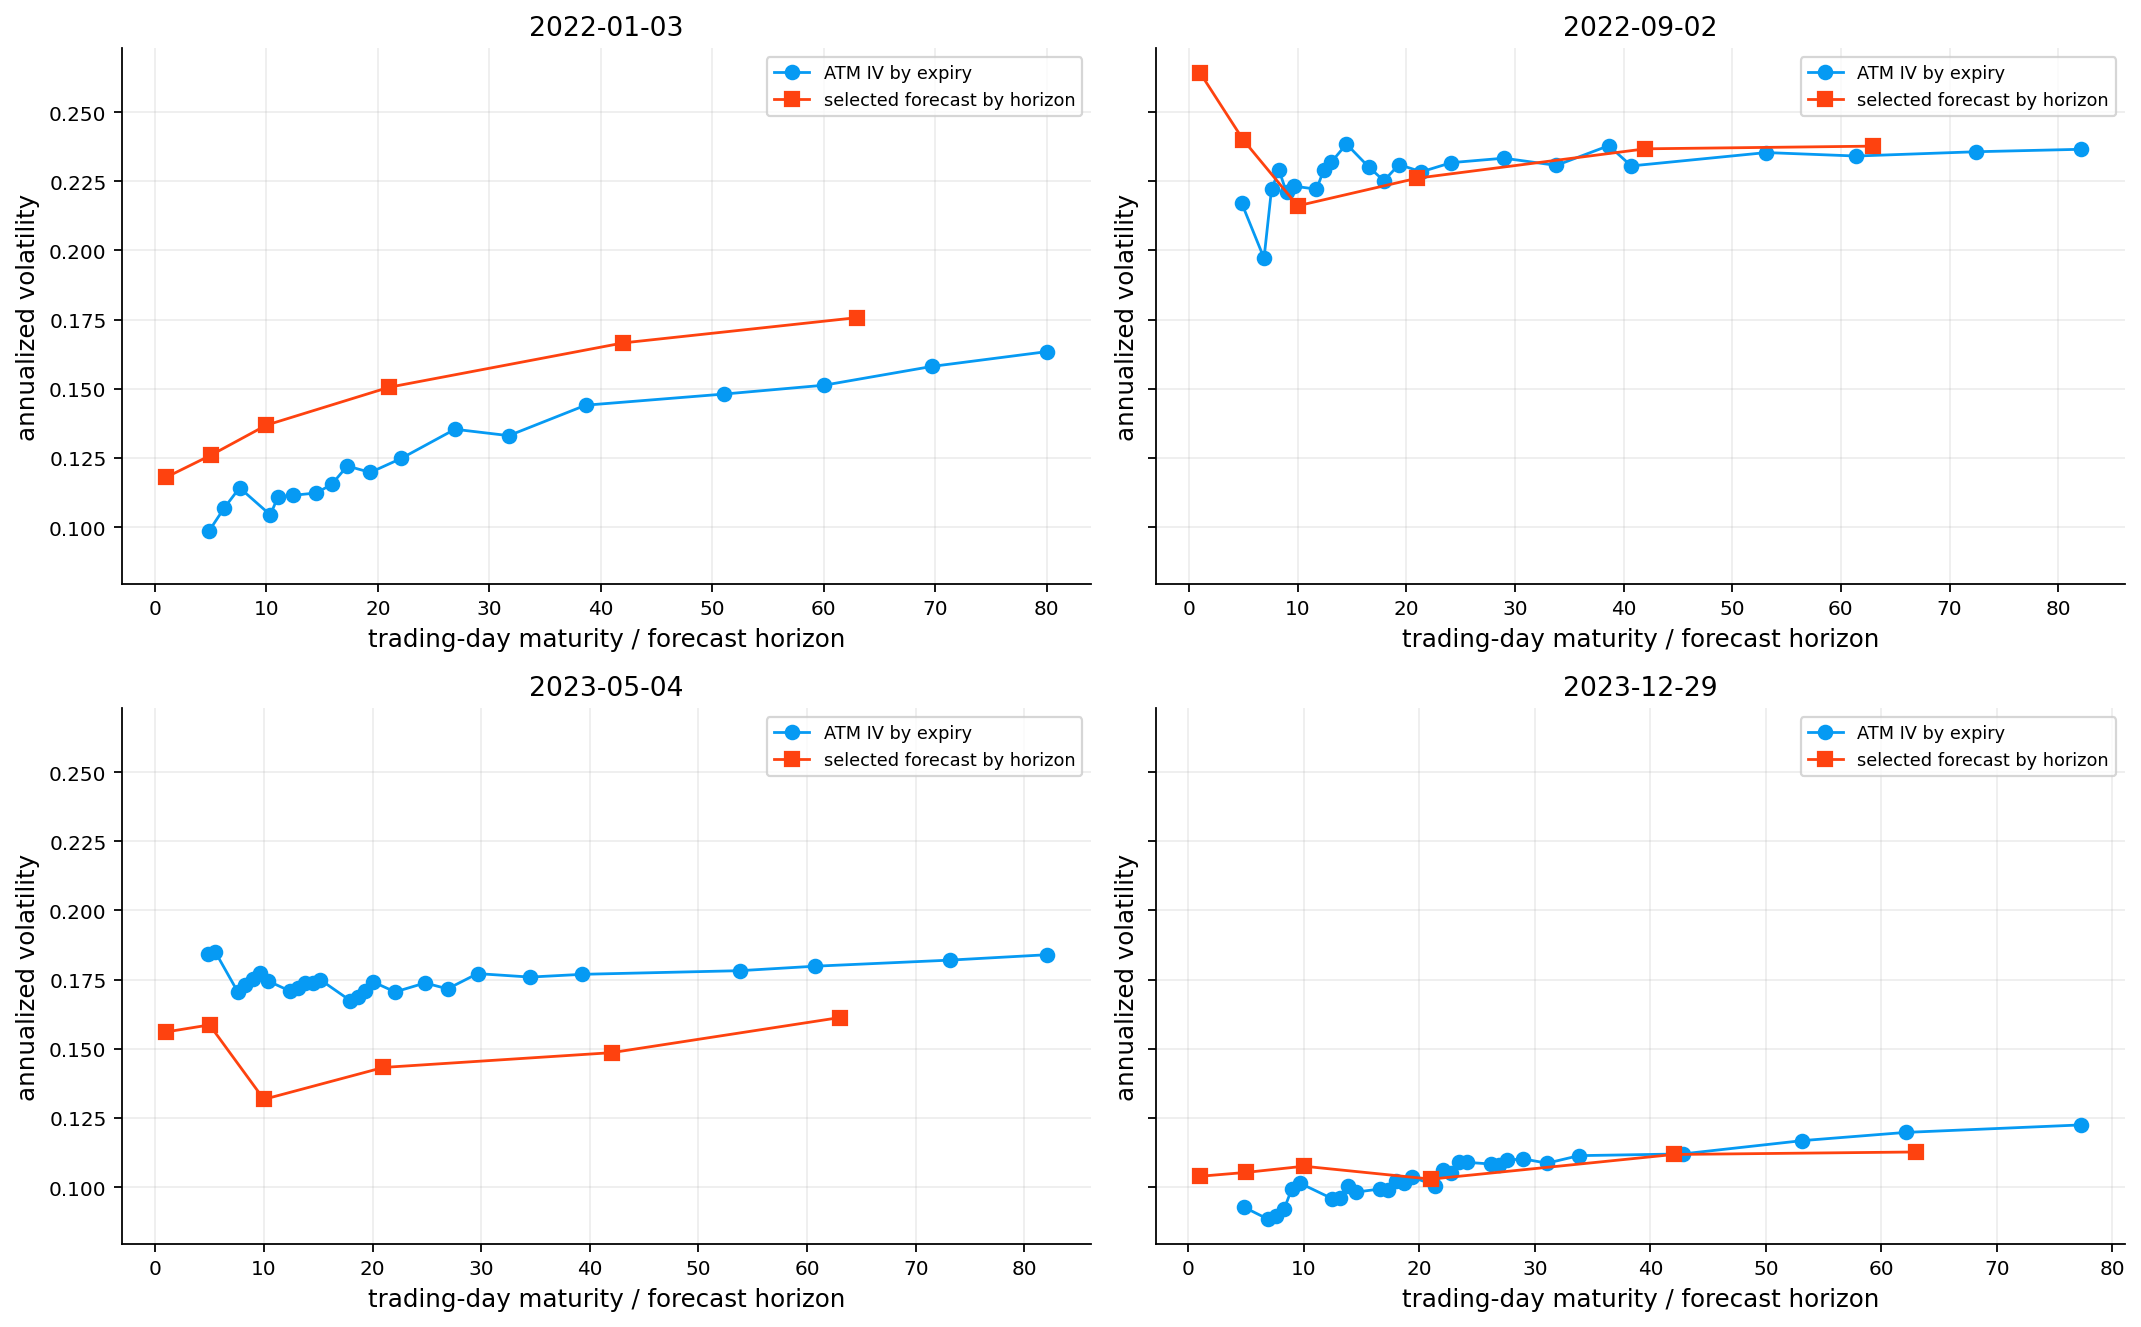

,date,horizon,selected_model,forecast_vol_ann,realized_vol_ann
0,2022-01-03,1,median_ensemble,0.118018,0.009998
1,2022-01-03,5,median_ensemble,0.125970,0.142585
2,2022-01-03,10,median_ensemble,0.136869,0.162306
3,2022-01-03,21,median_ensemble,0.150552,0.185920
4,2022-01-03,42,median_ensemble,0.166578,0.206689
5,2022-01-03,63,median_ensemble,0.175724,0.212171
990,2022-09-02,1,gjr11_student,0.264238,0.065140
991,2022-09-02,5,gjr11_normal,0.239860,0.191962
992,2022-09-02,10,egarch11_normal,0.216122,0.271466
993,2022-09-02,21,egarch11_normal,0.226109,0.278505


In [12]:
term_iv_panel = iv_panel_all.copy()
term_iv_panel = term_iv_panel[
    term_iv_panel["dte_trading"].between(min(horizons), max(horizons) * 365.25 / 252.0, inclusive="both")].copy()
term_iv_panel = term_iv_panel.replace([np.inf, -np.inf], np.nan).dropna(subset=["date", "dte_trading", "atm_iv_mid"])

forecast_term_dates = selected_fc.groupby("date")["horizon"].nunique()
iv_term_dates = term_iv_panel.groupby("date")["expiry"].nunique()
eligible_term_dates = pd.Index(sorted(set(forecast_term_dates[forecast_term_dates >= len(horizons)].index) & set(iv_term_dates[iv_term_dates >= 3].index)))
if len(eligible_term_dates) == 0:
    print("No dates have enough IV expiries and selected forecast horizons for the term-structure comparison.")
else:
    sample_positions = np.unique(np.linspace(0, len(eligible_term_dates) - 1, min(4, len(eligible_term_dates))).round().astype(int))
    term_sample_dates = [pd.Timestamp(eligible_term_dates[i]).normalize() for i in sample_positions]
    fig, axes = plt.subplots(2, 2, figsize=(13.5, 8.4), sharey=True)
    axes = axes.ravel()
    for ax, sample_date in zip(axes, term_sample_dates):
        iv_curve = term_iv_panel[term_iv_panel["date"].eq(sample_date)].sort_values("dte_trading")
        fc_curve = selected_fc[selected_fc["date"].eq(sample_date)].sort_values("horizon")
        ax.plot(iv_curve["dte_trading"], iv_curve["atm_iv_mid"],
                marker="o", lw=1.25, label="ATM IV by expiry")
        ax.plot(
            fc_curve["horizon"],
            fc_curve["forecast_vol_ann"],
            marker="s",
            lw=1.25,
            label="selected forecast by horizon")
        
        ax.set_title(str(sample_date.date()))
        ax.set_xlabel("trading-day maturity / forecast horizon")
        ax.set_ylabel("annualized volatility")
        ax.legend(loc="best")
    for ax in axes[len(term_sample_dates):]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()

    display(selected_fc[selected_fc["date"].isin(term_sample_dates)][["date", "horizon", "selected_model", "forecast_vol_ann", "realized_vol_ann"]].head(24))


- **2022-01-03:** the model forecast curve is above the ATM IV curve across much of the term structure. This means the model expected more realized movement than the option market was pricing.

- **2022-09-02:** IV and selected forecasts are much closer, and both curves sit around a high-volatility level. This is a more balanced regime.

- **2023-05-04:** ATM IV is generally above the model forecast curve, especially at longer maturities, which means market is pricing options based on a higher volatility relative to realized volatility forecasts.

- **2023-12-29:** both curves are low and relatively flat, showing a calmer state.

---

## 10) Variance risk premium

The variance risk premium is the bridge between theoretical forecasting and real markets. The option market quotes implied volatility, while the econometric model forecasts realized variance. To compare them, both must be placed on the same maturity scale.

The selected forecast curve should be interpolated to the option's trading day DTE. If the option has trading day maturity $d$, the interpolated forecasted variance sum is

$$
\widehat{RV}_{t,d}^{\text{sum}}=\operatorname{Interp}\left(\widehat{RV}_{t,h}^{\text{sum}};h\in\{1,5,10,21,42,63\}\right).
$$

Then the annualized forecast variance is

$$
\widehat{\sigma}_{t,d}^{2}=\frac{252}{d}\widehat{RV}_{t,d}^{\text{sum}}.
$$

and the implied annualized variance is simply

$$
\sigma_{\text{IV},t}^{2}.
$$

And then the variance risk premium signal is

$$
VRP_t=\sigma_{\text{IV},t}^{2}-\widehat{\sigma}_{t,d}^{2}.
$$

Also the volatility spread is:

$$
\sigma_{\text{IV},t} - \widehat{\sigma}_{T,d},
$$

The sign convention is critical:

- $VRP_t>0$ means **implied variance is rich** compared to the model forecast.
- $VRP_t<0$ means **implied variance is cheap** compared to the model forecast.

We can also standardize the signal in two ways. 1) The rolling z-score is

$$
z_t=\frac{VRP_t-\mu_{t-1}^{(63)}}{\sigma_{t-1}^{(63)}},
$$

where the mean and standard deviation are computed using only past values. 2) The rolling rank is

$$
\text{rank}_t=\frac{1}{N_t}\sum_{s\in\mathcal{W}_{t}}\mathbf{1}_{\{VRP_s\leq VRP_t\}}.
$$

The z-score measures standardized distance from a recent mean. This is sensitive to the scale of recent VRP volatility. If VRP has been very stable, a small move can produce a large z-score. If VRP has been noisy, the same raw move may look less extreme.

The rank measures empirical extremeness. It is less sensitive to outliers and easier to interpret. A rank of 0.10 means the current VRP is in the cheapest 10% of the recent window. A rank of 0.90 means it is in the richest 10%.

Using both makes the signal more robust. The rank catches relative historical extremes, while the z-score captures standardized deviations.

In [13]:
def rolling_past_percentile(series, window=63, min_periods=20):
    values = pd.Series(series, dtype=float).to_numpy()
    out = np.full(len(values), np.nan, dtype=float)
    for i in range(len(values)):
        start = max(0, i - int(window))
        hist = values[start:i]
        hist = hist[np.isfinite(hist)]
        if len(hist) >= min_periods and np.isfinite(values[i]):
            out[i] = float(np.mean(hist <= values[i]))
    return pd.Series(out, index=pd.Series(series).index)

def interpolate_selected_variance_to_dte(selected_fc, iv_daily, horizons=horizons, annualization=annualization):
    fc = selected_fc.copy()
    fc["date"] = pd.to_datetime(fc["date"], errors="coerce").dt.normalize()
    fc["horizon"] = fc["horizon"].astype(int)
    iv = iv_daily.copy()
    iv["date"] = pd.to_datetime(iv["date"], errors="coerce").dt.normalize()
    rows = []
    by_date = {d: g.sort_values("horizon") for d, g in fc.groupby("date")}
    for _, opt in iv.iterrows():
        date = pd.Timestamp(opt["date"]).normalize()
        g = by_date.get(date)
        dte_trading = float(opt["dte_trading"])
        if g is None or not np.isfinite(dte_trading) or dte_trading <= 0:
            continue
        g = g.dropna(subset=["forecast_var_sum"]).sort_values("horizon")
        if g.empty:
            continue
        x = g["horizon"].to_numpy(dtype=float)
        forecast_sum = g["forecast_var_sum"].to_numpy(dtype=float)
        realized_sum = g["realized_var_sum"].to_numpy(dtype=float)
        target = float(np.clip(dte_trading, np.nanmin(x), np.nanmax(x)))
        fc_sum_dte = float(np.interp(target, x, forecast_sum))
        rv_sum_dte = float(np.interp(target, x, realized_sum)) if np.isfinite(realized_sum).any() else np.nan
        fc_var_ann = annualization / target * fc_sum_dte
        rv_var_ann = annualization / target * rv_sum_dte if np.isfinite(rv_sum_dte) else np.nan
        nearest = g.iloc[int(np.argmin(np.abs(x - target)))]
        row = opt.to_dict()
        row.update({
            "target_horizon_trading_days": target,
            "forecast_var_sum_dte": fc_sum_dte,
            "forecast_var_ann": fc_var_ann,
            "forecast_vol_ann": float(np.sqrt(max(fc_var_ann, 0.0))),
            "future_realized_var_sum": rv_sum_dte,
            "future_realized_var_ann": rv_var_ann,
            "future_realized_vol_ann": float(np.sqrt(max(rv_var_ann, 0.0))) if np.isfinite(rv_var_ann) else np.nan,
            "selected_model": nearest["selected_model"],
            "selection_reason": nearest["selection_reason"]})
        rows.append(row)
    out = pd.DataFrame(rows).sort_values("date").reset_index(drop=True)
    if out.empty:
        return out
    out["atm_iv_mid"] = pd.to_numeric(out["atm_iv_mid"], errors="coerce")
    if out["atm_iv_mid"].dropna().median() > 2.0:
        out["atm_iv_mid"] = out["atm_iv_mid"] / 100.0
    out["iv_var_ann"] = out["atm_iv_mid"] ** 2
    out["vrp_var"] = out["iv_var_ann"] - out["forecast_var_ann"]
    out["vol_spread"] = out["atm_iv_mid"] - out["forecast_vol_ann"]
    z_window = 63
    min_periods = 20
    past_mean = out["vrp_var"].shift(1).rolling(z_window, min_periods=min_periods).mean()
    past_std = out["vrp_var"].shift(1).rolling(z_window, min_periods=min_periods).std(ddof=0)
    out["vrp_z"] = (out["vrp_var"] - past_mean) / past_std.replace(0, np.nan)
    out["vrp_rank"] = rolling_past_percentile(out["vrp_var"], window=z_window, min_periods=min_periods).to_numpy()
    return out

vrp_panel = interpolate_selected_variance_to_dte(selected_fc, iv_30d_daily)
required_vrp_cols = [
    "date", "expiry", "strike", "dte_calendar", "dte_trading", "tau", "spot", "forward",
    "atm_iv_mid", "forecast_var_ann", "forecast_vol_ann", "future_realized_var_ann",
    "future_realized_vol_ann", "vrp_var", "vol_spread", "vrp_z", "vrp_rank", "selected_model"]

display(vrp_panel[[c for c in required_vrp_cols if c in vrp_panel.columns]].head())
display(vrp_panel[["vrp_var", "vol_spread", "vrp_z", "vrp_rank"]].describe())


,date,expiry,strike,dte_calendar,dte_trading,tau,spot,forward,atm_iv_mid,forecast_var_ann,forecast_vol_ann,future_realized_var_ann,future_realized_vol_ann,vrp_var,vol_spread,vrp_z,vrp_rank,selected_model
0,2022-01-03,2022-02-04,"4,795.000000",32.000000,22.078029,0.087611,"4,795.570000","4,792.699898",0.124809,0.023162,0.152191,0.035363,0.188049,-0.007585,-0.027383,NaN,NaN,median_ensemble
1,2022-01-04,2022-02-04,"4,775.000000",31.000000,21.388090,0.084873,"4,793.190000","4,791.048784",0.131639,0.021292,0.145917,0.042105,0.205194,-0.003963,-0.014278,NaN,NaN,median_ensemble
2,2022-01-05,2022-02-04,"4,705.000000",30.000000,20.698152,0.082136,"4,700.640000","4,699.800813",0.156209,0.035953,0.189612,0.037389,0.193364,-0.011551,-0.033403,NaN,NaN,median_ensemble
3,2022-01-06,2022-02-04,"4,685.000000",29.000000,20.008214,0.079398,"4,696.250000","4,695.048096",0.161918,0.030902,0.175790,0.037459,0.193542,-0.004684,-0.013871,NaN,NaN,median_ensemble
4,2022-01-07,2022-02-07,"4,670.000000",31.000000,21.388090,0.084873,"4,676.410000","4,674.648924",0.152411,0.027443,0.165658,0.038811,0.197005,-0.004214,-0.013248,NaN,NaN,median_ensemble


,vrp_var,vol_spread,vrp_z,vrp_rank
count,496.000000,496.000000,476.000000,476.000000
mean,-0.005757,-0.012284,0.011296,0.500693
std,0.018905,0.033660,1.230328,0.310434
min,-0.164693,-0.201553,-8.985464,0.000000
25%,-0.010363,-0.028639,-0.617243,0.206349
50%,-0.003663,-0.011763,0.043781,0.507937
75%,0.002919,0.007726,0.655698,0.780303
max,0.040583,0.092577,3.523038,1.000000


We can see that the sample average VRP is negative, about **-0.0057** in variance units, with a median of about **-0.0036**. The minimum is very negative, about **-0.164**, while the maximum is about **0.0406**. This asymmetry means the largest dislocations in this specific sample are cheap IV states where model forecast variance exceeded implied variance by a large amount.

The rolling rank has a mean close to 0.50. This makes it useful for trading thresholds. a low rank is cheap IV, a high rank is rich IV.

VRP distribution is not symmetric. There are much larger negative spikes than positive spikes in this SPX 2 year sample. This is important because strategies that will be built with this signal may not have symmetric frequency or payoff shape. Volatility spread is easier to interpret visually but less theoretically clean. So we use VRP as the main signal.

---

### 10.2 Predicting future RV with IV and Forecasts.

We use a simple OLS model to see which of these has better prediction of future realized volatility. The regression specifications are

$$
RV_{t,\text{future}}^{\text{ann}}=\alpha+\beta_{\text{IV}}\sigma_{\text{IV},t}^{2}+u_t,
$$

$$
RV_{t,\text{future}}^{\text{ann}}=\alpha+\beta_{\text{F}}\widehat{\sigma}_{t}^{2}+u_t,
$$

and

$$
RV_{t,\text{future}}^{\text{ann}}=\alpha+\beta_{\text{IV}}\sigma_{\text{IV},t}^{2}+\beta_{\text{F}}\widehat{\sigma}_{t}^{2}+u_t.
$$

We use HAC standard errors because future realized variance windows overlap. If the option on date $t$ is roughly 30 days to expiry, then the realized variance target for date $t$ and the target for date $t+1$ share most of the same return observations. Then ordinary errors would be too optimistic.

,model,r2,n_obs,const_coef,const_t,const_p,iv_var_ann_coef,iv_var_ann_t,iv_var_ann_p,forecast_var_ann_coef,forecast_var_ann_t,forecast_var_ann_p
0,RV_future_on_IV_var,0.516741,496,0.003610,1.359032,0.174136,0.909618,11.576518,0.000000,NaN,NaN,NaN
1,RV_future_on_forecast_var,0.353486,496,0.014523,2.957850,0.003098,NaN,NaN,NaN,0.534295,4.404296,0.000011
2,RV_future_on_both,0.519463,496,0.003460,1.275710,0.202058,0.826835,6.096125,0.000000,0.075197,0.656163,0.511719


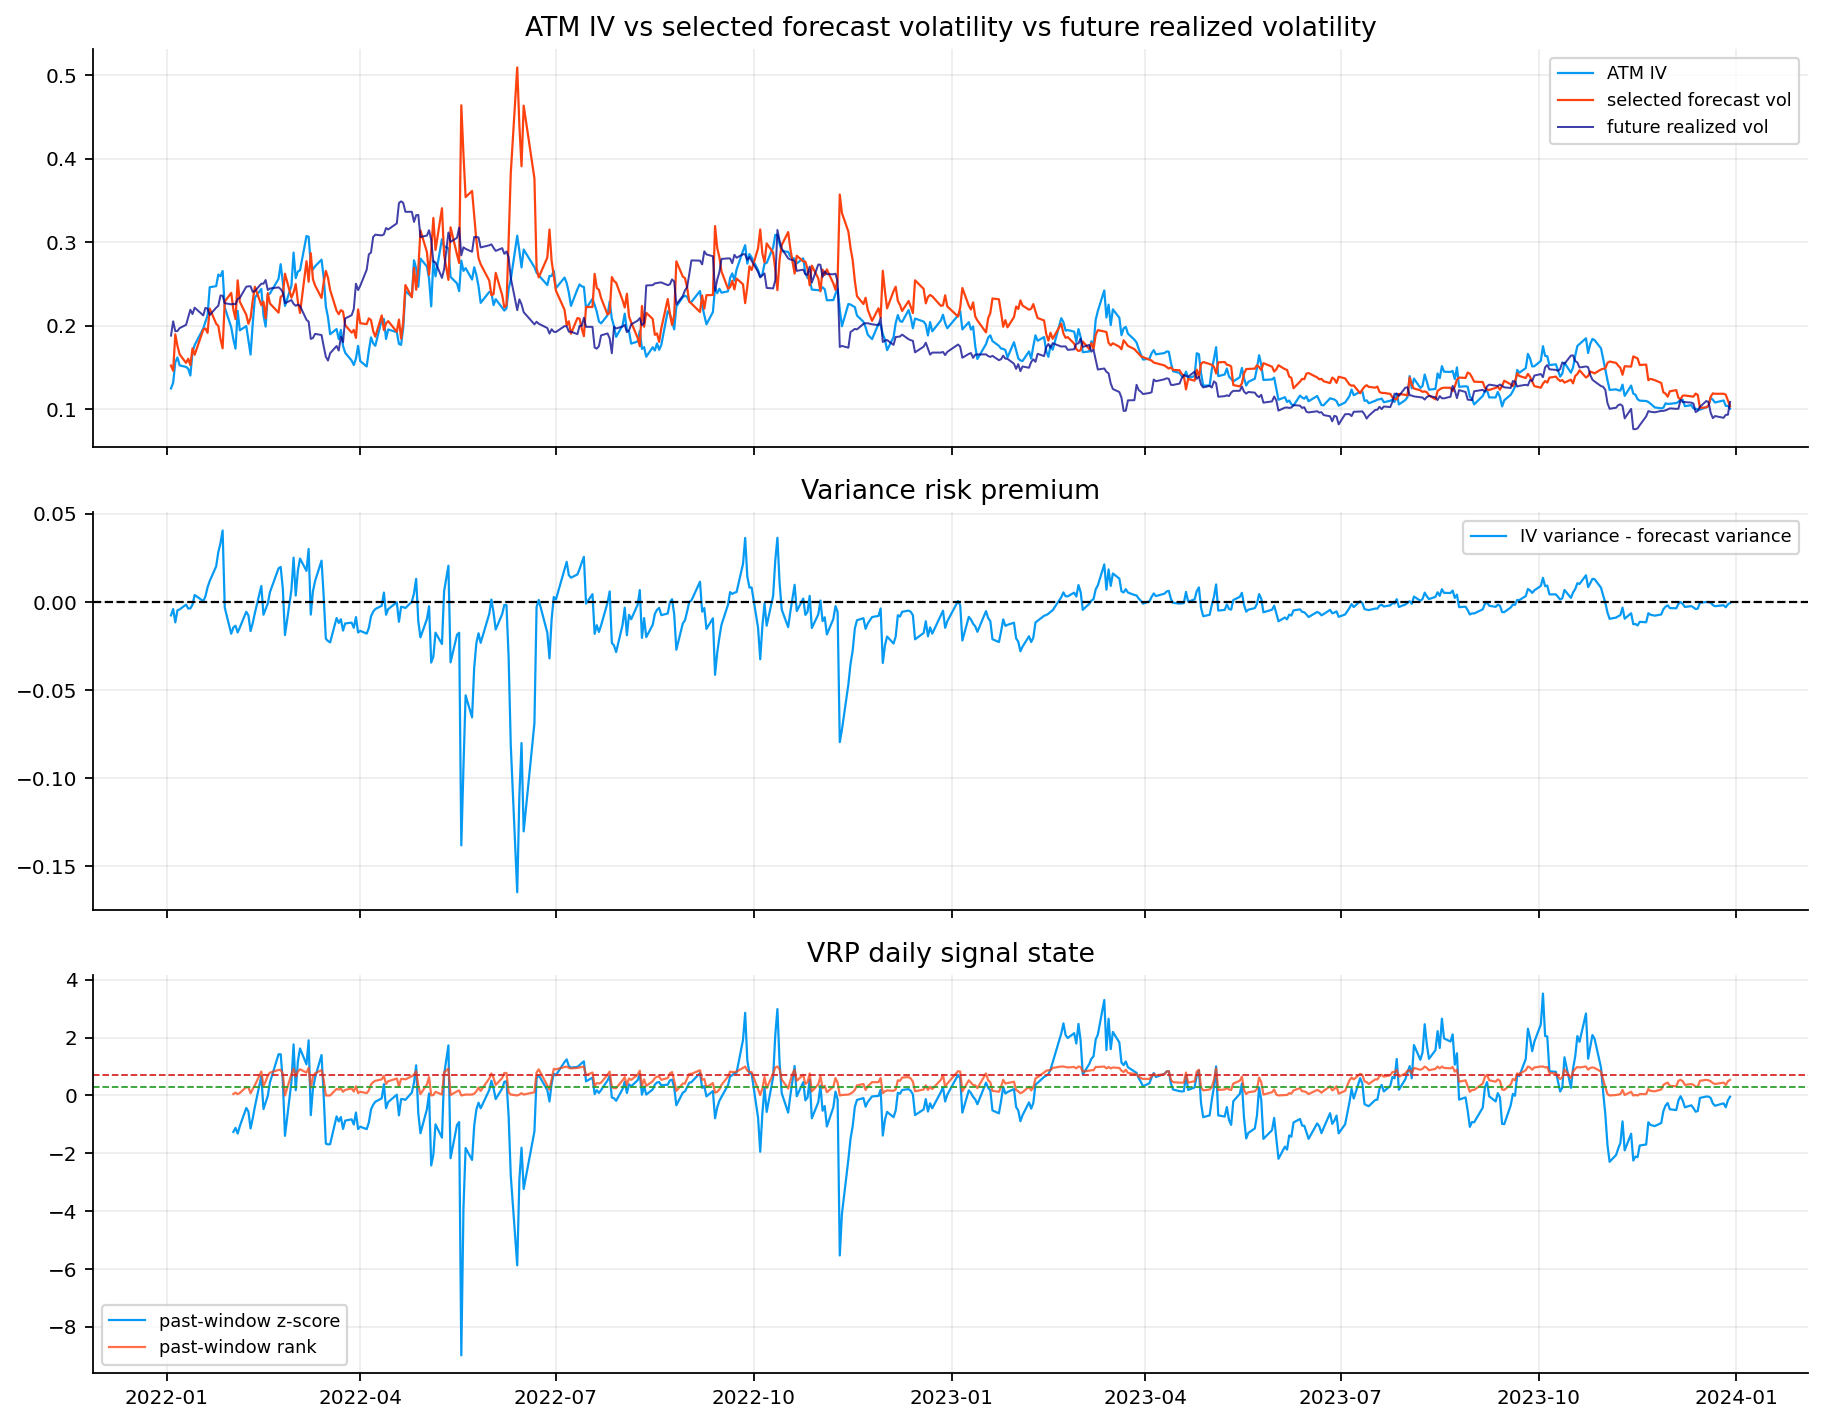

In [14]:
def regression_table_iv_forecast(vrp_panel):
    data = vrp_panel.replace([np.inf, -np.inf], np.nan).dropna(
        subset=["future_realized_var_ann", "iv_var_ann", "forecast_var_ann"]).copy()
    specs = {
        "RV_future_on_IV_var": ["iv_var_ann"],
        "RV_future_on_forecast_var": ["forecast_var_ann"],
        "RV_future_on_both": ["iv_var_ann", "forecast_var_ann"]}
    rows = []
    for name, cols in specs.items():
        z = data[["future_realized_var_ann", *cols]].dropna()
        if len(z) < 30:
            continue
        X = sm.add_constant(z[cols])
        res = sm.OLS(z["future_realized_var_ann"], X).fit(cov_type="HAC", cov_kwds={"maxlags": 5})
        row = {"model": name, "r2": float(res.rsquared), "n_obs": int(len(z))}
        for param in res.params.index:
            row[f"{param}_coef"] = float(res.params[param])
            row[f"{param}_t"] = float(res.tvalues[param])
            row[f"{param}_p"] = float(res.pvalues[param])
        rows.append(row)
    return pd.DataFrame(rows)

df_iv_forecast_regression = regression_table_iv_forecast(vrp_panel)
display(df_iv_forecast_regression)

fig, axes = plt.subplots(3, 1, figsize=(11.5, 9.0), sharex=True)
axes[0].plot(vrp_panel["date"], vrp_panel["atm_iv_mid"], lw=1.0, label="ATM IV")
axes[0].plot(vrp_panel["date"], vrp_panel["forecast_vol_ann"], lw=1.0, label="selected forecast vol")
axes[0].plot(vrp_panel["date"], vrp_panel["future_realized_vol_ann"], lw=0.9, alpha=0.75, label="future realized vol")
axes[0].set_title("ATM IV vs selected forecast volatility vs future realized volatility")
axes[0].legend(loc="best")

axes[1].plot(vrp_panel["date"], vrp_panel["vrp_var"], lw=1.0, label="IV variance - forecast variance")
axes[1].axhline(0.0, lw=1.0, ls="--", c="black")
axes[1].set_title("Variance risk premium")
axes[1].legend(loc="best")

axes[2].plot(vrp_panel["date"], vrp_panel["vrp_z"], lw=1.0, label="past-window z-score")
axes[2].plot(vrp_panel["date"], vrp_panel["vrp_rank"], lw=1.0, alpha=0.75, label="past-window rank")
axes[2].axhline(0.30, lw=0.8, ls="--", c="tab:green")
axes[2].axhline(0.70, lw=0.8, ls="--", c="tab:red")
axes[2].set_title("VRP daily signal state")
axes[2].legend(loc="best")
plt.tight_layout()
plt.show()


We can see from the results:

- IV variance alone has $R^2\approx0.517$.
- Forecast variance alone has $R^2\approx0.355$.
- Using both increases $R^2$ only slightly to about **0.520**.
- In the joint regression, the IV coefficient remains strongly significant, while the forecast-variance coefficient becomes statistically insignificant.

This doesn't mean forecast is udeless. It means that, in this sample, the ATM IV level already contains most of the linear information about future realized variance. The model forecast still matters because the trading signal is **relative value**:

$$
VRP_t=\sigma_{\text{IV},t}^{2}-\widehat{\sigma}_{t}^{2}.
$$

ATM IV, selected forecast volatility, and future realized volatility move together at a broad level, but they separate during stressed periods. We can also see the constructed VRP over time with negative spikes in 2022 where the model forecast was much higher than IV.

A useful way to read the signal is:

>cheap IV state: $\text{rank}_t\leq0.30 \quad\text{or}\quad z_t\leq -0.50$

>rich IV state: $\text{rank}_t\geq0.70 \quad\text{or}\quad z_t\geq 0.50$

---

## 11) Straddle strategy for option trading

A long straddle buys a call and a put with the same strike $K$ and the same expiry. If the call premium is $C$ and the put premium is $P$, the terminal payoff is

$$
\Pi_{\text{long}}(S_T)=\max(S_T-K,0)+\max(K-S_T,0)-(C+P).
$$

Or:

$$
\Pi_{\text{long}}(S_T)=|S_T-K|-(C+P).
$$

The maximum loss is the premium paid:

$$
\Pi_{\min}=-(C+P),
$$

and the break-even points are

$$
S_T=K-(C+P),\qquad S_T=K+(C+P).
$$

For a call and a put with both strikes $K=100$ and call premium $C=6$, and put premium $P=5$, the total premium is 11. The break even prices are therefore 89 and 111. The payoff is V shaped because the position benefits from a large move in either direction.

This payoff can be a good strategy to use VRP as a signal

- When implied volatility is **cheap** relative to forecast volatility, the premium paid for the V-shaped payoff may be too low. That motivates a long straddle.
- When implied volatility is **rich** relative to forecast volatility, the market may be overpaying for convexity. That motivates a short straddle.
- A two-sided strategy can buy convexity in cheap-IV states and sell volatility in rich-IV states at the same time, catching all the signals made by VRP.

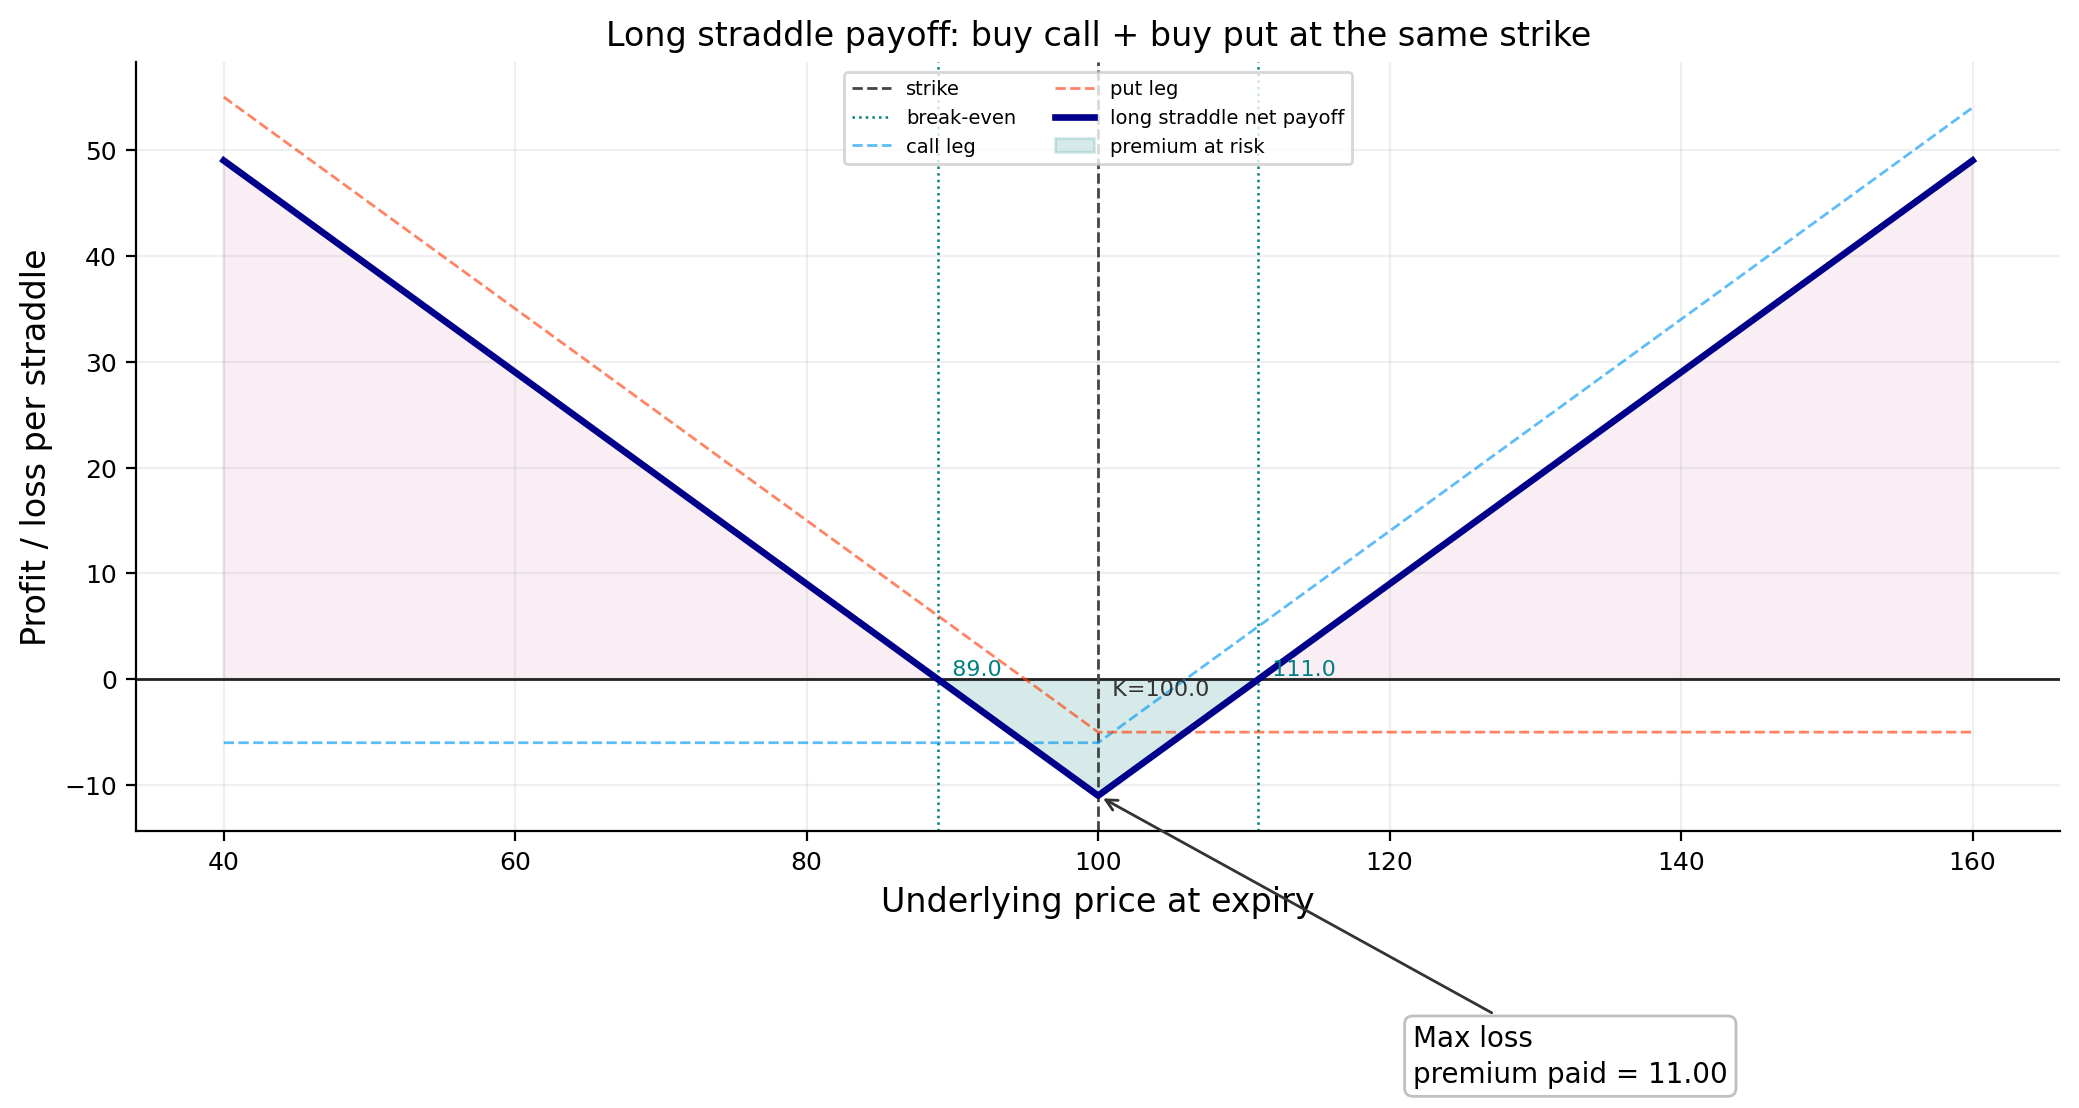

In [15]:
from quantfinlab.plotting.diagrams import plot_straddle_payoff

fig, ax = plot_straddle_payoff(
    spot=100.0,
    strike=100.0,
    call_premium=6.0,
    put_premium=5.0,
    side="long",
    title="Long straddle payoff: buy call + buy put at the same strike")
plt.show()


The long straddle enters at the ask and exits at the bid:

$$
\text{Long entry cashflow}=-u(C_{\text{ask},0}+P_{\text{ask},0})M,
$$

$$
\text{Long exit cashflow}=u(C_{\text{bid},1}+P_{\text{bid},1})M.
$$

The short straddle enters at the bid and exits at the ask:

$$
\text{Short entry cashflow}=u(C_{\text{bid},0}+P_{\text{bid},0})M,
$$

$$
\text{Short exit cashflow}=-u(C_{\text{ask},1}+P_{\text{ask},1})M.
$$

Here $u$ is the number of contracts and $M$ is the contract multiplier. This bid/ask convention is important because it prevents the backtest from assuming that trades can be executed at mid prices. The spread cost is approximately

$$
\text{SpreadCost}=\frac{1}{2}\left[(C_{\text{ask}}-C_{\text{bid}})+(P_{\text{ask}}-P_{\text{bid}})\right]uM
$$

at entry, plus the same thing at exit.

The position sizing rules also matter. For long straddles, the premium budget is

$$
u_{\text{long}}=\left\lfloor\frac{\text{NAV}\times b_{\text{long}}}{(C_{\text{ask}}+P_{\text{ask}})M}\right\rfloor.
$$

The trading rules are based on the VRP state:

$$
\text{cheap}_t=\mathbf{1}\left[\text{rank}_t\leq0.30\;\text{or}\;z_t\leq-0.50\right],
$$

$$
\text{rich}_t=\mathbf{1}\left[\text{rank}_t\geq0.70\;\text{or}\;z_t\geq0.50\right].
$$

So we make and compare four strategies:

- **Always Long Straddle**: We always buy the selected ATM straddle
- **Long Cheap Convexity** : We buy only in cheap-IV states
- **Short Rich Volatility**: We short only in rich-IV states
- **Two Sided VRP Switcher** : We buy cheap convexity and short rich volatility at the same time


In [ ]:
initial_nav = 1_000_000
multiplier = 100
holding_days = 5
allow_overlap = False
fractional_units = False
max_units = None
long_premium_budget_frac = 0.005
short_margin_spot_frac = 0.15
short_margin_budget_frac = 0.02
max_short_notional_frac = 1.0
max_exit_lag = 2

def prepare_straddle_quote_book(raw_chain):
    book = raw_chain.copy()
    book["date"] = pd.to_datetime(book["quote_date"], errors="coerce").dt.normalize()
    book["expiry"] = pd.to_datetime(book["expire_date"], errors="coerce").dt.normalize()
    book["spot"] = pd.to_numeric(book["underlying_last"], errors="coerce")
    book["strike"] = pd.to_numeric(book["strike"], errors="coerce")
    for col in ["c_bid", "c_ask", "p_bid", "p_ask"]:
        book[col] = pd.to_numeric(book[col], errors="coerce")
    book["call_mid"] = 0.5 * (book["c_bid"] + book["c_ask"])
    book["put_mid"] = 0.5 * (book["p_bid"] + book["p_ask"])
    book["dte_calendar"] = (book["expiry"] - book["date"]).dt.total_seconds() / 86400.0
    valid = (
        book["date"].notna() & book["expiry"].notna()
        & (book["strike"] > 0) & (book["spot"] > 0)
        & (book["c_bid"] >= 0) & (book["p_bid"] >= 0)
        & (book["c_ask"] >= book["c_bid"]) & (book["p_ask"] >= book["p_bid"])
        & (book["call_mid"] > 0) & (book["put_mid"] > 0))
    
    cols = ["date", "expiry", "strike", "spot", "dte_calendar", "c_bid", "c_ask", "p_bid", "p_ask", "call_mid", "put_mid"]
    out = book.loc[valid, cols].copy()
    out["strike_key"] = out["strike"].round(8)
    return out.sort_values(["expiry", "strike_key", "date"]).reset_index(drop=True)

quote_book = prepare_straddle_quote_book(df_chain)
market_dates = pd.DatetimeIndex(df_market["trade_date"]).normalize()

def find_exit_quote(book, entry_date, target_exit_date, expiry, strike, max_exit_lag=2):
    entry_date = pd.Timestamp(entry_date).normalize()
    target_exit_date = pd.Timestamp(target_exit_date).normalize()
    expiry = pd.Timestamp(expiry).normalize()
    strike_key = round(float(strike), 8)
    subset = book[
        (book["expiry"] == expiry)
        & (book["strike_key"] == strike_key)
        & (book["date"] > entry_date)
        & (book["date"] >= target_exit_date)].copy()
    if subset.empty:
        return None, "missing_exit_contract"
    dates = pd.DatetimeIndex(sorted(subset["date"].unique()))
    pos = dates.searchsorted(target_exit_date, side="left")
    if pos >= len(dates):
        return None, "missing_exit_within_lag"
    exit_date = pd.Timestamp(dates[pos]).normalize()
    quote_dates = pd.DatetimeIndex(sorted(book["date"].dropna().unique()))
    target_rank = quote_dates.searchsorted(target_exit_date, side="left")
    exit_rank = quote_dates.searchsorted(exit_date, side="left")
    if exit_rank - target_rank > max_exit_lag:
        return None, "missing_exit_within_lag"
    rows = subset[subset["date"] == exit_date].sort_values("date")
    return rows.iloc[0], "exact_exit" if exit_date == target_exit_date else "nearest_later_exit"

def size_long_units(nav, call_ask, put_ask, budget_frac=long_premium_budget_frac, fractional_units=fractional_units, max_units=max_units):
    unit_premium = (float(call_ask) + float(put_ask)) * multiplier
    if not np.isfinite(unit_premium) or unit_premium <= 0:
        return 0.0, unit_premium, "invalid_long_premium"
    units = float(nav) * float(budget_frac) / unit_premium
    units = units if fractional_units else np.floor(units)
    if max_units is not None:
        units = min(units, float(max_units))
    return float(units), float(unit_premium), "" if units > 0 else "long_budget_too_small"

def size_short_units(nav, spot, call_mid, put_mid, short_margin_budget_frac=short_margin_budget_frac, max_short_notional_frac=max_short_notional_frac, fractional_units=fractional_units, max_units=max_units):
    unit_margin_proxy = multiplier * (short_margin_spot_frac * float(spot) + float(call_mid) + float(put_mid))
    unit_notional = multiplier * float(spot)
    if not np.isfinite(unit_margin_proxy) or unit_margin_proxy <= 0 or not np.isfinite(unit_notional) or unit_notional <= 0:
        return 0.0, unit_margin_proxy, unit_notional, "invalid_short_cap"
    units_margin = float(nav) * float(short_margin_budget_frac) / unit_margin_proxy
    units_notional = float(nav) * float(max_short_notional_frac) / unit_notional
    units = min(units_margin, units_notional)
    units = units if fractional_units else np.floor(units)
    if max_units is not None:
        units = min(units, float(max_units))
    return float(units), float(unit_margin_proxy), float(unit_notional), "" if units > 0 else "short_cap_too_small"

def cheap_signal(row, cheap_rank=0.30, cheap_z=-0.50, require_forecast_gt_iv=False):
    rank_hit = pd.notna(row.get("vrp_rank")) and row.get("vrp_rank") <= cheap_rank
    z_hit = pd.notna(row.get("vrp_z")) and row.get("vrp_z") <= cheap_z
    extra_ok = True if not require_forecast_gt_iv else row.get("forecast_vol_ann", np.nan) > row.get("atm_iv_mid", np.nan)
    return bool((rank_hit or z_hit) and extra_ok)

def rich_signal(row, rich_rank=0.70, rich_z=0.50, require_iv_gt_forecast=False):
    rank_hit = pd.notna(row.get("vrp_rank")) and row.get("vrp_rank") >= rich_rank
    z_hit = pd.notna(row.get("vrp_z")) and row.get("vrp_z") >= rich_z
    extra_ok = True if not require_iv_gt_forecast else row.get("atm_iv_mid", np.nan) > row.get("forecast_vol_ann", np.nan)
    return bool((rank_hit or z_hit) and extra_ok)

def decide_strategy(row, strategy, cheap_rank=0.30, rich_rank=0.70, cheap_z=-0.50, rich_z=0.50):
    cheap = cheap_signal(row, cheap_rank=cheap_rank, cheap_z=cheap_z)
    rich = rich_signal(row, rich_rank=rich_rank, rich_z=rich_z)
    if strategy == "AlwaysLongStraddle":
        return "long"
    if strategy == "LongCheapConvexity":
        return "long" if cheap else "cash"
    if strategy == "ShortRichVolatility":
        return "short" if rich else "cash"
    if strategy == "TwoSidedVRPSwitcher":
        if cheap and not rich:
            return "long"
        if rich and not cheap:
            return "short"
        if cheap and rich:
            return "long" if row.get("vrp_var", np.nan) < 0 else "short"
        return "cash"
    raise ValueError(f"Unknown strategy {strategy}")


In [ ]:
def backtest_straddle_strategy(
    strategy_name, signals, quote_book, market_dates,
    cheap_rank=0.30, rich_rank=0.70,cheap_z=-0.50,
    rich_z=0.50, long_budget_frac=long_premium_budget_frac,
    short_budget_frac=short_margin_budget_frac,
    short_notional_frac=max_short_notional_frac, initial_nav=initial_nav):

    signals = signals.sort_values("date").reset_index(drop=True)
    nav = float(initial_nav)
    open_until = pd.Timestamp.min
    trades = []
    skipped = []
    market_dates = pd.DatetimeIndex(market_dates).normalize()
    for _, row in signals.iterrows():
        entry_date = pd.Timestamp(row["date"]).normalize()
        if (not allow_overlap) and entry_date <= open_until:
            skipped.append({"strategy": strategy_name, "date": entry_date, "skip_reason": "open_position"})
            continue
        side = decide_strategy(row, strategy_name, cheap_rank=cheap_rank, rich_rank=rich_rank, cheap_z=cheap_z, rich_z=rich_z)
        if side == "cash":
            skipped.append({"strategy": strategy_name, "date": entry_date, "skip_reason": "no_signal"})
            continue
        if entry_date not in market_dates:
            skipped.append({"strategy": strategy_name, "date": entry_date, "side": side, "skip_reason": "missing_market_date"})
            continue
        pos = market_dates.get_loc(entry_date)
        if pos + holding_days >= len(market_dates):
            skipped.append({"strategy": strategy_name, "date": entry_date, "side": side, "skip_reason": "not_enough_future_dates"})
            continue
        target_exit_date = pd.Timestamp(market_dates[pos + holding_days]).normalize()
        exit_row, exit_flag = find_exit_quote(quote_book, entry_date, target_exit_date, row["expiry"], row["strike"], max_exit_lag=max_exit_lag)
        if exit_row is None:
            skipped.append({"strategy": strategy_name, "date": entry_date, "side": side, "skip_reason": exit_flag})
            continue

        call_bid, call_ask = float(row["call_bid"]), float(row["call_ask"])
        put_bid, put_ask = float(row["put_bid"]), float(row["put_ask"])
        call_mid, put_mid = float(row["call_mid"]), float(row["put_mid"])
        if side == "long":
            long_fractional_units = bool(fractional_units or strategy_name == "AlwaysLongStraddle")
            units, unit_cap, skip_reason = size_long_units(
                nav, call_ask, put_ask,
                budget_frac=long_budget_frac,
                fractional_units=long_fractional_units)
            entry_call_price, entry_put_price = call_ask, put_ask
            exit_call_price, exit_put_price = float(exit_row["c_bid"]), float(exit_row["p_bid"])
            entry_cashflow = -units * (entry_call_price + entry_put_price) * multiplier
            exit_cashflow = units * (exit_call_price + exit_put_price) * multiplier
            margin_proxy = np.nan
            cap_used = units * unit_cap
            premium_paid_or_received = abs(entry_cashflow)
        else:
            units, unit_margin, unit_notional, skip_reason = size_short_units(
                nav, float(row["spot"]), call_mid, put_mid,
                short_margin_budget_frac=short_budget_frac,
                max_short_notional_frac=short_notional_frac)
            
            entry_call_price, entry_put_price = call_bid, put_bid
            exit_call_price, exit_put_price = float(exit_row["c_ask"]), float(exit_row["p_ask"])
            entry_cashflow = units * (entry_call_price + entry_put_price) * multiplier
            exit_cashflow = -units * (exit_call_price + exit_put_price) * multiplier
            margin_proxy = units * unit_margin
            cap_used = margin_proxy
            premium_paid_or_received = entry_cashflow
        if units <= 0:
            skipped.append({"strategy": strategy_name, "date": entry_date, "side": side, "skip_reason": skip_reason})
            continue
        net_pnl = entry_cashflow + exit_cashflow
        nav += net_pnl
        exit_date = pd.Timestamp(exit_row["date"]).normalize()
        open_until = exit_date
        entry_spread_proxy = 0.5 * ((call_ask - call_bid) + (put_ask - put_bid)) * units * multiplier
        exit_spread_proxy = 0.5 * ((float(exit_row["c_ask"]) - float(exit_row["c_bid"])) + (float(exit_row["p_ask"]) - float(exit_row["p_bid"]))) * units * multiplier
        notional_exposure = units * float(row["spot"]) * multiplier
        denom = abs(entry_cashflow) if side == "long" else margin_proxy
        trades.append({
            "strategy": strategy_name, "side": side, "entry_date": entry_date,
            "exit_date": exit_date, "expiry": pd.Timestamp(row["expiry"]).normalize(),
            "strike": float(row["strike"]), "dte_entry": float(row["dte_calendar"]),
            "dte_exit": float(exit_row["dte_calendar"]), "spot_entry": float(row["spot"]),
            "spot_exit": float(exit_row["spot"]), "atm_iv_entry": float(row["atm_iv_mid"]),
            "forecast_vol_entry": float(row["forecast_vol_ann"]),
            "forecast_var_entry": float(row["forecast_var_ann"]),
            "vrp_var": float(row["vrp_var"]),
            "vrp_z": float(row["vrp_z"]) if pd.notna(row["vrp_z"]) else np.nan,
            "vrp_rank": float(row["vrp_rank"]) if pd.notna(row["vrp_rank"]) else np.nan,
            "selected_model": row["selected_model"],
            "units": float(units), "contract_multiplier": float(multiplier),
            "entry_call_price": entry_call_price, "entry_put_price": entry_put_price,
            "exit_call_price": exit_call_price, "exit_put_price": exit_put_price,
            "entry_cashflow": float(entry_cashflow), "exit_cashflow": float(exit_cashflow),
            "gross_pnl": float(net_pnl), "net_pnl": float(net_pnl),
            "premium_paid_or_received": float(premium_paid_or_received),
            "margin_proxy": float(margin_proxy) if np.isfinite(margin_proxy) else np.nan,
            "notional_exposure": float(notional_exposure), "cap_used": float(cap_used),
            "spread_cost_proxy": float(entry_spread_proxy + exit_spread_proxy),
            "return_on_premium_or_margin": float(net_pnl / denom) if denom and np.isfinite(denom) else np.nan,
            "entry_flag": "entered", "exit_flag": exit_flag, "skip_reason": ""})
        
    trades_df = pd.DataFrame(trades)
    skipped_df = pd.DataFrame(skipped)
    start_date = pd.Timestamp(signals["date"].min()).normalize()
    end_date = pd.Timestamp(signals["date"].max()).normalize()
    if not trades_df.empty and "exit_date" in trades_df:
        end_date = max(end_date, pd.Timestamp(trades_df["exit_date"].max()).normalize())
    eq_dates = market_dates[(market_dates >= start_date) & (market_dates <= end_date)]
    equity = pd.DataFrame({"date": eq_dates})
    if trades_df.empty:
        equity["strategy_pnl"] = 0.0
        equity["nav"] = float(initial_nav)
    else:
        pnl_by_date = trades_df.groupby("exit_date")["net_pnl"].sum()
        equity["strategy_pnl"] = equity["date"].map(pnl_by_date).fillna(0.0)
        equity["nav"] = float(initial_nav) + equity["strategy_pnl"].cumsum()
    equity["running_max_nav"] = equity["nav"].cummax()
    equity["drawdown"] = equity["nav"] / equity["running_max_nav"] - 1.0
    equity["strategy"] = strategy_name
    return trades_df, equity, skipped_df

def run_overlay_suite(signals, cheap_rank=0.30, rich_rank=0.70, cheap_z=-0.50, rich_z=0.50, 
                      long_budget_frac=long_premium_budget_frac, 
                      short_budget_frac=short_margin_budget_frac, short_notional_frac=max_short_notional_frac):
    strategy_names = ["AlwaysLongStraddle", "LongCheapConvexity", "ShortRichVolatility", "TwoSidedVRPSwitcher"]
    return {
        name: backtest_straddle_strategy(name, signals, quote_book, market_dates,
                                         cheap_rank=cheap_rank, rich_rank=rich_rank,
                                         cheap_z=cheap_z, rich_z=rich_z,
                                         long_budget_frac=long_budget_frac,
                                         short_budget_frac=short_budget_frac,
                                         short_notional_frac=short_notional_frac)
        for name in strategy_names}

backtests_default = run_overlay_suite(vrp_panel)

def summarize_strategy_backtests(backtests, initial_nav=initial_nav):
    rows = []
    for name, (trades, equity, skipped) in backtests.items():
        nav = equity["nav"] if not equity.empty else pd.Series([initial_nav])
        daily_ret = nav.pct_change().replace([np.inf, -np.inf], np.nan).dropna()
        downside = daily_ret[daily_ret < 0]
        row = {
            "strategy": name,
            "total_net_pnl": float(nav.iloc[-1] - initial_nav),
            "return_on_initial_nav": float(nav.iloc[-1] / initial_nav - 1.0),
            "ann_vol": float(daily_ret.std(ddof=1) * np.sqrt(annualization)),
            "sharpe": float(daily_ret.mean() / daily_ret.std(ddof=1) * np.sqrt(annualization)),
            "sortino": float(daily_ret.mean() / downside.std(ddof=1) * np.sqrt(annualization)),
            "max_drawdown": float(equity["drawdown"].min()) if "drawdown" in equity else np.nan,
            "n_trades": int(len(trades)),
            "n_skipped": int(len(skipped))}
        
        if not trades.empty:
            row.update({
                "hit_rate": float((trades["net_pnl"] > 0).mean()),
                "avg_trade_pnl": float(trades["net_pnl"].mean()),
                "median_trade_pnl": float(trades["net_pnl"].median()),
                "best_trade": float(trades["net_pnl"].max()),
                "worst_trade": float(trades["net_pnl"].min()),
                "avg_units": float(trades["units"].mean()),
                "avg_premium_paid_or_received": float(trades["premium_paid_or_received"].mean()),
                "avg_margin_proxy": float(trades["margin_proxy"].mean()),
                "avg_notional_exposure": float(trades["notional_exposure"].mean()),
                "total_spread_cost_proxy": float(trades["spread_cost_proxy"].sum()),
                "avg_vrp_rank": float(trades["vrp_rank"].mean()),
                "avg_vrp_z": float(trades["vrp_z"].mean())})
        rows.append(row)
    return pd.DataFrame(rows)

summary_default = summarize_strategy_backtests(backtests_default)

vrp_strategy_counts = summary_default[summary_default["strategy"].isin(["LongCheapConvexity", "ShortRichVolatility", "TwoSidedVRPSwitcher"])]["n_trades"]
if len(vrp_strategy_counts) and (vrp_strategy_counts < 20).any():
    print("Warning: at least one VRP strategy has fewer than 20 trades under the default integer-contract caps.")
    print("Running documented sensitivity: cheap rank <= 0.40, rich rank >= 0.60, with larger premium/margin caps.")
    backtests_sensitivity = run_overlay_suite(
        vrp_panel, cheap_rank=0.40, rich_rank=0.60,
        cheap_z=-0.35, rich_z=0.35,
        long_budget_frac=0.015, short_budget_frac=0.08,
        short_notional_frac=2.0)
    
    summary_sensitivity = summarize_strategy_backtests(backtests_sensitivity)
    display(summary_sensitivity)
    backtests_for_plots = backtests_sensitivity
    summary_for_plots = summary_sensitivity
else:
    backtests_for_plots = backtests_default
    summary_for_plots = summary_default

Running documented sensitivity: cheap rank <= 0.40, rich rank >= 0.60, with larger premium/margin caps.


,strategy,total_net_pnl,return_on_initial_nav,ann_vol,sharpe,sortino,max_drawdown,n_trades,n_skipped,hit_rate,...,median_trade_pnl,best_trade,worst_trade,avg_units,avg_premium_paid_or_received,avg_margin_proxy,avg_notional_exposure,total_spread_cost_proxy,avg_vrp_rank,avg_vrp_z
0,AlwaysLongStraddle,"-14,184.834091",-0.014185,0.017454,-0.403850,-0.464032,-0.038538,83,413,0.313253,...,-816.918423,"10,382.222078","-3,302.577234",0.918046,"15,052.141233",NaN,"388,832.663105","19,534.666808",0.492974,0.040162
1,LongCheapConvexity,"6,990.000000",0.006990,0.008769,0.404704,0.255385,-0.008429,18,478,0.500000,...,-245.000000,"8,810.000000","-3,060.000000",1.000000,"12,342.222222",NaN,"433,555.166667","4,635.000000",0.204586,-0.865905
2,ShortRichVolatility,"26,560.000000",0.026560,0.010112,1.311666,0.442918,-0.012985,40,456,0.750000,...,"1,280.000000","3,400.000000","-7,260.000000",1.000000,"17,113.000000","78,439.670000","408,435.300000","8,655.000000",0.780159,0.808250
3,TwoSidedVRPSwitcher,"25,920.000000",0.025920,0.013148,0.987493,0.537576,-0.012985,51,445,0.627451,...,940.000000,"8,810.000000","-7,260.000000",1.000000,"16,101.372549","78,598.189474","415,106.901961","10,570.000000",0.637722,0.434870


In [18]:
all_trades = pd.concat([trades for trades, _, _ in backtests_for_plots.values()], ignore_index=True) if backtests_for_plots else pd.DataFrame()
all_equity = pd.concat([equity for _, equity, _ in backtests_for_plots.values()], ignore_index=True) if backtests_for_plots else pd.DataFrame()

display(summary_for_plots)
if not all_trades.empty:
    trade_count_by_year = all_trades.assign(year=all_trades["entry_date"].dt.year).pivot_table(index="year", columns="strategy", values="net_pnl", aggfunc="count", fill_value=0)
    display(trade_count_by_year)

    all_trades["vrp_decile"] = pd.cut(all_trades["vrp_rank"], bins=np.linspace(0, 1, 11), include_lowest=True)
    pnl_by_decile = (
        all_trades.dropna(subset=["vrp_decile"])
        .groupby(["strategy", "vrp_decile"], observed=True)
        .agg(n_trades=("net_pnl", "size"), total_pnl=("net_pnl", "sum"), avg_pnl=("net_pnl", "mean"), hit_rate=("net_pnl", lambda x: float((x > 0).mean())))
        .reset_index())

    side_breakdown = all_trades.groupby(["strategy", "side"]).agg(n=("net_pnl", "size"), total_pnl=("net_pnl", "sum"), avg_pnl=("net_pnl", "mean")).reset_index()

    regime_edges = [-np.inf, 0.30, 0.70, np.inf]
    regime_labels = ["cheap VRP", "neutral VRP", "rich VRP"]
    all_trades["vrp_regime"] = pd.cut(all_trades["vrp_rank"], bins=regime_edges, labels=regime_labels)
    regime_counts = all_trades.groupby(["strategy", "vrp_regime"], observed=True).agg(n=("net_pnl", "size"), total_pnl=("net_pnl", "sum")).reset_index()
    display(regime_counts)
else:
    print("No strategy trades were generated; inspect skipped reasons below.")
    

,strategy,total_net_pnl,return_on_initial_nav,ann_vol,sharpe,sortino,max_drawdown,n_trades,n_skipped,hit_rate,...,median_trade_pnl,best_trade,worst_trade,avg_units,avg_premium_paid_or_received,avg_margin_proxy,avg_notional_exposure,total_spread_cost_proxy,avg_vrp_rank,avg_vrp_z
0,AlwaysLongStraddle,"-14,184.834091",-0.014185,0.017454,-0.403850,-0.464032,-0.038538,83,413,0.313253,...,-816.918423,"10,382.222078","-3,302.577234",0.918046,"15,052.141233",NaN,"388,832.663105","19,534.666808",0.492974,0.040162
1,LongCheapConvexity,"6,990.000000",0.006990,0.008769,0.404704,0.255385,-0.008429,18,478,0.500000,...,-245.000000,"8,810.000000","-3,060.000000",1.000000,"12,342.222222",NaN,"433,555.166667","4,635.000000",0.204586,-0.865905
2,ShortRichVolatility,"26,560.000000",0.026560,0.010112,1.311666,0.442918,-0.012985,40,456,0.750000,...,"1,280.000000","3,400.000000","-7,260.000000",1.000000,"17,113.000000","78,439.670000","408,435.300000","8,655.000000",0.780159,0.808250
3,TwoSidedVRPSwitcher,"25,920.000000",0.025920,0.013148,0.987493,0.537576,-0.012985,51,445,0.627451,...,940.000000,"8,810.000000","-7,260.000000",1.000000,"16,101.372549","78,598.189474","415,106.901961","10,570.000000",0.637722,0.434870


strategy,AlwaysLongStraddle,LongCheapConvexity,ShortRichVolatility,TwoSidedVRPSwitcher
year,,,,
2022,42,0,15,15
2023,41,18,25,36


,strategy,vrp_regime,n,total_pnl
0,AlwaysLongStraddle,cheap VRP,26,"8,731.902432"
1,AlwaysLongStraddle,neutral VRP,26,"-1,455.206718"
2,AlwaysLongStraddle,rich VRP,27,"-27,110.015426"
3,LongCheapConvexity,cheap VRP,14,"10,060.000000"
4,LongCheapConvexity,neutral VRP,4,"-3,070.000000"
5,ShortRichVolatility,neutral VRP,12,"3,120.000000"
6,ShortRichVolatility,rich VRP,28,"23,440.000000"
7,TwoSidedVRPSwitcher,cheap VRP,10,"3,900.000000"
8,TwoSidedVRPSwitcher,neutral VRP,15,"6,480.000000"
9,TwoSidedVRPSwitcher,rich VRP,26,"15,540.000000"


We first try the default thresholds and integer contract sizing. Since at least one VRP strategy produces fewer than 20 trades, we switch to looser thresholds:

$$
\text{cheap rank}\leq0.40,
\qquad
\text{rich rank}\geq0.60,
$$

We can see from the results:

- `AlwaysLongStraddle` loses about **$14,185** with a negative Sharpe around **-0.40**. This makes sense with the idea that systematically buying convexity is expensive when option premiums are not selectively cheap.

- `LongCheapConvexity` earns about **$6,990**, but it has only **18 trades**, so the result shouldn't be trusted that much.

- `ShortRichVolatility` earns about **$33,560**, has a hit rate above **73%**, and reports the best Sharpe, around **1.67**.

- `TwoSidedVRPSwitcher` earns about **$24,520**, with a Sharpe around **0.97**.

We can see that the VRP signal appears to separate states better than the unconditional long straddle benchmark. The unconditional buyer pays for convexity too often, while the VRP aware strategies trade only when the model implied relative value is worth trading on.
 is a controlled research overlay, not a production-ready options portfolio.

The short-rich and long convexity results should not be trusted that much because we only have a 2 year window sample and we can only say that in this sample and the regimes of this 2 years, Short volatility models would perform better. This sample may not contain the full tail risk distribution.

**performance across regimes**

If the VRP signal had no meaning, we might see long straddles perform randomly across cheap, neutral, and rich VRP. but the unconditional long straddle makes money in cheap VRP and loses heavily in rich VRP. This is exactly the pattern we expect and shows that a strategy without considering VRP as a signal can lose more money than a stragtegy that does.

We consider these thresholds for regime definition:

$$
\text{cheap VRP}: \text{rank}<0.30,
$$

$$
\text{neutral VRP}: 0.30\leq \text{rank}<0.70,
$$

$$
\text{rich VRP}: \text{rank}\geq0.70.
$$

The decomposition strongly supports the interpretation of the signal:

- Always Long Straddle makes money in cheap VRP states, about **+$8,731**, but loses heavily in rich VRP states, about **-\$27,110**. Buying options is attractive when IV is cheap and unattractive when IV is rich.

- Long Cheap Convexity earns most of its positive P&L in cheap VRP states, about **+\$10,060**, while losing in the few neutral trades.
- Short Rich Volatility earns most of its P&L in rich VRP states, about **+\$23,440**, with additional gains in neutral states.

- Two Sided VRP Switcher is positive across all the regimes, but its largest contribution comes from rich VRP states, which means the short volatility side is doing much of the work.

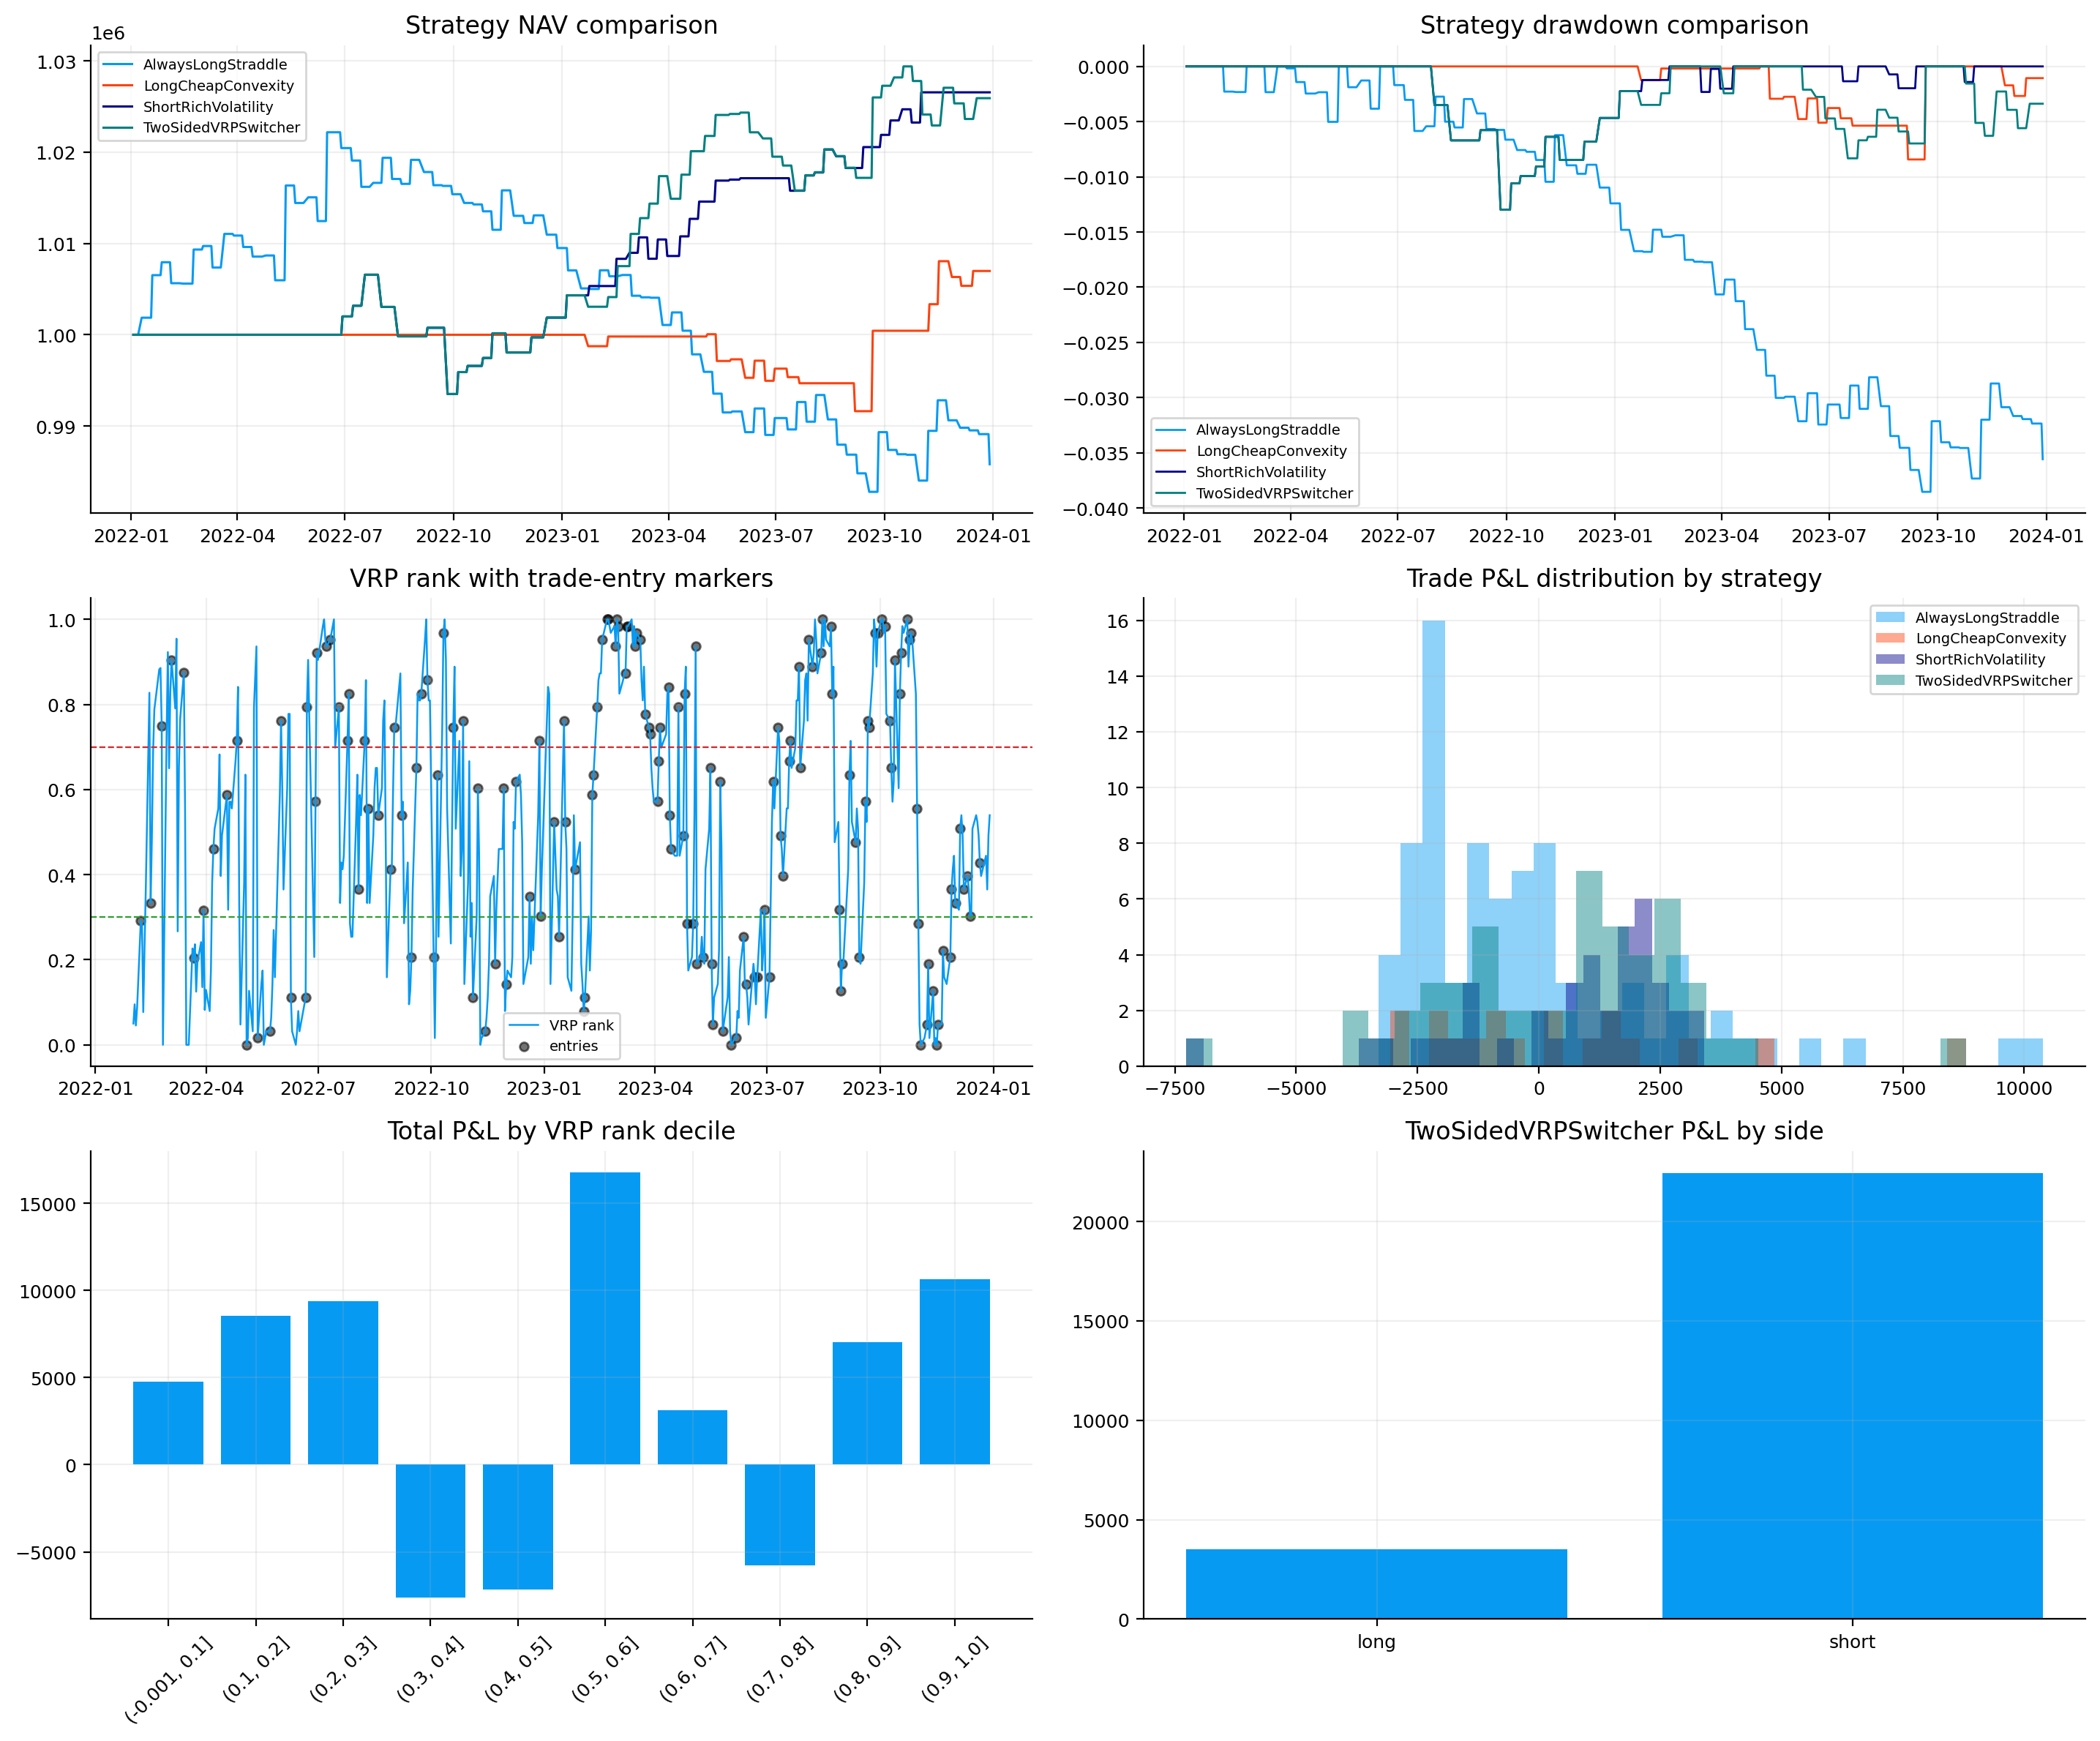

In [19]:
if not all_equity.empty:
    fig, axes = plt.subplots(3, 2, figsize=(14.5, 12.0))
    axes = axes.ravel()
    for name, g in all_equity.groupby("strategy"):
        axes[0].plot(g["date"], g["nav"], lw=1.1, label=name)
        axes[1].plot(g["date"], g["drawdown"], lw=1.0, label=name)
    axes[0].set_title("Strategy NAV comparison")
    axes[1].set_title("Strategy drawdown comparison")
    axes[0].legend(loc="best")
    axes[1].legend(loc="best")

    axes[2].plot(vrp_panel["date"], vrp_panel["vrp_rank"], lw=0.9, label="VRP rank")
    axes[2].axhline(0.30, ls="--", lw=0.8, c="tab:green")
    axes[2].axhline(0.70, ls="--", lw=0.8, c="tab:red")
    if not all_trades.empty:
        marker_dates = all_trades["entry_date"].dropna().unique()
        marker_panel = vrp_panel[vrp_panel["date"].isin(marker_dates)]
        axes[2].scatter(marker_panel["date"], marker_panel["vrp_rank"], s=18, c="black", alpha=0.55, label="entries")
    axes[2].set_title("VRP rank with trade-entry markers")
    axes[2].legend(loc="best")

    if not all_trades.empty:
        for name, g in all_trades.groupby("strategy"):
            axes[3].hist(g["net_pnl"], bins=30, alpha=0.45, label=name)
        axes[3].set_title("Trade P&L distribution by strategy")
        axes[3].legend(loc="best")

        decile_plot = all_trades.dropna(subset=["vrp_decile"]).groupby(["vrp_decile"], observed=True)["net_pnl"].sum()
        axes[4].bar([str(x) for x in decile_plot.index], decile_plot.to_numpy(dtype=float))
        axes[4].tick_params(axis="x", rotation=45)
        axes[4].set_title("Total P&L by VRP rank decile")

        switcher = all_trades[all_trades["strategy"] == "TwoSidedVRPSwitcher"]
        if not switcher.empty:
            side_pnl = switcher.groupby("side")["net_pnl"].sum()
            axes[5].bar(side_pnl.index.astype(str), side_pnl.to_numpy(dtype=float))
            axes[5].set_title("TwoSidedVRPSwitcher P&L by side")
        else:
            axes[5].axis("off")
    else:
        for ax in axes[3:]:
            ax.axis("off")
    plt.tight_layout()
    plt.show()


## Implementation of the project on BTC-Deribit options chain with QuantFinLab

We use an option chain of Bitcoin for the first 9 months of 2023 to show the implementation with our library. We picked it because it's european and doesn't include dividends and can be closer to the implementation on SPX. But BTC requires several adjustments. 

First, crypto trades every calendar day, so the annualization changes from 252 to 365

Second, BTC option quotes may be represented in different units, so we detect and converts option prices into USD equivalent before building IV. 

Third, for this case we use fractional units and a contract multiplier of 1 for the backtest, because the BTC option scale is different from SPX index options.

,step,rows,removed
0,raw wide rows,258234,NaN
1,long-form raw rows,258234,0.000000
2,long-form after schema normalization,258234,0.000000
3,long-form after positive price filter,218710,"39,524.000000"
4,long-form after bid/ask/spread filter,187179,"31,531.000000"
5,long-form after DTE filter,92124,"95,055.000000"
6,long-form after moneyness filter,56054,"36,070.000000"
7,long-form after ATM-pair selection,55252,802.000000
8,long-form final rows,55105,147.000000
9,price unit detected: usd,55105,0.000000


,model,qlike_rank
0,gjr11_normal,1.333333
1,egarch11_normal,2.166667
2,garch11_normal,3.000000
3,garch22_normal,4.166667
4,har_rv,5.000000
5,gjr11_student,5.666667
6,garch11_student,7.000000
7,garch22_student,7.666667


,model,horizon,qlike_var,rmse_var,mae_var,rmse_vol,mae_vol,corr_vol,n_obs
0,gjr11_normal,21,-3.149640,0.008296,0.006278,0.142169,0.107705,-0.199432,136
1,egarch11_normal,21,-3.147296,0.008447,0.006593,0.145456,0.112508,-0.144759,136
2,garch11_normal,21,-3.142783,0.008675,0.006439,0.147643,0.109804,-0.250013,136
3,garch22_normal,21,-3.133525,0.009102,0.006644,0.155017,0.112794,-0.379578,136
4,har_rv,21,-3.128213,0.008690,0.006730,0.147865,0.115867,-0.265453,136
5,gjr11_student,21,-2.994847,0.018170,0.015660,0.260631,0.229204,-0.054798,136
6,garch11_student,21,-2.981493,0.018867,0.015772,0.273932,0.228891,-0.263541,136
7,garch22_student,21,-2.971054,0.019325,0.016245,0.279759,0.234543,-0.282251,136


horizon,1,5,10,21,42,63
selected_model,,,,,,
egarch11_normal,74.000000,40.000000,30.000000,12.000000,21.000000,0.000000
garch11_normal,2.000000,0.000000,3.000000,15.000000,9.000000,0.000000
garch11_student,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
garch22_normal,0.000000,33.000000,5.000000,18.000000,26.000000,1.000000
gjr11_normal,45.000000,22.000000,30.000000,26.000000,50.000000,0.000000
har_rv,15.000000,41.000000,68.000000,64.000000,30.000000,135.000000


,scenario,strategy,cheap_rank,rich_rank,holding_days,total_net_pnl,return_on_initial_nav,max_drawdown,n_trades,hit_rate,avg_trade_pnl
0,loose,AlwaysLongStraddle,0.400000,0.700000,3,-8.132240,-0.008132,-0.009476,27,0.185185,-0.301194
1,loose,LongCheapConvexity,0.400000,0.700000,3,-7.423531,-0.007424,-0.007644,20,0.200000,-0.371177
2,loose,ShortRichVolatility,0.400000,0.700000,3,1.663766,0.001664,-0.000100,4,0.750000,0.415942
3,loose,TwoSidedVRPSwitcher,0.400000,0.700000,3,-1.601426,-0.001601,-0.005752,22,0.318182,-0.072792
4,base,AlwaysLongStraddle,0.350000,0.800000,3,-8.132240,-0.008132,-0.009476,27,0.185185,-0.301194
5,base,LongCheapConvexity,0.350000,0.800000,3,-5.671705,-0.005672,-0.006437,18,0.222222,-0.315095
6,base,ShortRichVolatility,0.350000,0.800000,3,0.052899,0.000053,-0.000100,2,0.500000,0.026449
7,base,TwoSidedVRPSwitcher,0.350000,0.800000,3,-5.519768,-0.005520,-0.006437,19,0.263158,-0.290514
8,strict,AlwaysLongStraddle,0.300000,0.900000,3,-8.132240,-0.008132,-0.009476,27,0.185185,-0.301194
9,strict,LongCheapConvexity,0.300000,0.900000,3,-1.885717,-0.001886,-0.006266,18,0.222222,-0.104762


,strategy,side,n,total_pnl,avg_pnl,avg_units
0,AlwaysLongStraddle,long,27,-8.132240,-0.301194,0.000603
1,LongCheapConvexity,long,11,-0.938869,-0.085352,0.000695
2,ShortRichVolatility,short,4,1.663766,0.415942,0.001148
3,TwoSidedVRPSwitcher,long,11,-0.936839,-0.085167,0.000696
4,TwoSidedVRPSwitcher,short,3,1.760147,0.586716,0.001050


,strategy,side,entry_date,exit_date,expiry,strike,units,net_pnl,vrp_rank,vrp_z,selected_model
0,AlwaysLongStraddle,long,2024-03-30,2024-04-02,2024-04-26,"71,000.000000",0.000450,-0.211639,NaN,NaN,har_rv
1,AlwaysLongStraddle,long,2024-04-03,2024-04-06,2024-04-26,"67,000.000000",0.000520,-1.511337,NaN,NaN,har_rv
2,AlwaysLongStraddle,long,2024-04-12,2024-04-15,2024-05-03,"72,000.000000",0.000553,0.373478,NaN,NaN,har_rv
3,AlwaysLongStraddle,long,2024-04-18,2024-04-21,2024-05-31,"63,000.000000",0.000418,-0.003815,0.166667,-1.023106,garch11_normal
4,AlwaysLongStraddle,long,2024-04-22,2024-04-25,2024-05-31,"66,000.000000",0.000412,-1.014286,0.318182,-0.602765,garch11_normal
5,AlwaysLongStraddle,long,2024-04-26,2024-04-29,2024-05-31,"65,000.000000",0.000542,-0.814834,0.000000,-2.301752,garch22_normal
6,AlwaysLongStraddle,long,2024-04-30,2024-05-03,2024-05-31,"64,000.000000",0.000644,0.015991,0.000000,-2.173978,garch22_normal
7,AlwaysLongStraddle,long,2024-05-04,2024-05-07,2024-05-31,"63,000.000000",0.000663,-0.493418,0.058824,-1.579771,garch11_normal
8,AlwaysLongStraddle,long,2024-05-08,2024-05-11,2024-05-31,"63,000.000000",0.000773,-0.389667,0.026316,-1.532690,garch11_normal
9,AlwaysLongStraddle,long,2024-05-16,2024-05-19,2024-06-28,"65,000.000000",0.000482,-0.089275,0.377778,-0.795503,garch22_normal


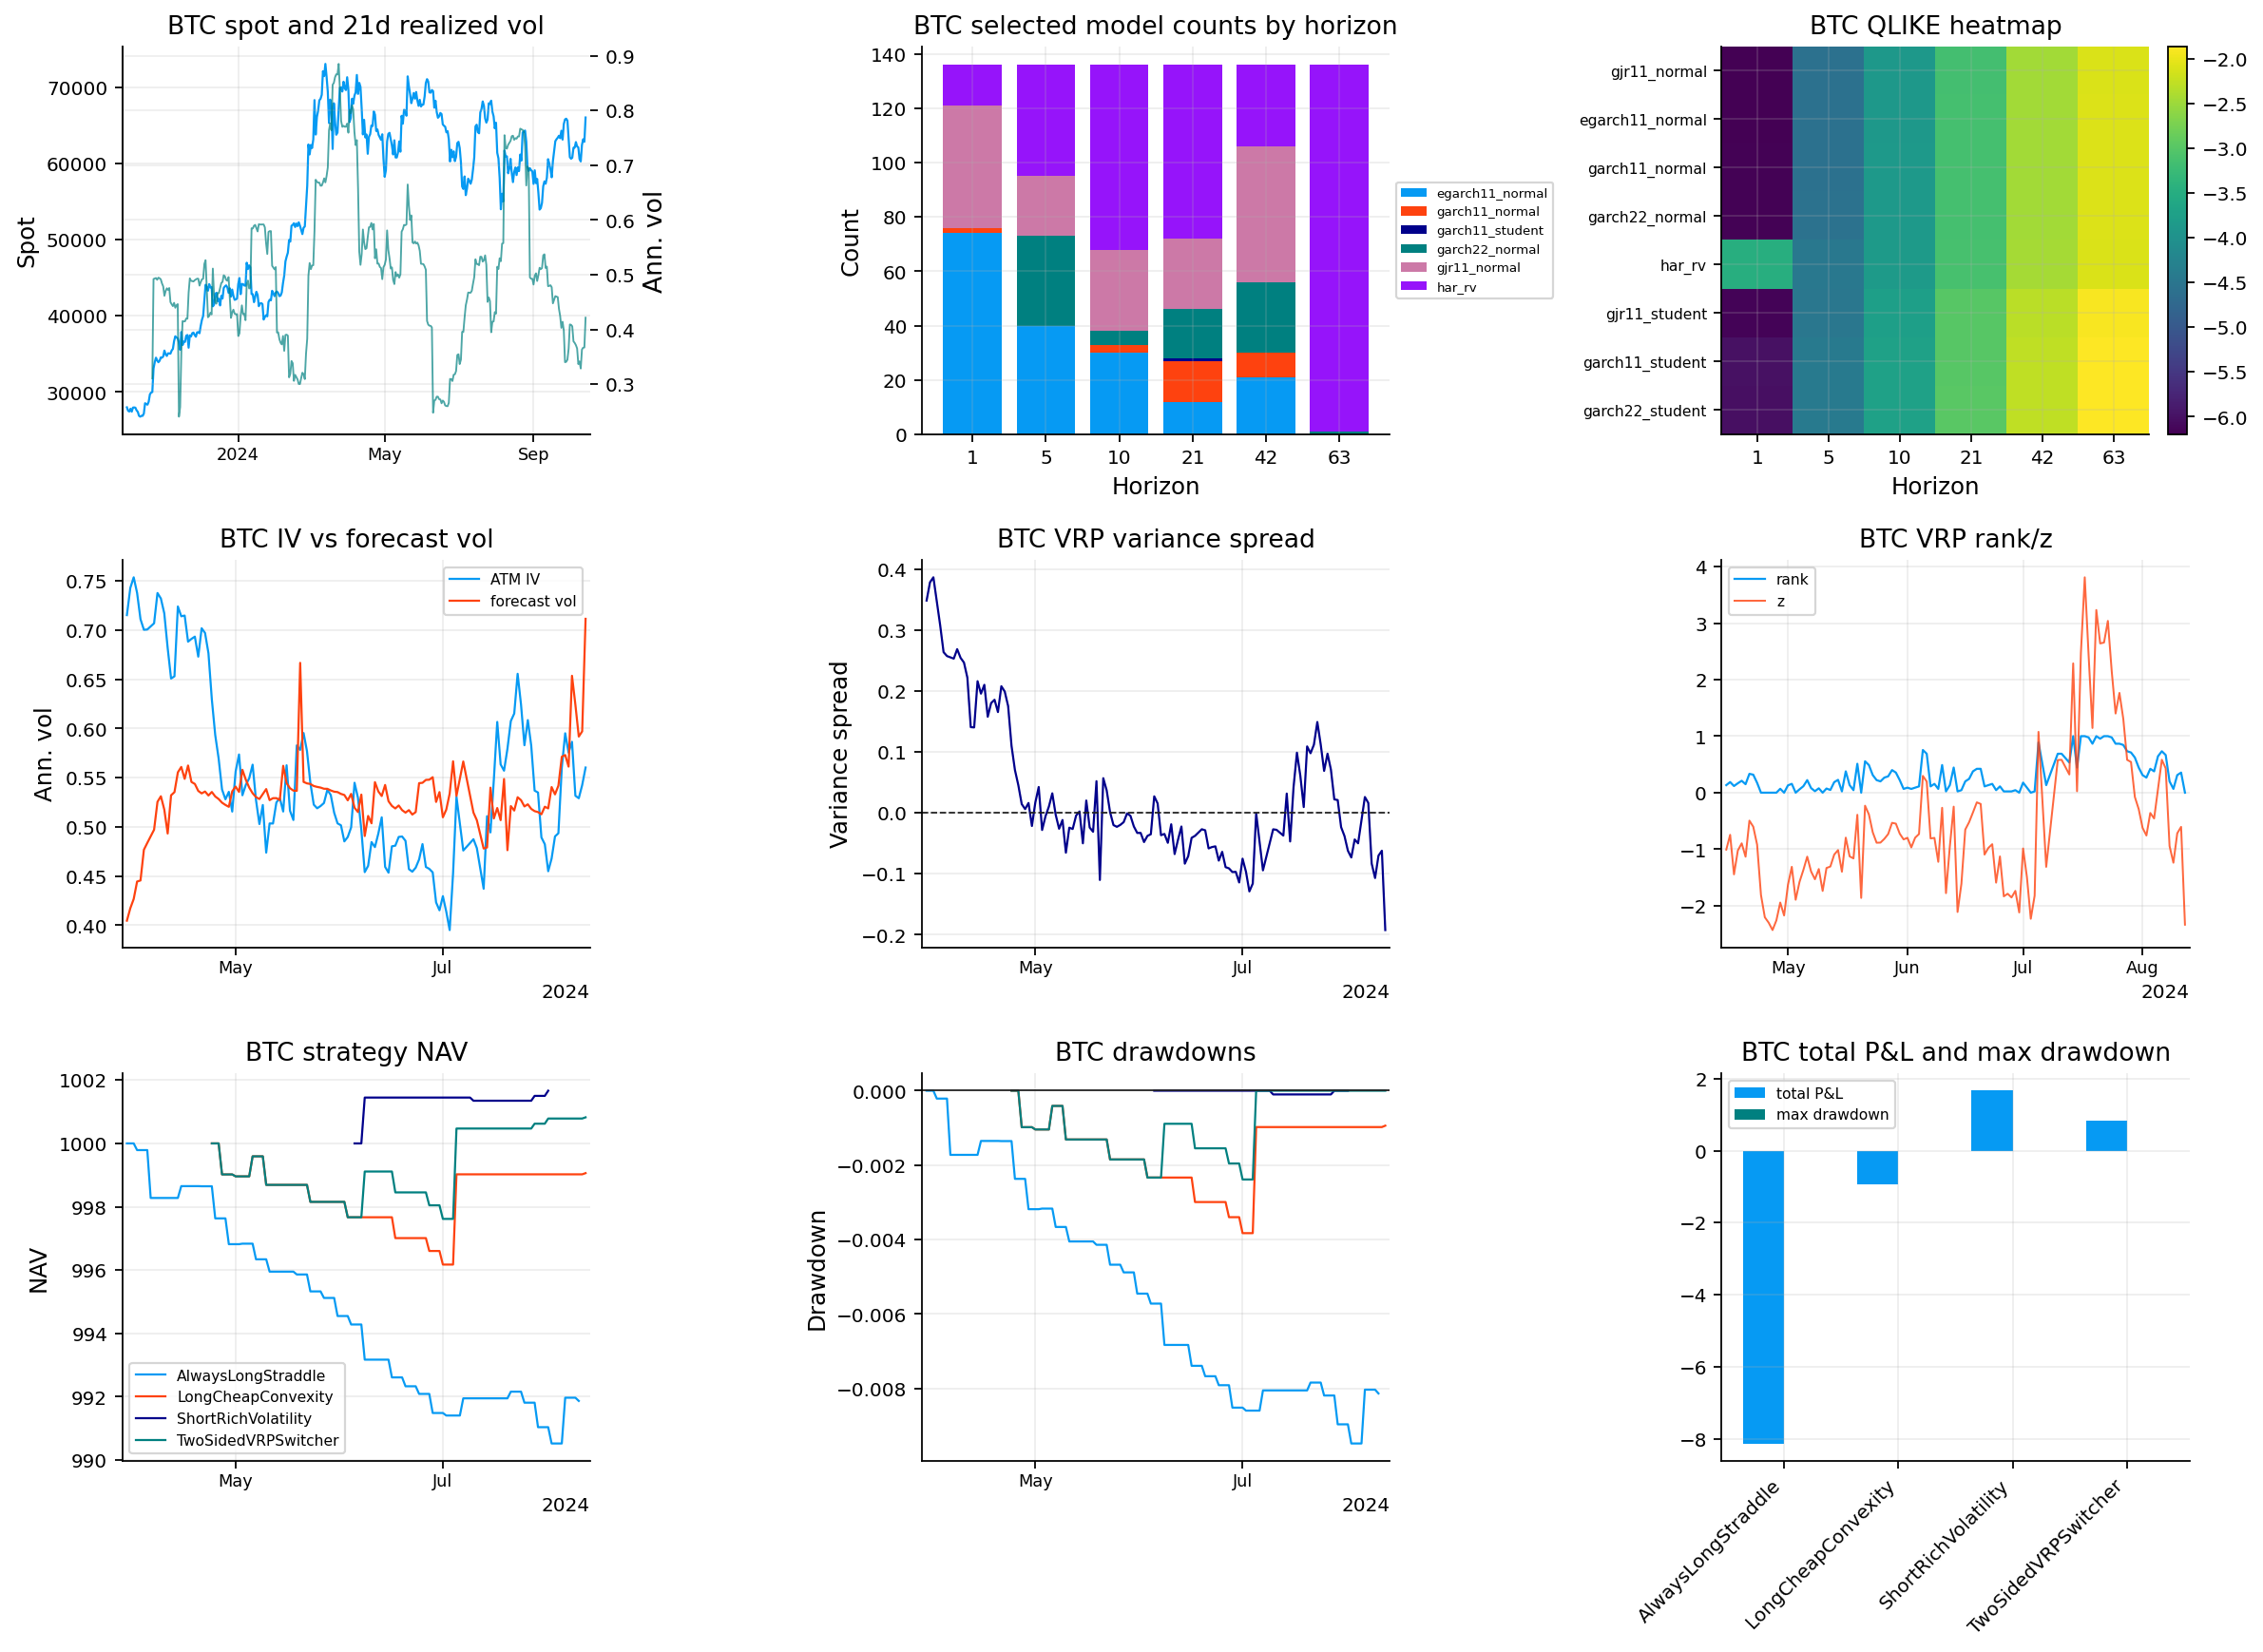

In [2]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from quantfinlab.dataio import load_ohlcv, load_option_chain
from quantfinlab.options.quote_cleaning import (
    convert_quotes_to_usd_equivalent,
    detect_option_price_unit)
from quantfinlab.options.diagnostics import build_atm_iv_panel_from_option_quotes as build_library_atm_iv_panel
from quantfinlab.volatility.forecasting import rolling_arch_forecasts_weekly, score_forecasts_by_model, select_forecast_by_rolling_loss
from quantfinlab.volatility.har import rolling_har_forecasts
from quantfinlab.volatility.vrp import compute_vrp_panel
from quantfinlab.backtest.overlays import backtest_straddle_overlay, summarize_overlay_trades
import quantfinlab.plotting.volatility as vol_plots

warnings.filterwarnings("ignore")

horizons = (1, 5, 10, 21, 42, 63)
annualization = 365.25
eps = 1e-12

btc_spot_df = load_ohlcv(
    r"..\data\btc_usd_yfinance_2023_10_01_2024_10_15.csv",
    source="yfinance_csv",
    fields=("close",))
btc_spot = btc_spot_df["close"].rename("btc_spot")
btc_spot = btc_spot[btc_spot > 0]

btc_returns = np.log(btc_spot / btc_spot.shift(1)).replace([np.inf, -np.inf], np.nan).dropna()
btc_signal_start = btc_returns.index.min() + pd.Timedelta(days=120)

btc_options_norm = load_option_chain(
    r"..\data\btc_deribit_optiondx_2024_01_09.parquet",
    source="btc_deribit",
    annualization_days=365.25)
btc_unit_before = detect_option_price_unit(btc_options_norm)
btc_options_usd = convert_quotes_to_usd_equivalent(btc_options_norm, unit="auto")
btc_unit_after = detect_option_price_unit(btc_options_usd)


btc_iv_all = build_library_atm_iv_panel(btc_options_usd, rates=None, constant_rate=0.0,
                                        min_dte=7, max_dte=90, moneyness_range=(0.75, 1.25),
                                        max_relative_spread=0.35, closest_atm_pairs=30,
                                        min_pairs_per_expiry=4, underlying_default="BTC")
if btc_iv_all.empty:
    raise RuntimeError("BTC ATM IV panel is empty after cleaning.")
btc_iv_daily = (
    btc_iv_all[(btc_iv_all["dte_calendar"] >= 14) & (btc_iv_all["dte_calendar"] <= 45)]
    .assign(dte_score=lambda x: (x["dte_calendar"] - 30.0).abs())
    .sort_values(["date", "dte_score", "quote_quality_score"])
    .groupby("date", as_index=False)
    .head(1)
    .drop(columns=["dte_score"], errors="ignore")
    .reset_index(drop=True))
btc_iv_cleaning_report = btc_iv_all.attrs.get("cleaning_report", pd.DataFrame())
display(btc_iv_cleaning_report)

raw_price_cols = [c for c in ["date", "expiry", "spot", "strike", "call_mid_raw", "put_mid_raw", "call_mid", "put_mid", "atm_iv_mid"] if c in btc_iv_daily.columns]

btc_train_window = min(180, max(80, len(btc_returns) // 2))
btc_garch = rolling_arch_forecasts_weekly(
    btc_returns, horizons=horizons, train_window=btc_train_window,
    signal_step=1, forecast_start=btc_signal_start,
    annualization=annualization, maxiter=350)

btc_har = rolling_har_forecasts(btc_returns, horizons=horizons,
                                train_window=btc_train_window, refit_every=1,
                                annualization=annualization, forecast_start=btc_signal_start)


btc_fc = pd.concat([btc_garch, btc_har], ignore_index=True).sort_values(["date", "model", "horizon"])
def sanitize_btc_forecast_panel(panel, max_annualized_vol=5.0, min_var=eps):
    out = panel.copy().replace([np.inf, -np.inf], np.nan)
    numeric_cols = [
        "horizon", "forecast_var_sum", "forecast_var_ann", "forecast_vol_ann",
        "realized_var_sum", "realized_var_ann", "realized_vol_ann"]
    for col in numeric_cols:
        if col in out.columns:
            out[col] = pd.to_numeric(out[col], errors="coerce")
    out = out.dropna(subset=["date", "model", "horizon", "forecast_var_sum", "realized_var_sum"]).copy()
    out["horizon"] = out["horizon"].astype(int)
    out["forecast_var_sum_raw"] = out["forecast_var_sum"]
    out["forecast_var_ann_raw"] = out.get("forecast_var_ann", annualization / out["horizon"] * out["forecast_var_sum"])
    max_var_ann = float(max_annualized_vol) ** 2
    cap_sum = max_var_ann * out["horizon"] / float(annualization)
    out["forecast_cap_flag"] = (out["forecast_var_sum"] > cap_sum) | (out["forecast_var_sum"] <= 0)
    out["forecast_var_sum"] = out["forecast_var_sum"].clip(lower=float(min_var), upper=cap_sum)
    out["forecast_var_ann"] = annualization / out["horizon"] * out["forecast_var_sum"]
    out["forecast_vol_ann"] = np.sqrt(out["forecast_var_ann"].clip(lower=0.0))
    out["realized_var_ann"] = annualization / out["horizon"] * out["realized_var_sum"]
    out["realized_vol_ann"] = np.sqrt(out["realized_var_ann"].clip(lower=0.0))
    return out.sort_values(["date", "model", "horizon"]).reset_index(drop=True)
btc_fc = sanitize_btc_forecast_panel(btc_fc, max_annualized_vol=5.0)
btc_forecast_cap_report = (
    btc_fc.groupby("model")["forecast_cap_flag"]
    .agg(n_forecasts="size", n_capped="sum", cap_rate="mean")
    .reset_index()
    .sort_values("cap_rate", ascending=False))

btc_unstable_cap_threshold = 0.05
btc_unstable_models = btc_forecast_cap_report.loc[btc_forecast_cap_report["cap_rate"].gt(btc_unstable_cap_threshold), "model"].astype(str).tolist()

btc_fc_model_universe = btc_fc[~btc_fc["model"].isin(btc_unstable_models)].copy()
btc_forecast_scores = score_forecasts_by_model(btc_fc_model_universe)
btc_score_pivot = btc_forecast_scores.pivot(index="model", columns="horizon", values="qlike_var")
btc_model_ranks = (
    btc_forecast_scores.assign(qlike_rank=lambda x: x.groupby("horizon")["qlike_var"].rank(method="average"))
    .groupby("model", as_index=False)["qlike_rank"]
    .mean()
    .sort_values("qlike_rank")
    .reset_index(drop=True))

display(btc_model_ranks)
display(btc_forecast_scores[btc_forecast_scores["horizon"].eq(21)].sort_values(["qlike_var", "rmse_vol"]).reset_index(drop=True))
btc_selected = select_forecast_by_rolling_loss(
    btc_fc_model_universe, horizons=horizons, lookback=63,
    min_obs=15, mode="best")

btc_selected_model_counts = btc_selected.groupby(["horizon", "selected_model"]).size().rename("n").reset_index()
display(btc_selected_model_counts.pivot_table(index="selected_model", columns="horizon", values="n", fill_value=0))
btc_vrp_rank_window = 45
btc_vrp_z_window = 45
btc_min_periods = 15
btc_base_cheap_rank = 0.10
btc_base_rich_rank = 0.50
btc_base_holding_days = 3
try:
    btc_vrp = compute_vrp_panel(
        btc_iv_daily, btc_selected, dte_col="dte_calendar",
        iv_col="atm_iv_mid", annualization=annualization,
        z_window=btc_vrp_z_window, rank_window=btc_vrp_rank_window,
        min_periods=btc_min_periods)

except TypeError as exc:
    if "rank_window" not in str(exc):
        raise
    btc_vrp = compute_vrp_panel(btc_iv_daily, btc_selected,
                                dte_col="dte_calendar", iv_col="atm_iv_mid",
                                annualization=annualization,
                                z_window=btc_vrp_z_window, min_periods=btc_min_periods)

btc_vrp = btc_vrp.sort_values("date").reset_index(drop=True)
vals = btc_vrp["vrp_var"].to_numpy(dtype=float)
ranks = np.full(len(vals), np.nan)
for i in range(len(vals)):
    hist = vals[max(0, i - btc_vrp_rank_window):i]
    hist = hist[np.isfinite(hist)]
    if len(hist) >= btc_min_periods and np.isfinite(vals[i]):
        ranks[i] = np.mean(hist <= vals[i])
btc_vrp["vrp_rank"] = ranks
btc_feature_frame = pd.DataFrame(index=btc_spot.index)
btc_feature_frame["btc_spot"] = btc_spot
btc_feature_frame["ret_1d"] = btc_returns.reindex(btc_feature_frame.index)
btc_feature_frame["ret_5d"] = np.log(btc_feature_frame["btc_spot"] / btc_feature_frame["btc_spot"].shift(5))
btc_feature_frame["trailing_rv_21"] = btc_returns.rolling(21).std() * np.sqrt(annualization)
rv_vals = btc_feature_frame["trailing_rv_21"].to_numpy(dtype=float)
rv_rank = np.full(len(rv_vals), np.nan)
for i, value in enumerate(rv_vals):
    hist = rv_vals[max(0, i - btc_vrp_rank_window):i]
    hist = hist[np.isfinite(hist)]
    if np.isfinite(value) and len(hist) >= btc_min_periods:
        rv_rank[i] = np.mean(hist <= value)
btc_feature_frame["trailing_rv_rank"] = rv_rank
btc_vrp = btc_vrp.merge(
    btc_feature_frame[["ret_1d", "ret_5d", "trailing_rv_21", "trailing_rv_rank"]].reset_index().rename(columns={"index": "date"}),
    on="date", how="left")

btc_vrp["short_calm_filter"] = (
    btc_vrp["ret_1d"].abs().le(0.05)
    & btc_vrp["ret_5d"].abs().le(0.12)
    & (btc_vrp["trailing_rv_rank"].isna() | btc_vrp["trailing_rv_rank"].le(0.80)))


def lib_rule(strategy_name, cheap_rank=btc_base_cheap_rank, rich_rank=btc_base_rich_rank):
    def _rule(row):
        rank = row.get("vrp_rank", np.nan)
        cheap = bool(pd.notna(rank) and rank <= cheap_rank)
        rich = bool(pd.notna(rank) and rank >= rich_rank)
        calm_short = bool(row.get("short_calm_filter", False))
        if strategy_name == "AlwaysLongStraddle":
            return {"side": "long"}
        if strategy_name == "LongCheapConvexity":
            return {"side": "long" if cheap else "cash", "skip_reason": "rank_not_cheap"}
        if strategy_name == "ShortRichVolatility":
            if rich and calm_short:
                return {"side": "short"}
            if rich and not calm_short:
                return {"side": "cash", "skip_reason": "short_calm_filter"}
            return {"side": "cash", "skip_reason": "rank_not_rich"}
        if strategy_name == "TwoSidedVRPSwitcher":
            if cheap and not rich:
                return {"side": "long"}
            if rich and not cheap:
                return {"side": "short"} if calm_short else {"side": "cash", "skip_reason": "short_calm_filter"}
            if cheap and rich:
                if rank <= 0.50:
                    return {"side": "long"}
                return {"side": "short"} if calm_short else {"side": "cash", "skip_reason": "short_calm_filter"}
        return {"side": "cash", "skip_reason": "neutral_rank"}
    return _rule

btc_strategy_names = ["AlwaysLongStraddle", "LongCheapConvexity", "ShortRichVolatility", "TwoSidedVRPSwitcher"]

def run_btc_overlay_suite(scenario, cheap_rank, rich_rank, holding_days):
    suite = {
        name: backtest_straddle_overlay(
            btc_vrp, btc_options_usd, btc_spot, strategy_name=name,
            signal_rule=lib_rule(name, cheap_rank=cheap_rank, rich_rank=rich_rank),
            initial_nav=1_000, contract_multiplier=1.0,
            holding_days=int(holding_days), allow_overlap=False,
            fractional_units=True, long_premium_budget_frac=0.005,
            short_margin_budget_frac=0.02, max_short_notional_frac=1.0)
        for name in btc_strategy_names}

    summary = summarize_overlay_trades(suite, initial_nav=1_000)
    summary["scenario"] = scenario
    summary["cheap_rank"] = cheap_rank
    summary["rich_rank"] = rich_rank
    summary["holding_days"] = int(holding_days)
    return suite, summary

btc_backtests, btc_summary = run_btc_overlay_suite(
    "base", cheap_rank=btc_base_cheap_rank,
    rich_rank=btc_base_rich_rank, holding_days=btc_base_holding_days)

btc_sensitivity_specs = [
    {"scenario": "loose", "cheap_rank": 0.40, "rich_rank": 0.70, "holding_days": 3},
    {"scenario": "base", "cheap_rank": 0.35, "rich_rank": 0.80, "holding_days": 3},
    {"scenario": "strict", "cheap_rank": 0.30, "rich_rank": 0.90, "holding_days": 3}]

btc_sensitivity_rows = []
for spec in btc_sensitivity_specs:
    _, sens_summary = run_btc_overlay_suite(**spec)
    btc_sensitivity_rows.append(sens_summary)
btc_sensitivity_table = pd.concat(btc_sensitivity_rows, ignore_index=True)
display(btc_sensitivity_table[["scenario", "strategy", "cheap_rank", "rich_rank", "holding_days", "total_net_pnl", "return_on_initial_nav", "max_drawdown", "n_trades", "hit_rate", "avg_trade_pnl"]])

btc_trades = pd.concat([x[0] for x in btc_backtests.values()], ignore_index=True)
btc_equity = pd.concat([x[1] for x in btc_backtests.values()], ignore_index=True)
if not btc_trades.empty:
    display(btc_trades.groupby(["strategy", "side"]).agg(n=("net_pnl", "size"), total_pnl=("net_pnl", "sum"), avg_pnl=("net_pnl", "mean"), avg_units=("units", "mean")).reset_index())
    display(btc_trades[["strategy", "side", "entry_date", "exit_date", "expiry", "strike", "units", "net_pnl", "vrp_rank", "vrp_z", "selected_model"]].head(20))

fig, axes = plt.subplots(3, 3, figsize=(15.0, 11.0))
axes = axes.ravel()
vol_plots.plot_spot_and_realized_vol(axes[0], btc_spot, btc_returns, annualization=annualization, title="BTC spot and 21d realized vol")
vol_plots.plot_selected_model_counts_by_horizon(axes[1], btc_selected_model_counts, title="BTC selected model counts by horizon")
vol_plots.plot_qlike_heatmap(
    axes[2],
    btc_score_pivot,
    model_order=btc_model_ranks["model"].tolist() if not btc_model_ranks.empty else None,
    title="BTC QLIKE heatmap")
vol_plots.plot_iv_forecast_vol(axes[3], btc_vrp, title="BTC IV vs forecast vol")
vol_plots.plot_vrp_variance_spread(axes[4], btc_vrp, title="BTC VRP variance spread")
vol_plots.plot_vrp_rank_zscore(axes[5], btc_vrp, title="BTC VRP rank/z")
vol_plots.plot_overlay_nav(axes[6], btc_equity, title="BTC strategy NAV")
vol_plots.plot_overlay_drawdowns(axes[7], btc_equity, title="BTC drawdowns")
vol_plots.plot_summary_pnl_drawdown_bars(axes[8], btc_summary, title="BTC total P&L and max drawdown")
fig.tight_layout(pad=1.2, w_pad=1.2, h_pad=1.4)
plt.show()

The BTC ATM-IV cleaning shows we started with about **258,234 raw rows** and ended up with **1,228 final ATM rows**. The largest filters are the DTE and moneyness filters, which is expected for an option chain dataset with many strikes and expiries.

The BTC forecast ranking is different from SPX. based on QLIKE the overal first is **GJR normal** first, followed by **EGARCH normal** and **GARCH normal**. At the 21-day horizon, GJR normal and EGARCH normal are again the best by QLIKE. The Student-$t$ models perform worse in this BTC experiment. Parameter instability, small sample length, crypto regime shifts, and noisy option implied inputs can all change the ranking.

Based on The selected model count table, EGARCH normal is heavily used at one-day horizons, while HAR-RV dominates the 63-day horizon. Short horizon forecasts often need fast reaction to recent shocks, while longer horizons benefit from smoother realized volatility memory.

The BTC VRP and strategy tables are less trustable than the SPX results because the sample is shorter and the option microstructure is different.

- Always Long Straddle loses across the scenarios, with about **-0.26%** return on initial NAV in the displayed loose/base/strict rows.
- Long Cheap Convexity is also negative in the scenarios.
- Short Rich Volatility is slightly positive in loose/base scenarios but often has very few trades.
- Two Sided VRP Switcher is negative in the scenario set, although the side breakdown shows that short trades can still be profitable.

Thanks for watching.